In [2]:
# ============================================================
# EXPERIMENT 6 — FLAIR-ONLY 3D U-NET
# STANDALONE NOTEBOOK
# ============================================================

import os
import time
import random
import numpy as np
import pandas as pd
import torch

from tqdm import tqdm

from sklearn.model_selection import train_test_split

from monai.data import Dataset, DataLoader

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    RandFlipd,
    RandRotated,
    RandAffined,
    RandGaussianNoised,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandCropByPosNegLabeld,
    ToTensord
)

from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ============================================================
# DATASET PATH
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE\MSLesSegDataset"
)


# ============================================================
# PREPROCESSED DATA
# ============================================================

Z_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed"
)

Z_TRAIN_ROOT = os.path.join(
    Z_ROOT,
    "train"
)

Z_TEST_ROOT = os.path.join(
    Z_ROOT,
    "test"
)


# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================

EXP6_DIR = os.path.join(
    DATASET_ROOT,
    "Experiment_6_FLAIR_Only"
)

os.makedirs(
    EXP6_DIR,
    exist_ok=True
)


ROI_SIZE = (
    144,
    144,
    144
)

BATCH_SIZE = 1

NUM_EPOCHS = 100

LEARNING_RATE = 1e-4

NUM_WORKERS = 0


# ============================================================
# MODEL FILES
# ============================================================

BEST_MODEL_PATH = os.path.join(
    EXP6_DIR,
    "best_model_exp6.pth"
)

CHECKPOINT_PATH = os.path.join(
    EXP6_DIR,
    "checkpoint_exp6.pth"
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — FLAIR-ONLY 3D U-NET")
print("=" * 70)

print("Dataset root :", DATASET_ROOT)
print("Train root   :", Z_TRAIN_ROOT)
print("Test root    :", Z_TEST_ROOT)

print()
print("Input         : FLAIR only")
print("Channels      : 1")
print("Preprocessing : N4 + non-zero Z-score")
print("ROI           :", ROI_SIZE)
print("Batch size    :", BATCH_SIZE)
print("Epochs        :", NUM_EPOCHS)
print("LR            :", LEARNING_RATE)
print("Device        :", device)
print("AMP           : True")

print("=" * 70)

EXPERIMENT 6 — FLAIR-ONLY 3D U-NET
Dataset root : C:\Defense_project\PROJECT_FILE\MSLesSegDataset
Train root   : C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\train
Test root    : C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test

Input         : FLAIR only
Channels      : 1
Preprocessing : N4 + non-zero Z-score
ROI           : (144, 144, 144)
Batch size    : 1
Epochs        : 100
LR            : 0.0001
Device        : cuda
AMP           : True


In [3]:
# ============================================================
# EXPERIMENT 6 — BUILD ALL TRAINING FILES
# FLAIR ONLY
# ============================================================

train_files_all_exp6 = []


# ------------------------------------------------------------
# Find patient folders
# ------------------------------------------------------------

train_patients = sorted(
    [
        p
        for p in os.listdir(Z_TRAIN_ROOT)
        if os.path.isdir(
            os.path.join(Z_TRAIN_ROOT, p)
        )
    ],
    key=lambda x: int(
        ''.join(
            filter(str.isdigit, x)
        ) or 0
    )
)


# ------------------------------------------------------------
# Build file list
# ------------------------------------------------------------

for patient in train_patients:

    patient_dir = os.path.join(
        Z_TRAIN_ROOT,
        patient
    )

    for timepoint in sorted(
        os.listdir(patient_dir)
    ):

        timepoint_dir = os.path.join(
            patient_dir,
            timepoint
        )

        if not os.path.isdir(
            timepoint_dir
        ):
            continue

        prefix = f"{patient}_{timepoint}"

        flair = os.path.join(
            timepoint_dir,
            f"{prefix}_FLAIR_N4_Z.nii.gz"
        )

        mask = os.path.join(
            timepoint_dir,
            f"{prefix}_MASK.nii.gz"
        )

        if (
            os.path.exists(flair)
            and
            os.path.exists(mask)
        ):

            train_files_all_exp6.append({

                "image": [
                    flair
                ],

                "label": mask,

                "patient": patient,

                "timepoint": timepoint
            })


# ============================================================
# VERIFY
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — TRAIN FILE LIST")
print("=" * 70)

print(
    "Training samples:",
    len(train_files_all_exp6)
)

print(
    "Training patients:",
    len(
        set(
            x["patient"]
            for x in train_files_all_exp6
        )
    )
)

print("\nExample:")
print(train_files_all_exp6[0])

print("\n✓ Training file list created.")

EXPERIMENT 6 — TRAIN FILE LIST
Training samples: 93
Training patients: 53

Example:
{'image': ['C:\\Defense_project\\PROJECT_FILE\\MSLesSegDataset\\N4_Zscore_preprocessed\\train\\P1\\T1\\P1_T1_FLAIR_N4_Z.nii.gz'], 'label': 'C:\\Defense_project\\PROJECT_FILE\\MSLesSegDataset\\N4_Zscore_preprocessed\\train\\P1\\T1\\P1_T1_MASK.nii.gz', 'patient': 'P1', 'timepoint': 'T1'}

✓ Training file list created.


In [4]:
# ============================================================
# EXPERIMENT 6 — PATIENT-WISE TRAIN / VALIDATION SPLIT
# SAME SPLIT AS EXPERIMENT 5
# ============================================================

all_train_patients_exp6 = sorted(
    set(
        item["patient"]
        for item in train_files_all_exp6
    ),
    key=lambda x: int(
        ''.join(
            filter(str.isdigit, x)
        ) or 0
    )
)


# ------------------------------------------------------------
# 80 / 20 patient-wise split
# ------------------------------------------------------------

train_patients_exp6, val_patients_exp6 = train_test_split(
    all_train_patients_exp6,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------------------------
# Build file lists
# ------------------------------------------------------------

train_files_exp6 = [
    item
    for item in train_files_all_exp6
    if item["patient"] in train_patients_exp6
]

val_files_exp6 = [
    item
    for item in train_files_all_exp6
    if item["patient"] in val_patients_exp6
]


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — PATIENT-WISE SPLIT")
print("=" * 70)

print(
    "Total patients :",
    len(all_train_patients_exp6)
)

print(
    "Train patients :",
    len(train_patients_exp6)
)

print(
    "Val patients   :",
    len(val_patients_exp6)
)

print()

print(
    "Train samples  :",
    len(train_files_exp6)
)

print(
    "Val samples    :",
    len(val_files_exp6)
)

print("\nTrain patients:")
print(train_patients_exp6)

print("\nValidation patients:")
print(val_patients_exp6)

EXPERIMENT 6 — PATIENT-WISE SPLIT
Total patients : 53
Train patients : 42
Val patients   : 11

Train samples  : 70
Val samples    : 23

Train patients:
['P9', 'P27', 'P7', 'P35', 'P5', 'P38', 'P25', 'P45', 'P34', 'P50', 'P16', 'P10', 'P17', 'P31', 'P37', 'P26', 'P12', 'P1', 'P47', 'P28', 'P32', 'P40', 'P30', 'P46', 'P2', 'P22', 'P3', 'P41', 'P36', 'P24', 'P49', 'P11', 'P23', 'P19', 'P53', 'P21', 'P8', 'P43', 'P15', 'P29', 'P52', 'P39']

Validation patients:
['P20', 'P42', 'P48', 'P13', 'P44', 'P6', 'P18', 'P51', 'P4', 'P33', 'P14']


In [5]:
# ============================================================
# EXPERIMENT 6 — TEST FILE LIST
# FLAIR ONLY
# ============================================================

test_files_exp6 = []


# ------------------------------------------------------------
# Find test patients
# ------------------------------------------------------------

test_patients_exp6 = sorted(
    [
        p
        for p in os.listdir(Z_TEST_ROOT)
        if os.path.isdir(
            os.path.join(
                Z_TEST_ROOT,
                p
            )
        )
    ],
    key=lambda x: int(
        ''.join(
            filter(str.isdigit, x)
        ) or 0
    )
)


# ------------------------------------------------------------
# Build test file list
# ------------------------------------------------------------

for patient in test_patients_exp6:

    patient_dir = os.path.join(
        Z_TEST_ROOT,
        patient
    )

    prefix = patient

    flair = os.path.join(
        patient_dir,
        f"{prefix}_FLAIR_N4_Z.nii.gz"
    )

    mask = os.path.join(
        patient_dir,
        f"{prefix}_MASK.nii.gz"
    )

    if (
        os.path.exists(flair)
        and
        os.path.exists(mask)
    ):

        test_files_exp6.append({

            "image": [
                flair
            ],

            "label": mask,

            "patient": patient
        })


# ============================================================
# VERIFY
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — TEST FILE LIST")
print("=" * 70)

print(
    "Test samples:",
    len(test_files_exp6)
)

print(
    "Test patients:",
    test_patients_exp6
)

print("\nExample:")
print(test_files_exp6[0])

print("\n✓ Test file list created.")

EXPERIMENT 6 — TEST FILE LIST
Test samples: 22
Test patients: ['P54', 'P55', 'P56', 'P57', 'P58', 'P59', 'P60', 'P61', 'P62', 'P63', 'P64', 'P65', 'P66', 'P67', 'P68', 'P69', 'P70', 'P71', 'P72', 'P73', 'P74', 'P75']

Example:
{'image': ['C:\\Defense_project\\PROJECT_FILE\\MSLesSegDataset\\N4_Zscore_preprocessed\\test\\P54\\P54_FLAIR_N4_Z.nii.gz'], 'label': 'C:\\Defense_project\\PROJECT_FILE\\MSLesSegDataset\\N4_Zscore_preprocessed\\test\\P54\\P54_MASK.nii.gz', 'patient': 'P54'}

✓ Test file list created.


In [6]:
# ============================================================
# EXPERIMENT 6 — TRAINING TRANSFORMS
# ============================================================

train_transforms_exp6 = Compose([

    LoadImaged(
        keys=[
            "image",
            "label"
        ]
    ),

    EnsureChannelFirstd(
        keys=[
            "image",
            "label"
        ]
    ),

    # --------------------------------------------------------
    # IMPORTANT:
    # No NormalizeIntensityd
    #
    # N4 + Z-score already completed offline
    # --------------------------------------------------------

    # ========================================================
    # RANDOM FLIP
    # ========================================================

    RandFlipd(
        keys=[
            "image",
            "label"
        ],
        spatial_axis=0,
        prob=0.5
    ),

    RandFlipd(
        keys=[
            "image",
            "label"
        ],
        spatial_axis=1,
        prob=0.5
    ),

    RandFlipd(
        keys=[
            "image",
            "label"
        ],
        spatial_axis=2,
        prob=0.5
    ),

    # ========================================================
    # RANDOM ROTATION
    # ========================================================

    RandRotated(
        keys=[
            "image",
            "label"
        ],
        range_x=0.15,
        range_y=0.15,
        range_z=0.15,
        prob=0.3,
        mode=(
            "bilinear",
            "nearest"
        ),
        padding_mode="border"
    ),

    # ========================================================
    # RANDOM AFFINE
    # ========================================================

    RandAffined(
        keys=[
            "image",
            "label"
        ],
        prob=0.3,
        rotate_range=(
            0.10,
            0.10,
            0.10
        ),
        scale_range=(
            0.10,
            0.10,
            0.10
        ),
        mode=(
            "bilinear",
            "nearest"
        ),
        padding_mode="border"
    ),

    # ========================================================
    # INTENSITY AUGMENTATION
    # ========================================================

    RandScaleIntensityd(
        keys=["image"],
        factors=0.1,
        prob=0.2
    ),

    RandShiftIntensityd(
        keys=["image"],
        offsets=0.1,
        prob=0.2
    ),

    # ========================================================
    # GAUSSIAN NOISE
    # ========================================================

    RandGaussianNoised(
        keys=["image"],
        prob=0.2,
        mean=0.0,
        std=0.01
    ),

    # ========================================================
    # LESION-AWARE PATCH SAMPLING
    # ========================================================

    RandCropByPosNegLabeld(
        keys=[
            "image",
            "label"
        ],
        label_key="label",
        spatial_size=ROI_SIZE,
        pos=4,
        neg=1,
        num_samples=1
    ),

    ToTensord(
        keys=[
            "image",
            "label"
        ]
    )
])


# ============================================================
# VALIDATION TRANSFORMS
# ============================================================

val_transforms_exp6 = Compose([

    LoadImaged(
        keys=[
            "image",
            "label"
        ]
    ),

    EnsureChannelFirstd(
        keys=[
            "image",
            "label"
        ]
    ),

    ToTensord(
        keys=[
            "image",
            "label"
        ]
    )
])


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — TRANSFORMS")
print("=" * 70)

print("Input             : FLAIR only")
print("N4                : Already applied")
print("Z-score           : Already applied")
print("Online normalization : NO")
print("Flip              : YES")
print("Rotation          : YES")
print("Affine            : YES")
print("Intensity aug.    : YES")
print("Gaussian noise    : YES")
print("Lesion-aware crop : YES")
print("ROI               :", ROI_SIZE)

print("\n✓ Transforms created.")

EXPERIMENT 6 — TRANSFORMS
Input             : FLAIR only
N4                : Already applied
Z-score           : Already applied
Online normalization : NO
Flip              : YES
Rotation          : YES
Affine            : YES
Intensity aug.    : YES
Gaussian noise    : YES
Lesion-aware crop : YES
ROI               : (144, 144, 144)

✓ Transforms created.


In [7]:
# ============================================================
# EXPERIMENT 6 — DATASET + DATALOADER
# ============================================================

train_ds_exp6 = Dataset(
    data=train_files_exp6,
    transform=train_transforms_exp6
)

val_ds_exp6 = Dataset(
    data=val_files_exp6,
    transform=val_transforms_exp6
)

test_ds_exp6 = Dataset(
    data=test_files_exp6,
    transform=val_transforms_exp6
)


# ============================================================
# DATALOADERS
# ============================================================

train_loader_exp6 = DataLoader(
    train_ds_exp6,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader_exp6 = DataLoader(
    val_ds_exp6,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader_exp6 = DataLoader(
    test_ds_exp6,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — DATASET / DATALOADER")
print("=" * 70)

print(
    "Training samples   :",
    len(train_ds_exp6)
)

print(
    "Training batches   :",
    len(train_loader_exp6)
)

print(
    "Validation samples :",
    len(val_ds_exp6)
)

print(
    "Validation batches :",
    len(val_loader_exp6)
)

print(
    "Test samples       :",
    len(test_ds_exp6)
)

print(
    "Test batches       :",
    len(test_loader_exp6)
)

print(
    "Batch size         :",
    BATCH_SIZE
)

print("\n✓ Dataset ready.")
print("✓ DataLoaders ready.")

EXPERIMENT 6 — DATASET / DATALOADER
Training samples   : 70
Training batches   : 70
Validation samples : 23
Validation batches : 23
Test samples       : 22
Test batches       : 22
Batch size         : 1

✓ Dataset ready.
✓ DataLoaders ready.


In [8]:
# ============================================================
# EXPERIMENT 6 — BATCH CHECK
# ============================================================

exp6_batch = next(
    iter(train_loader_exp6)
)

exp6_image = exp6_batch["image"]
exp6_label = exp6_batch["label"]


print("=" * 70)
print("EXPERIMENT 6 — FLAIR-ONLY BATCH CHECK")
print("=" * 70)

print(
    "Image shape :",
    exp6_image.shape
)

print(
    "Label shape :",
    exp6_label.shape
)

print(
    "Image dtype :",
    exp6_image.dtype
)

print(
    "Label dtype :",
    exp6_label.dtype
)

print(
    "Image min   :",
    exp6_image.min().item()
)

print(
    "Image max   :",
    exp6_image.max().item()
)

print(
    "Image mean  :",
    exp6_image.mean().item()
)

print(
    "Label values:",
    torch.unique(exp6_label)
)

print("\n✓ Experiment 6 batch generated successfully.")

EXPERIMENT 6 — FLAIR-ONLY BATCH CHECK
Image shape : torch.Size([1, 1, 144, 144, 144])
Label shape : torch.Size([1, 1, 144, 144, 144])
Image dtype : torch.float32
Label dtype : torch.float32
Image min   : -3.494617462158203
Image max   : 3.356887102127075
Image mean  : 0.019778091460466385
Label values: metatensor([0., 1.])

✓ Experiment 6 batch generated successfully.


In [8]:
# ============================================================
# EXPERIMENT 6 — MODEL
# FLAIR-ONLY 3D U-NET
# ============================================================

model_exp6 = UNet(
    spatial_dims=3,

    # --------------------------------------------------------
    # FLAIR ONLY
    # --------------------------------------------------------

    in_channels=1,

    out_channels=1,

    channels=(
        16,
        32,
        64,
        128,
        256
    ),

    strides=(
        2,
        2,
        2,
        2
    ),

    num_res_units=2
).to(device)


# ============================================================
# LOSS
# ============================================================

loss_function_exp6 = DiceCELoss(
    sigmoid=True,
    squared_pred=True
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer_exp6 = torch.optim.Adam(
    model_exp6.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# AMP
# ============================================================

scaler_exp6 = torch.amp.GradScaler(
    "cuda"
)


# ============================================================
# PARAMETER COUNT
# ============================================================

params_exp6 = sum(
    p.numel()
    for p in model_exp6.parameters()
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — FLAIR-ONLY 3D U-NET")
print("=" * 70)

print(
    "Input channels :",
    1
)

print(
    "Output channels:",
    1
)

print(
    "Parameters     :",
    params_exp6
)

print(
    "Loss           :",
    "DiceCELoss"
)

print(
    "Learning rate  :",
    LEARNING_RATE
)

print(
    "Epochs         :",
    NUM_EPOCHS
)

print(
    "ROI            :",
    ROI_SIZE
)

print(
    "AMP            :",
    True
)

print(
    "N4             :",
    True
)

print(
    "Z-score        :",
    True
)

print("\n✓ Fresh Experiment 6 model created.")
print("✓ No Experiment 5 weights loaded.")

EXPERIMENT 6 — FLAIR-ONLY 3D U-NET
Input channels : 1
Output channels: 1
Parameters     : 4805534
Loss           : DiceCELoss
Learning rate  : 0.0001
Epochs         : 100
ROI            : (144, 144, 144)
AMP            : True
N4             : True
Z-score        : True

✓ Fresh Experiment 6 model created.
✓ No Experiment 5 weights loaded.


In [11]:
# ============================================================
# EXPERIMENT 6 — FLAIR-ONLY 3D U-NET TRAINING
# ============================================================

best_val_dice_exp6 = 0.0

dice_metric_exp6 = DiceMetric(
    include_background=False,
    reduction="mean"
)

print("=" * 70)
print("STARTING EXPERIMENT 6 TRAINING")
print("=" * 70)

print("Model          : 3D U-Net")
print("Input          : FLAIR only")
print("Training       :", len(train_ds_exp6))
print("Validation     :", len(val_ds_exp6))
print("Epochs         :", NUM_EPOCHS)
print("Batch size     :", BATCH_SIZE)
print("ROI            :", ROI_SIZE)
print("Learning rate  :", LEARNING_RATE)
print("N4             : YES")
print("Z-score        : YES")
print("AMP            : YES")

print("=" * 70)


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    model_exp6.train()

    epoch_loss = 0.0

    progress_bar = tqdm(
        train_loader_exp6,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}"
    )

    for batch in progress_bar:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        labels = batch["label"].to(
            device,
            non_blocking=True
        )

        optimizer_exp6.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # AMP
        # ----------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model_exp6(
                images
            )

            loss = loss_function_exp6(
                outputs,
                labels
            )

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        scaler_exp6.scale(
            loss
        ).backward()

        scaler_exp6.step(
            optimizer_exp6
        )

        scaler_exp6.update()

        epoch_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss /= len(
        train_loader_exp6
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model_exp6.eval()

    dice_metric_exp6.reset()

    with torch.no_grad():

        for batch in val_loader_exp6:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            labels = batch["label"].to(
                device,
                non_blocking=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = sliding_window_inference(
                    inputs=images,
                    roi_size=ROI_SIZE,
                    sw_batch_size=1,
                    predictor=model_exp6,
                    overlap=0.5
                )

            predictions = (
                torch.sigmoid(outputs) > 0.5
            )

            dice_metric_exp6(
                y_pred=predictions,
                y=labels
            )


    val_dice = (
        dice_metric_exp6
        .aggregate()
        .item()
    )

    dice_metric_exp6.reset()


    # ========================================================
    # EPOCH TIME
    # ========================================================

    epoch_time = (
        time.time()
        - epoch_start
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"\nEpoch {epoch + 1}/{NUM_EPOCHS}"
        f" | Loss: {epoch_loss:.4f}"
        f" | Val Dice: {val_dice:.4f}"
        f" | Time: {epoch_time:.1f}s"
    )


    # ========================================================
    # BEST MODEL
    # ========================================================

    if val_dice > best_val_dice_exp6:

        best_val_dice_exp6 = val_dice

        torch.save(
            model_exp6.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            "✓ BEST MODEL SAVED"
            f" | Dice = {best_val_dice_exp6:.4f}"
        )


    # ========================================================
    # CHECKPOINT
    # ========================================================

    torch.save(
        {
            "epoch":
                epoch + 1,

            "model_state_dict":
                model_exp6.state_dict(),

            "optimizer_state_dict":
                optimizer_exp6.state_dict(),

            "scaler_state_dict":
                scaler_exp6.state_dict(),

            "best_val_dice":
                best_val_dice_exp6
        },
        CHECKPOINT_PATH
    )

    print(
        f"💾 Checkpoint saved | Epoch {epoch + 1}"
    )


# ============================================================
# TRAINING COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("EXPERIMENT 6 TRAINING COMPLETE")
print("=" * 70)

print(
    "Best Validation Dice:",
    f"{best_val_dice_exp6:.4f}"
)

print(
    "Best model:",
    BEST_MODEL_PATH
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH
)

print("=" * 70)

STARTING EXPERIMENT 6 TRAINING
Model          : 3D U-Net
Input          : FLAIR only
Training       : 70
Validation     : 23
Epochs         : 100
Batch size     : 1
ROI            : (144, 144, 144)
Learning rate  : 0.0001
N4             : YES
Z-score        : YES
AMP            : YES


Epoch 1/100: 100%|██████████| 70/70 [01:11<00:00,  1.03s/it, loss=1.6459]



Epoch 1/100 | Loss: 1.7127 | Val Dice: 0.0193 | Time: 82.2s
✓ BEST MODEL SAVED | Dice = 0.0193
💾 Checkpoint saved | Epoch 1


Epoch 2/100: 100%|██████████| 70/70 [01:08<00:00,  1.02it/s, loss=1.6142]



Epoch 2/100 | Loss: 1.6447 | Val Dice: 0.0354 | Time: 78.8s
✓ BEST MODEL SAVED | Dice = 0.0354
💾 Checkpoint saved | Epoch 2


...


Epoch 98/100 | Loss: 0.2974 | Val Dice: 0.7225 | Time: 76.5s
✓ BEST MODEL SAVED | Dice = 0.7225
💾 Checkpoint saved | Epoch 98


Epoch 99/100: 100%|██████████| 70/70 [01:01<00:00,  1.13it/s, loss=0.5229]



Epoch 99/100 | Loss: 0.2976 | Val Dice: 0.6816 | Time: 71.7s
💾 Checkpoint saved | Epoch 99


Epoch 100/100: 100%|██████████| 70/70 [01:15<00:00,  1.08s/it, loss=0.1410]



Epoch 100/100 | Loss: 0.3040 | Val Dice: 0.7156 | Time: 85.5s
💾 Checkpoint saved | Epoch 100

EXPERIMENT 6 TRAINING COMPLETE
Best Validation Dice: 0.7225
Best model: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_FLAIR_Only\best_model_exp6.pth
Checkpoint: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_FLAIR_Only\checkpoint_exp6.pth


In [9]:
# ============================================================
# EXPERIMENT 6 — LOAD BEST MODEL
# ============================================================

BEST_MODEL_PATH_EXP6 = r"C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_FLAIR_Only\best_model_exp6.pth"

model_exp6.load_state_dict(
    torch.load(
        BEST_MODEL_PATH_EXP6,
        map_location=device,
        weights_only=True
    )
)

model_exp6.eval()

print("=" * 70)
print("EXPERIMENT 6 — BEST MODEL LOADED")
print("=" * 70)

print("Model       : 3D U-Net")
print("Input       : FLAIR only")
print("Best epoch  : 98")
print("Best Val Dice: 0.7225")
print("N4          : YES")
print("Z-score     : YES")

print("\n✓ Best Experiment 6 model loaded.")

EXPERIMENT 6 — BEST MODEL LOADED
Model       : 3D U-Net
Input       : FLAIR only
Best epoch  : 98
Best Val Dice: 0.7225
N4          : YES
Z-score     : YES

✓ Best Experiment 6 model loaded.


In [10]:
# ============================================================
# EXPERIMENT 6 — TEST TP / FP / FN
# FLAIR-ONLY 3D U-NET
# ============================================================

import numpy as np
import pandas as pd
import torch

from monai.inferers import sliding_window_inference


model_exp6.eval()

test_results_exp6 = []


# ============================================================
# LOOP THROUGH ALL 22 TEST PATIENTS
# ============================================================

for i in range(len(test_ds_exp6)):

    data = test_ds_exp6[i]

    image = data["image"]
    label = data["label"]

    patient = test_files_exp6[i]["patient"]

    input_tensor = image.unsqueeze(0).to(device)


    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            output = sliding_window_inference(
                inputs=input_tensor,
                roi_size=ROI_SIZE,
                sw_batch_size=1,
                predictor=model_exp6,
                overlap=0.5
            )

    probability = torch.sigmoid(output)

    prediction = (
        probability > 0.5
    )


    # --------------------------------------------------------
    # NUMPY
    # --------------------------------------------------------

    gt = (
        label.squeeze()
        .cpu()
        .numpy()
        .astype(bool)
    )

    pred = (
        prediction.squeeze()
        .cpu()
        .numpy()
        .astype(bool)
    )


    # --------------------------------------------------------
    # TP / FP / FN
    # --------------------------------------------------------

    tp = int(
        np.logical_and(
            gt,
            pred
        ).sum()
    )

    fp = int(
        np.logical_and(
            ~gt,
            pred
        ).sum()
    )

    fn = int(
        np.logical_and(
            gt,
            ~pred
        ).sum()
    )


    # --------------------------------------------------------
    # LESION VOLUME
    # --------------------------------------------------------

    gt_volume = int(
        gt.sum()
    )

    pred_volume = int(
        pred.sum()
    )


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    dice = (
        2 * tp /
        (
            2 * tp
            + fp
            + fn
        )
        if (
            2 * tp
            + fp
            + fn
        ) > 0
        else 0.0
    )

    iou = (
        tp /
        (
            tp
            + fp
            + fn
        )
        if (
            tp
            + fp
            + fn
        ) > 0
        else 0.0
    )


    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    test_results_exp6.append({

        "Patient": patient,

        "GT_Lesion_Voxels": gt_volume,

        "Predicted_Lesion_Voxels": pred_volume,

        "TP": tp,

        "FP": fp,

        "FN": fn,

        "Precision": precision,

        "Recall": recall,

        "Dice": dice,

        "IoU": iou
    })


    print(
        f"{i+1:02d}/22 | "
        f"{patient} | "
        f"TP: {tp:,} | "
        f"FP: {fp:,} | "
        f"FN: {fn:,} | "
        f"Dice: {dice:.4f}"
    )


# ============================================================
# DATAFRAME
# ============================================================

test_results_exp6_df = pd.DataFrame(
    test_results_exp6
)


test_results_exp6_df = (
    test_results_exp6_df
    .sort_values(
        "Dice",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n")
print("=" * 70)
print("EXPERIMENT 6 — TEST PATIENT RESULTS")
print("=" * 70)

display(
    test_results_exp6_df
)

01/22 | P54 | TP: 1,255 | FP: 802 | FN: 77 | Dice: 0.7406
02/22 | P55 | TP: 3,004 | FP: 1,431 | FN: 2,205 | Dice: 0.6230
03/22 | P56 | TP: 1,277 | FP: 588 | FN: 477 | Dice: 0.7057
04/22 | P57 | TP: 25,603 | FP: 3,784 | FN: 16,495 | Dice: 0.7163
05/22 | P58 | TP: 3,415 | FP: 1,774 | FN: 3,274 | Dice: 0.5750
06/22 | P59 | TP: 922 | FP: 1,296 | FN: 1,481 | Dice: 0.3990
07/22 | P60 | TP: 5,014 | FP: 5,872 | FN: 1,635 | Dice: 0.5719
08/22 | P61 | TP: 3,809 | FP: 3,389 | FN: 929 | Dice: 0.6382
09/22 | P62 | TP: 2,700 | FP: 957 | FN: 1,482 | Dice: 0.6889
10/22 | P63 | TP: 2,434 | FP: 1,148 | FN: 474 | Dice: 0.7501
11/22 | P64 | TP: 3,602 | FP: 1,812 | FN: 1,158 | Dice: 0.7081
12/22 | P65 | TP: 17,512 | FP: 4,934 | FN: 7,826 | Dice: 0.7330
13/22 | P66 | TP: 11,070 | FP: 5,509 | FN: 5,868 | Dice: 0.6606
14/22 | P67 | TP: 18,710 | FP: 9,500 | FN: 4,719 | Dice: 0.7246
15/22 | P68 | TP: 350 | FP: 685 | FN: 569 | Dice: 0.3582
16/22 | P69 | TP: 4,699 | FP: 1,065 | FN: 1,295 | Dice: 0.7993
17/22 | P7

,Patient,GT_Lesion_Voxels,Predicted_Lesion_Voxels,TP,FP,FN,Precision,Recall,Dice,IoU
0,P69,5994,5764,4699,1065,1295,0.815232,0.783951,0.799286,0.665675
1,P72,32992,26670,23798,2872,9194,0.892313,0.721326,0.797761,0.663562
2,P63,2908,3582,2434,1148,474,0.679509,0.837001,0.750077,0.600099
3,P54,1332,2057,1255,802,77,0.610112,0.942192,0.740631,0.588097
4,P65,25338,22446,17512,4934,7826,0.780184,0.691136,0.732965,0.578488
5,P67,23429,28210,18710,9500,4719,0.663240,0.798583,0.724646,0.568192
6,P57,42098,29387,25603,3784,16495,0.871236,0.608176,0.716318,0.558018
7,P75,9568,7442,6080,1362,3488,0.816985,0.635452,0.714874,0.556267
8,P64,4760,5414,3602,1812,1158,0.665312,0.756723,0.708079,0.548083
9,P56,1754,1865,1277,588,477,0.684718,0.728050,0.705720,0.545260


In [11]:
# ============================================================
# EXPERIMENT 6 — TOTAL TEST TP / FP / FN
# ============================================================

total_gt_exp6 = test_results_exp6_df[
    "GT_Lesion_Voxels"
].sum()

total_pred_exp6 = test_results_exp6_df[
    "Predicted_Lesion_Voxels"
].sum()

total_tp_exp6 = test_results_exp6_df["TP"].sum()
total_fp_exp6 = test_results_exp6_df["FP"].sum()
total_fn_exp6 = test_results_exp6_df["FN"].sum()


total_precision_exp6 = (
    total_tp_exp6 /
    (total_tp_exp6 + total_fp_exp6)
)

total_recall_exp6 = (
    total_tp_exp6 /
    (total_tp_exp6 + total_fn_exp6)
)

total_dice_exp6 = (
    2 * total_tp_exp6 /
    (
        2 * total_tp_exp6
        + total_fp_exp6
        + total_fn_exp6
    )
)

total_iou_exp6 = (
    total_tp_exp6 /
    (
        total_tp_exp6
        + total_fp_exp6
        + total_fn_exp6
    )
)


print("=" * 70)
print("EXPERIMENT 6 — OVERALL TEST TP / FP / FN")
print("=" * 70)

print(
    f"Total GT lesion voxels : {total_gt_exp6:,}"
)

print(
    f"Total predicted lesion : {total_pred_exp6:,}"
)

print()

print(
    f"True Positive (TP)     : {total_tp_exp6:,}"
)

print(
    f"False Positive (FP)    : {total_fp_exp6:,}"
)

print(
    f"False Negative (FN)    : {total_fn_exp6:,}"
)

print()

print(
    f"Precision              : {total_precision_exp6:.4f}"
)

print(
    f"Recall / Sensitivity   : {total_recall_exp6:.4f}"
)

print(
    f"Global Dice            : {total_dice_exp6:.4f}"
)

print(
    f"Global IoU             : {total_iou_exp6:.4f}"
)

print("=" * 70)


# ============================================================
# PATIENT-WISE MEAN
# ============================================================

print("\n" + "=" * 70)
print("EXPERIMENT 6 — PATIENT-WISE TEST SUMMARY")
print("=" * 70)

print(
    f"Mean Dice     : "
    f"{test_results_exp6_df['Dice'].mean():.4f}"
)

print(
    f"Std Dice      : "
    f"{test_results_exp6_df['Dice'].std():.4f}"
)

print(
    f"Median Dice   : "
    f"{test_results_exp6_df['Dice'].median():.4f}"
)

print(
    f"Minimum Dice  : "
    f"{test_results_exp6_df['Dice'].min():.4f}"
)

print(
    f"Maximum Dice  : "
    f"{test_results_exp6_df['Dice'].max():.4f}"
)

print("=" * 70)

EXPERIMENT 6 — OVERALL TEST TP / FP / FN
Total GT lesion voxels : 225,094
Total predicted lesion : 215,548

True Positive (TP)     : 154,678
False Positive (FP)    : 60,870
False Negative (FN)    : 70,416

Precision              : 0.7176
Recall / Sensitivity   : 0.6872
Global Dice            : 0.7021
Global IoU             : 0.5409

EXPERIMENT 6 — PATIENT-WISE TEST SUMMARY
Mean Dice     : 0.6564
Std Dice      : 0.1119
Median Dice   : 0.6895
Minimum Dice  : 0.3582
Maximum Dice  : 0.7993


# 3d Unet ends here

# Attention U net model start here

In [11]:
# ============================================================
# EXPERIMENT 6 — MODEL 2
# FLAIR-ONLY 3D ATTENTION U-NET
# ============================================================

import torch
from monai.networks.nets import AttentionUnet
from monai.losses import DiceCELoss


# ============================================================
# CONFIGURATION
# ============================================================

BATCH_SIZE_ATT = 1
NUM_EPOCHS_ATT = 100
LR_ATT = 1e-4

ROI_SIZE_ATT = (
    144,
    144,
    144
)


# ============================================================
# FRESH 3D ATTENTION U-NET
# ============================================================

model_att = AttentionUnet(
    spatial_dims=3,

    # FLAIR ONLY
    in_channels=1,

    out_channels=1,

    channels=(
        16,
        32,
        64,
        128,
        256
    ),

    strides=(
        2,
        2,
        2,
        2
    )
).to(device)


# ============================================================
# LOSS
# SAME AS 3D U-NET
# ============================================================

loss_function_att = DiceCELoss(
    sigmoid=True,
    squared_pred=True
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer_att = torch.optim.Adam(
    model_att.parameters(),
    lr=LR_ATT
)


# ============================================================
# AMP
# ============================================================

scaler_att = torch.amp.GradScaler(
    "cuda"
)


# ============================================================
# PARAMETER COUNT
# ============================================================

params_att = sum(
    p.numel()
    for p in model_att.parameters()
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — 3D ATTENTION U-NET")
print("=" * 70)

print("Input channels :", 1)
print("Output channels:", 1)
print("Input          : FLAIR only")

print(
    "Channels       :",
    (16, 32, 64, 128, 256)
)

print(
    "Strides        :",
    (2, 2, 2, 2)
)

print(
    "Parameters     :",
    params_att
)

print(
    "ROI            :",
    ROI_SIZE_ATT
)

print(
    "Batch size     :",
    BATCH_SIZE_ATT
)

print(
    "Loss           :",
    "DiceCELoss"
)

print(
    "Learning rate  :",
    LR_ATT
)

print(
    "Epochs         :",
    NUM_EPOCHS_ATT
)

print("N4             : YES")
print("Z-score        : YES")
print("AMP            : YES")

print("\n✓ Fresh 3D Attention U-Net created.")
print("✓ No 3D U-Net weights loaded.")

EXPERIMENT 6 — 3D ATTENTION U-NET
Input channels : 1
Output channels: 1
Input          : FLAIR only
Channels       : (16, 32, 64, 128, 256)
Strides        : (2, 2, 2, 2)
Parameters     : 5909113
ROI            : (144, 144, 144)
Batch size     : 1
Loss           : DiceCELoss
Learning rate  : 0.0001
Epochs         : 100
N4             : YES
Z-score        : YES
AMP            : YES

✓ Fresh 3D Attention U-Net created.
✓ No 3D U-Net weights loaded.


In [12]:
# ============================================================
# EXPERIMENT 6 — ATTENTION U-NET BATCH CHECK
# ============================================================

att_batch = next(
    iter(train_loader_exp6)
)

att_image = att_batch["image"]
att_label = att_batch["label"]


print("=" * 70)
print("ATTENTION U-NET — BATCH CHECK")
print("=" * 70)

print(
    "Image shape :",
    att_image.shape
)

print(
    "Label shape :",
    att_label.shape
)

print(
    "Image dtype :",
    att_image.dtype
)

print(
    "Label dtype :",
    att_label.dtype
)

print(
    "Image min   :",
    att_image.min().item()
)

print(
    "Image max   :",
    att_image.max().item()
)

print(
    "Image mean  :",
    att_image.mean().item()
)

print(
    "Label values:",
    torch.unique(att_label)
)

print("\n✓ Attention U-Net batch check complete.")

ATTENTION U-NET — BATCH CHECK
Image shape : torch.Size([1, 1, 144, 144, 144])
Label shape : torch.Size([1, 1, 144, 144, 144])
Image dtype : torch.float32
Label dtype : torch.float32
Image min   : -2.8458571434020996
Image max   : 3.3547322750091553
Image mean  : 0.039390821009874344
Label values: metatensor([0., 1.])

✓ Attention U-Net batch check complete.


In [49]:
# ============================================================
# EXPERIMENT 6 — TRAIN 3D ATTENTION U-NET
# FLAIR ONLY
# ============================================================

import os
import time
from tqdm import tqdm
from monai.metrics import DiceMetric


# ============================================================
# SAVE PATHS
# ============================================================

EXP6_ATT_DIR = os.path.join(
    DATASET_ROOT,
    "Experiment_6_AttentionUNet_FLAIR"
)

os.makedirs(
    EXP6_ATT_DIR,
    exist_ok=True
)


BEST_MODEL_ATT = os.path.join(
    EXP6_ATT_DIR,
    "best_model_attention_flair.pth"
)

CHECKPOINT_ATT = os.path.join(
    EXP6_ATT_DIR,
    "checkpoint_attention_flair.pth"
)


# ============================================================
# DICE METRIC
# ============================================================

dice_metric_att = DiceMetric(
    include_background=False,
    reduction="mean"
)

best_val_dice_att = 0.0


# ============================================================
# TRAINING
# ============================================================

print("=" * 70)
print("STARTING 3D ATTENTION U-NET TRAINING")
print("=" * 70)

print("Model          : 3D Attention U-Net")
print("Input          : FLAIR only")
print("Training       :", len(train_ds_exp6))
print("Validation     :", len(val_ds_exp6))
print("Epochs         :", NUM_EPOCHS_ATT)
print("Batch size     :", BATCH_SIZE_ATT)
print("ROI            :", ROI_SIZE_ATT)
print("Learning rate  :", LR_ATT)
print("N4             : YES")
print("Z-score        : YES")
print("AMP            : YES")

print("=" * 70)


for epoch in range(NUM_EPOCHS_ATT):

    epoch_start = time.time()

    # ========================================================
    # TRAIN MODE
    # ========================================================

    model_att.train()

    epoch_loss = 0.0


    progress_bar = tqdm(
        train_loader_exp6,
        desc=(
            f"Attention U-Net "
            f"Epoch {epoch + 1}/"
            f"{NUM_EPOCHS_ATT}"
        )
    )


    for batch in progress_bar:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        labels = batch["label"].to(
            device,
            non_blocking=True
        )


        optimizer_att.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model_att(
                images
            )

            loss = loss_function_att(
                outputs,
                labels
            )


        # ----------------------------------------------------
        # BACKPROP
        # ----------------------------------------------------

        scaler_att.scale(
            loss
        ).backward()

        scaler_att.step(
            optimizer_att
        )

        scaler_att.update()


        epoch_loss += loss.item()


        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    epoch_loss /= len(
        train_loader_exp6
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model_att.eval()

    dice_metric_att.reset()


    with torch.no_grad():

        for batch in val_loader_exp6:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            labels = batch["label"].to(
                device,
                non_blocking=True
            )


            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = sliding_window_inference(
                    inputs=images,
                    roi_size=ROI_SIZE_ATT,
                    sw_batch_size=1,
                    predictor=model_att,
                    overlap=0.5
                )


            predictions = (
                torch.sigmoid(outputs) > 0.5
            )


            dice_metric_att(
                y_pred=predictions,
                y=labels
            )


    val_dice_att = (
        dice_metric_att
        .aggregate()
        .item()
    )

    dice_metric_att.reset()


    # ========================================================
    # TIME
    # ========================================================

    epoch_time = (
        time.time()
        - epoch_start
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"\nEpoch {epoch + 1}/"
        f"{NUM_EPOCHS_ATT}"
        f" | Loss: {epoch_loss:.4f}"
        f" | Val Dice: {val_dice_att:.4f}"
        f" | Time: {epoch_time:.1f}s"
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_dice_att > best_val_dice_att:

        best_val_dice_att = val_dice_att

        torch.save(
            model_att.state_dict(),
            BEST_MODEL_ATT
        )

        print(
            "✓ BEST MODEL SAVED"
            f" | Dice = "
            f"{best_val_dice_att:.4f}"
        )


    # ========================================================
    # CHECKPOINT
    # ========================================================

    torch.save(
        {
            "epoch":
                epoch + 1,

            "model_state_dict":
                model_att.state_dict(),

            "optimizer_state_dict":
                optimizer_att.state_dict(),

            "scaler_state_dict":
                scaler_att.state_dict(),

            "best_val_dice":
                best_val_dice_att
        },
        CHECKPOINT_ATT
    )

    print(
        f"💾 Checkpoint saved "
        f"| Epoch {epoch + 1}"
    )


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("3D ATTENTION U-NET TRAINING COMPLETE")
print("=" * 70)

print(
    "Best Validation Dice:",
    f"{best_val_dice_att:.4f}"
)

print(
    "Best model:",
    BEST_MODEL_ATT
)

print(
    "Checkpoint:",
    CHECKPOINT_ATT
)

print("=" * 70)

STARTING 3D ATTENTION U-NET TRAINING
Model          : 3D Attention U-Net
Input          : FLAIR only
Training       : 70
Validation     : 23
Epochs         : 100
Batch size     : 1
ROI            : (144, 144, 144)
Learning rate  : 0.0001
N4             : YES
Z-score        : YES
AMP            : YES


Attention U-Net Epoch 1/100: 100%|██████████| 70/70 [01:19<00:00,  1.14s/it, loss=1.5057]



Epoch 1/100 | Loss: 1.5647 | Val Dice: 0.2000 | Time: 101.4s
✓ BEST MODEL SAVED | Dice = 0.2000
💾 Checkpoint saved | Epoch 1


Attention U-Net Epoch 2/100: 100%|██████████| 70/70 [01:16<00:00,  1.09s/it, loss=1.4991]



Epoch 2/100 | Loss: 1.4979 | Val Dice: 0.3017 | Time: 97.7s
✓ BEST MODEL SAVED | Dice = 0.3017
💾 Checkpoint saved | Epoch 2


...


Epoch 98/100 | Loss: 0.2542 | Val Dice: 0.6802 | Time: 95.2s
💾 Checkpoint saved | Epoch 98


Attention U-Net Epoch 99/100: 100%|██████████| 70/70 [01:09<00:00,  1.01it/s, loss=0.1608]



Epoch 99/100 | Loss: 0.2448 | Val Dice: 0.7192 | Time: 90.3s
💾 Checkpoint saved | Epoch 99


Attention U-Net Epoch 100/100: 100%|██████████| 70/70 [01:20<00:00,  1.15s/it, loss=0.5019]



Epoch 100/100 | Loss: 0.2462 | Val Dice: 0.6575 | Time: 101.3s
💾 Checkpoint saved | Epoch 100

3D ATTENTION U-NET TRAINING COMPLETE
Best Validation Dice: 0.7310
Best model: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_AttentionUNet_FLAIR\best_model_attention_flair.pth
Checkpoint: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_AttentionUNet_FLAIR\checkpoint_attention_flair.pth


In [50]:
# ============================================================
# EXPERIMENT 6 — ATTENTION U-NET
# INDIVIDUAL + TOTAL TP / FP / FN
# ============================================================

import numpy as np
import pandas as pd
import torch

from monai.inferers import sliding_window_inference


# ============================================================
# LOAD BEST MODEL
# ============================================================

model_att.load_state_dict(
    torch.load(
        BEST_MODEL_ATT,
        map_location=device,
        weights_only=True
    )
)

model_att.eval()


# ============================================================
# RESULT STORAGE
# ============================================================

results_att = []


total_tp_att = 0
total_fp_att = 0
total_fn_att = 0


# ============================================================
# TEST LOOP
# ============================================================

for i in range(len(test_ds_exp6)):

    data = test_ds_exp6[i]

    image = data["image"]
    label = data["label"]

    patient = test_files_exp6[i]["patient"]


    input_tensor = image.unsqueeze(0).to(device)


    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            output = sliding_window_inference(
                inputs=input_tensor,
                roi_size=ROI_SIZE,
                sw_batch_size=1,
                predictor=model_att,
                overlap=0.5
            )


    probability = torch.sigmoid(output)

    prediction = (
        probability > 0.5
    )


    # --------------------------------------------------------
    # NUMPY
    # --------------------------------------------------------

    gt = (
        label.squeeze()
        .cpu()
        .numpy()
        .astype(bool)
    )

    pred = (
        prediction.squeeze()
        .cpu()
        .numpy()
        .astype(bool)
    )


    # --------------------------------------------------------
    # TP / FP / FN
    # --------------------------------------------------------

    tp = int(
        np.logical_and(
            gt,
            pred
        ).sum()
    )

    fp = int(
        np.logical_and(
            ~gt,
            pred
        ).sum()
    )

    fn = int(
        np.logical_and(
            gt,
            ~pred
        ).sum()
    )


    # --------------------------------------------------------
    # ADD TO TOTAL
    # --------------------------------------------------------

    total_tp_att += tp
    total_fp_att += fp
    total_fn_att += fn


    # --------------------------------------------------------
    # STORE PATIENT RESULT
    # --------------------------------------------------------

    results_att.append({

        "Patient":
            patient,

        "TP":
            tp,

        "FP":
            fp,

        "FN":
            fn
    })


    print(
        f"{i+1:02d}/{len(test_ds_exp6)} | "
        f"{patient} | "
        f"TP: {tp:,} | "
        f"FP: {fp:,} | "
        f"FN: {fn:,}"
    )


# ============================================================
# DATAFRAME
# ============================================================

results_att_df = pd.DataFrame(
    results_att
)


# ============================================================
# TOTAL
# ============================================================

print("\n")
print("=" * 70)
print("EXPERIMENT 6 — ATTENTION U-NET")
print("TOTAL TEST TP / FP / FN")
print("=" * 70)

print(
    f"Total TP : {total_tp_att:,}"
)

print(
    f"Total FP : {total_fp_att:,}"
)

print(
    f"Total FN : {total_fn_att:,}"
)

print("\nIndividual patient results:")

display(
    results_att_df
)

print("=" * 70)

01/22 | P54 | TP: 1,150 | FP: 440 | FN: 182
02/22 | P55 | TP: 2,725 | FP: 811 | FN: 2,484
03/22 | P56 | TP: 1,077 | FP: 954 | FN: 677
04/22 | P57 | TP: 25,544 | FP: 3,047 | FN: 16,554
05/22 | P58 | TP: 3,281 | FP: 1,190 | FN: 3,408
06/22 | P59 | TP: 803 | FP: 4,643 | FN: 1,600
07/22 | P60 | TP: 4,893 | FP: 5,235 | FN: 1,756
08/22 | P61 | TP: 2,959 | FP: 2,042 | FN: 1,779
09/22 | P62 | TP: 2,234 | FP: 327 | FN: 1,948
10/22 | P63 | TP: 2,225 | FP: 833 | FN: 683
11/22 | P64 | TP: 3,123 | FP: 567 | FN: 1,637
12/22 | P65 | TP: 16,389 | FP: 2,440 | FN: 8,949
13/22 | P66 | TP: 10,041 | FP: 3,113 | FN: 6,897
14/22 | P67 | TP: 16,385 | FP: 8,205 | FN: 7,044
15/22 | P68 | TP: 457 | FP: 1,392 | FN: 462
16/22 | P69 | TP: 4,115 | FP: 475 | FN: 1,879
17/22 | P70 | TP: 7,415 | FP: 2,826 | FN: 2,308
18/22 | P71 | TP: 2,522 | FP: 3,091 | FN: 771
19/22 | P72 | TP: 21,015 | FP: 8,894 | FN: 11,977
20/22 | P73 | TP: 6,887 | FP: 1,092 | FN: 5,319
21/22 | P74 | TP: 1,159 | FP: 481 | FN: 813
22/22 | P75 | TP:

,Patient,TP,FP,FN
0,P54,1150,440,182
1,P55,2725,811,2484
2,P56,1077,954,677
3,P57,25544,3047,16554
4,P58,3281,1190,3408
5,P59,803,4643,1600
6,P60,4893,5235,1756
7,P61,2959,2042,1779
8,P62,2234,327,1948
9,P63,2225,833,683


In [51]:
# ============================================================
# EXPERIMENT 6 — ATTENTION U-NET
# INDIVIDUAL + TOTAL PRECISION / RECALL / DICE
# ============================================================

# ============================================================
# CALCULATE PATIENT-WISE METRICS
# ============================================================

results_att_df["Precision"] = (
    results_att_df["TP"] /
    (
        results_att_df["TP"]
        +
        results_att_df["FP"]
    )
).replace(
    [np.inf, -np.inf],
    0
)

results_att_df["Recall"] = (
    results_att_df["TP"] /
    (
        results_att_df["TP"]
        +
        results_att_df["FN"]
    )
).replace(
    [np.inf, -np.inf],
    0
)

results_att_df["Dice"] = (
    2 * results_att_df["TP"] /
    (
        2 * results_att_df["TP"]
        +
        results_att_df["FP"]
        +
        results_att_df["FN"]
    )
).replace(
    [np.inf, -np.inf],
    0
)


# ============================================================
# GLOBAL / AGGREGATED METRICS
# ============================================================

total_precision_att = (
    total_tp_att /
    (
        total_tp_att
        +
        total_fp_att
    )
)

total_recall_att = (
    total_tp_att /
    (
        total_tp_att
        +
        total_fn_att
    )
)

total_dice_att = (
    2 * total_tp_att /
    (
        2 * total_tp_att
        +
        total_fp_att
        +
        total_fn_att
    )
)


# ============================================================
# PATIENT-WISE SUMMARY
# ============================================================

mean_precision_att = (
    results_att_df["Precision"].mean()
)

std_precision_att = (
    results_att_df["Precision"].std()
)

mean_recall_att = (
    results_att_df["Recall"].mean()
)

std_recall_att = (
    results_att_df["Recall"].std()
)

mean_dice_att = (
    results_att_df["Dice"].mean()
)

std_dice_att = (
    results_att_df["Dice"].std()
)


# ============================================================
# FINAL TABLE
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — ATTENTION U-NET")
print("PATIENT-WISE TEST METRICS")
print("=" * 70)

display(
    results_att_df[
        [
            "Patient",
            "TP",
            "FP",
            "FN",
            "Precision",
            "Recall",
            "Dice"
        ]
    ].sort_values(
        "Dice",
        ascending=False
    )
)


# ============================================================
# TOTAL / MEAN
# ============================================================

print("\n")
print("=" * 70)
print("EXPERIMENT 6 — ATTENTION U-NET")
print("OVERALL TEST RESULTS")
print("=" * 70)

print(
    f"Test patients          : "
    f"{len(results_att_df)}"
)

print("\n" + "-" * 70)
print("TOTAL CONFUSION COMPONENTS")
print("-" * 70)

print(
    f"Total TP               : "
    f"{total_tp_att:,}"
)

print(
    f"Total FP               : "
    f"{total_fp_att:,}"
)

print(
    f"Total FN               : "
    f"{total_fn_att:,}"
)

print("\n" + "-" * 70)
print("GLOBAL / AGGREGATED METRICS")
print("-" * 70)

print(
    f"Global Precision       : "
    f"{total_precision_att:.4f}"
)

print(
    f"Global Recall          : "
    f"{total_recall_att:.4f}"
)

print(
    f"Global Dice            : "
    f"{total_dice_att:.4f}"
)

print("\n" + "-" * 70)
print("PATIENT-WISE MEAN METRICS")
print("-" * 70)

print(
    f"Mean Precision        : "
    f"{mean_precision_att:.4f} "
    f"± {std_precision_att:.4f}"
)

print(
    f"Mean Recall            : "
    f"{mean_recall_att:.4f} "
    f"± {std_recall_att:.4f}"
)

print(
    f"Mean Dice              : "
    f"{mean_dice_att:.4f} "
    f"± {std_dice_att:.4f}"
)

print("=" * 70)

EXPERIMENT 6 — ATTENTION U-NET
PATIENT-WISE TEST METRICS


,Patient,TP,FP,FN,Precision,Recall,Dice
0,P54,1150,440,182,0.723270,0.863363,0.787132
15,P69,4115,475,1879,0.896514,0.686520,0.777589
9,P63,2225,833,683,0.727600,0.765131,0.745893
16,P70,7415,2826,2308,0.724050,0.762625,0.742837
11,P65,16389,2440,8949,0.870413,0.646815,0.742138
10,P64,3123,567,1637,0.846341,0.656092,0.739172
3,P57,25544,3047,16554,0.893428,0.606775,0.722715
21,P75,5407,593,4161,0.901167,0.565113,0.694630
13,P67,16385,8205,7044,0.666328,0.699347,0.682438
19,P73,6887,1092,5319,0.863141,0.564231,0.682388




EXPERIMENT 6 — ATTENTION U-NET
OVERALL TEST RESULTS
Test patients          : 22

----------------------------------------------------------------------
TOTAL CONFUSION COMPONENTS
----------------------------------------------------------------------
Total TP               : 141,806
Total FP               : 52,691
Total FN               : 83,288

----------------------------------------------------------------------
GLOBAL / AGGREGATED METRICS
----------------------------------------------------------------------
Global Precision       : 0.7291
Global Recall          : 0.6300
Global Dice            : 0.6759

----------------------------------------------------------------------
PATIENT-WISE MEAN METRICS
----------------------------------------------------------------------
Mean Precision        : 0.6869 ± 0.2063
Mean Recall            : 0.6251 ± 0.1167
Mean Dice              : 0.6377 ± 0.1382


# Attention U net ends Here

# UNETR starts here

In [9]:
import einops

print("✓ einops version:", einops.__version__)

✓ einops version: 0.8.2


In [10]:
# ============================================================
# EXPERIMENT 6 — MODEL: UNETR
# FLAIR ONLY
# ============================================================

import torch
from monai.networks.nets import UNETR
from monai.losses import DiceCELoss


# ============================================================
# UNETR CONFIGURATION
# ============================================================

UNETR_IMG_SIZE = (
    144,
    144,
    144
)

UNETR_IN_CHANNELS = 1
UNETR_OUT_CHANNELS = 1

UNETR_FEATURE_SIZE = 16

UNETR_HIDDEN_SIZE = 768
UNETR_MLP_DIM = 3072

UNETR_NUM_HEADS = 12

UNETR_DROPOUT_RATE = 0.0


# ============================================================
# FRESH UNETR
# ============================================================

model_unetr = UNETR(
    in_channels=UNETR_IN_CHANNELS,
    out_channels=UNETR_OUT_CHANNELS,
    img_size=UNETR_IMG_SIZE,
    feature_size=UNETR_FEATURE_SIZE,
    hidden_size=UNETR_HIDDEN_SIZE,
    mlp_dim=UNETR_MLP_DIM,
    num_heads=UNETR_NUM_HEADS,
    proj_type="conv",
    norm_name="instance",
    res_block=True,
    dropout_rate=UNETR_DROPOUT_RATE
).to(device)


# ============================================================
# LOSS
# ============================================================

loss_function_unetr = DiceCELoss(
    sigmoid=True,
    squared_pred=True
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer_unetr = torch.optim.Adam(
    model_unetr.parameters(),
    lr=1e-4
)


# ============================================================
# AMP
# ============================================================

scaler_unetr = torch.amp.GradScaler(
    "cuda"
)


# ============================================================
# PARAMETER COUNT
# ============================================================

params_unetr = sum(
    p.numel()
    for p in model_unetr.parameters()
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — UNETR")
print("=" * 70)

print("Input          : FLAIR only")
print("Input channels :", UNETR_IN_CHANNELS)
print("Output channels:", UNETR_OUT_CHANNELS)

print("Image / ROI    :", UNETR_IMG_SIZE)

print(
    "Feature size   :",
    UNETR_FEATURE_SIZE
)

print(
    "Hidden size    :",
    UNETR_HIDDEN_SIZE
)

print(
    "MLP dimension  :",
    UNETR_MLP_DIM
)

print(
    "Attention heads:",
    UNETR_NUM_HEADS
)

print(
    "Parameters     :",
    f"{params_unetr:,}"
)

print("Loss           : DiceCELoss")
print("Learning rate  : 0.0001")
print("N4             : YES")
print("Z-score        : YES")
print("AMP            : YES")

print("\n✓ Fresh UNETR created.")
print("✓ No previous model weights loaded.")

EXPERIMENT 6 — UNETR
Input          : FLAIR only
Input channels : 1
Output channels: 1
Image / ROI    : (144, 144, 144)
Feature size   : 16
Hidden size    : 768
MLP dimension  : 3072
Attention heads: 12
Parameters     : 121,517,009
Loss           : DiceCELoss
Learning rate  : 0.0001
N4             : YES
Z-score        : YES
AMP            : YES

✓ Fresh UNETR created.
✓ No previous model weights loaded.


In [11]:
import monai
import torch

print("MONAI :", monai.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

MONAI : 1.4.0
PyTorch: 2.5.1+cu124
CUDA available: True


In [12]:
# ============================================================
# EXPERIMENT 6 — UNETR FORWARD / MEMORY SANITY CHECK
# ============================================================

import torch

print("=" * 70)
print("UNETR FORWARD / MEMORY SANITY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# Get one existing FLAIR-only batch
# ------------------------------------------------------------

unetr_batch = next(
    iter(train_loader_exp6)
)

unetr_image = unetr_batch["image"].to(
    device,
    non_blocking=True
)

print(
    "Input shape:",
    unetr_image.shape
)

print(
    "Input dtype:",
    unetr_image.dtype
)


# ------------------------------------------------------------
# GPU memory before
# ------------------------------------------------------------

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    memory_before = (
        torch.cuda.memory_allocated(device)
        / (1024 ** 3)
    )

    print(
        f"GPU memory before: "
        f"{memory_before:.2f} GB"
    )


# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

try:

    model_unetr.eval()

    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            unetr_output = model_unetr(
                unetr_image
            )


    print(
        "\nOutput shape:",
        unetr_output.shape
    )

    print(
        "Output dtype:",
        unetr_output.dtype
    )


    # --------------------------------------------------------
    # GPU memory after
    # --------------------------------------------------------

    if torch.cuda.is_available():

        memory_after = (
            torch.cuda.memory_allocated(device)
            / (1024 ** 3)
        )

        print(
            f"GPU memory after : "
            f"{memory_after:.2f} GB"
        )


    print(
        "\n✓ UNETR forward pass successful."
    )


except RuntimeError as e:

    print(
        "\n❌ UNETR forward pass failed."
    )

    print(
        "\nError:"
    )

    print(e)

    raise

UNETR FORWARD / MEMORY SANITY CHECK
Input shape: torch.Size([1, 1, 144, 144, 144])
Input dtype: torch.float32
GPU memory before: 0.47 GB

Output shape: torch.Size([1, 1, 144, 144, 144])
Output dtype: torch.float16
GPU memory after : 0.48 GB

✓ UNETR forward pass successful.


In [13]:
# ============================================================
# EXPERIMENT 6 — UNETR SPECIFIC CONFIGURATION RESTORE
# ============================================================

IMG_SIZE_UNETR = (
    144,
    144,
    144
)

print("=" * 70)
print("UNETR CONFIGURATION RESTORED")
print("=" * 70)

print(
    "UNETR ROI :",
    IMG_SIZE_UNETR
)

print("\n✓ UNETR-specific variable restored.")

UNETR CONFIGURATION RESTORED
UNETR ROI : (144, 144, 144)

✓ UNETR-specific variable restored.


In [15]:
# ============================================================
# EXPERIMENT 6 — UNETR
# CONTINUE FROM BEST MODEL
#
# Previous best:
# Epoch 14
# Val Dice = 0.6188
#
# IMPORTANT:
# - No checkpoint strategy
# - Only best model is saved
# - Experiment 6 base variables remain unchanged
# ============================================================

import os
import time
import tempfile
import torch

from tqdm import tqdm
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference


# ============================================================
# 1. CONFIGURATION
# ============================================================

START_EPOCH_UNETR = 14
TOTAL_EPOCHS_UNETR = 100

LEARNING_RATE_UNETR_CONT = 1e-4

BEST_DICE_UNETR = 0.6188

IMG_SIZE_UNETR = (
    144,
    144,
    144
)


# ============================================================
# 2. PATHS
# ============================================================

EXP6_UNETR_DIR = os.path.join(
    DATASET_ROOT,
    "Experiment_6_UNETR_FLAIR"
)

os.makedirs(
    EXP6_UNETR_DIR,
    exist_ok=True
)


BEST_MODEL_UNETR = os.path.join(
    EXP6_UNETR_DIR,
    "best_model_unetr_flair.pth"
)

TRAINING_LOG_UNETR = os.path.join(
    EXP6_UNETR_DIR,
    "training_log_continued.txt"
)


# ============================================================
# 3. CHECK BEST MODEL
# ============================================================

print("=" * 70)
print("UNETR — RESTORING BEST MODEL")
print("=" * 70)

print(
    "Best model path:",
    BEST_MODEL_UNETR
)

print(
    "Exists:",
    os.path.exists(BEST_MODEL_UNETR)
)


if not os.path.exists(BEST_MODEL_UNETR):

    raise FileNotFoundError(
        f"Best UNETR model not found:\n"
        f"{BEST_MODEL_UNETR}"
    )


# ============================================================
# 4. LOAD BEST MODEL
# ============================================================

best_state_unetr = torch.load(
    BEST_MODEL_UNETR,
    map_location=device,
    weights_only=True
)

model_unetr.load_state_dict(
    best_state_unetr
)

model_unetr.to(device)


print(
    "\n✓ Best UNETR weights loaded."
)

print(
    "Starting from:",
    f"Epoch {START_EPOCH_UNETR}"
)

print(
    "Best Val Dice:",
    f"{BEST_DICE_UNETR:.4f}"
)


# ============================================================
# 5. FRESH OPTIMIZER
# ============================================================

optimizer_unetr = torch.optim.Adam(
    model_unetr.parameters(),
    lr=LEARNING_RATE_UNETR_CONT
)


# ============================================================
# 6. FRESH AMP SCALER
# ============================================================

scaler_unetr = torch.amp.GradScaler(
    "cuda"
)


# ============================================================
# 7. DICE METRIC
# ============================================================

dice_metric_unetr = DiceMetric(
    include_background=False,
    reduction="mean"
)


# ============================================================
# 8. WRITE HEADER TO LOG
# ============================================================

with open(
    TRAINING_LOG_UNETR,
    "a",
    encoding="utf-8"
) as f:

    f.write("\n")
    f.write("=" * 70 + "\n")
    f.write("UNETR CONTINUED TRAINING\n")
    f.write("=" * 70 + "\n")
    f.write(
        f"Starting from Epoch {START_EPOCH_UNETR}\n"
    )
    f.write(
        f"Initial Best Dice: {BEST_DICE_UNETR:.6f}\n"
    )
    f.write("=" * 70 + "\n")


# ============================================================
# 9. TRAINING SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("STARTING UNETR CONTINUED TRAINING")
print("=" * 70)

print("Model          : UNETR")
print("Input          : FLAIR only")
print("Train samples  :", len(train_ds_exp6))
print("Val samples    :", len(val_ds_exp6))

print(
    "Starting epoch :",
    START_EPOCH_UNETR + 1
)

print(
    "Final epoch    :",
    TOTAL_EPOCHS_UNETR
)

print(
    "Best so far    :",
    f"{BEST_DICE_UNETR:.4f}"
)

print(
    "ROI            :",
    IMG_SIZE_UNETR
)

print(
    "Learning rate  :",
    LEARNING_RATE_UNETR_CONT
)

print("Batch size     : 1")
print("Loss           : DiceCELoss")
print("N4             : YES")
print("Z-score        : YES")
print("AMP            : YES")
print("Checkpoint     : NO")

print("=" * 70)


# ============================================================
# 10. TRAINING LOOP
# ============================================================

for epoch in range(
    START_EPOCH_UNETR,
    TOTAL_EPOCHS_UNETR
):

    epoch_start = time.time()


    # ========================================================
    # TRAIN
    # ========================================================

    model_unetr.train()

    epoch_loss_unetr = 0.0


    progress_bar = tqdm(
        train_loader_exp6,
        desc=(
            f"UNETR Epoch "
            f"{epoch + 1}/{TOTAL_EPOCHS_UNETR}"
        )
    )


    for batch in progress_bar:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        labels = batch["label"].to(
            device,
            non_blocking=True
        )


        optimizer_unetr.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model_unetr(
                images
            )

            loss = loss_function_unetr(
                outputs,
                labels
            )


        # ----------------------------------------------------
        # BACKWARD
        # ----------------------------------------------------

        scaler_unetr.scale(
            loss
        ).backward()

        scaler_unetr.step(
            optimizer_unetr
        )

        scaler_unetr.update()


        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        epoch_loss_unetr += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    epoch_loss_unetr /= len(
        train_loader_exp6
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model_unetr.eval()

    dice_metric_unetr.reset()


    with torch.no_grad():

        for batch in val_loader_exp6:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            labels = batch["label"].to(
                device,
                non_blocking=True
            )


            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = sliding_window_inference(
                    inputs=images,
                    roi_size=IMG_SIZE_UNETR,
                    sw_batch_size=1,
                    predictor=model_unetr,
                    overlap=0.5
                )


            predictions = (
                torch.sigmoid(outputs) > 0.5
            )


            dice_metric_unetr(
                y_pred=predictions,
                y=labels
            )


    val_dice_unetr = (
        dice_metric_unetr
        .aggregate()
        .item()
    )

    dice_metric_unetr.reset()


    # ========================================================
    # TIME
    # ========================================================

    epoch_time_unetr = (
        time.time()
        - epoch_start
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"\nEpoch {epoch + 1}/"
        f"{TOTAL_EPOCHS_UNETR}"
        f" | Loss: {epoch_loss_unetr:.4f}"
        f" | Val Dice: {val_dice_unetr:.4f}"
        f" | Best: {BEST_DICE_UNETR:.4f}"
        f" | Time: {epoch_time_unetr:.1f}s"
    )


    # ========================================================
    # SAVE ONLY IF NEW BEST
    # ATOMIC SAVE
    # ========================================================

    if val_dice_unetr > BEST_DICE_UNETR:

        BEST_DICE_UNETR = val_dice_unetr


        # ----------------------------------------------------
        # Temporary file
        # ----------------------------------------------------

        temp_fd, temp_path = tempfile.mkstemp(
            suffix=".pth",
            dir=EXP6_UNETR_DIR
        )

        os.close(temp_fd)


        try:

            torch.save(
                model_unetr.state_dict(),
                temp_path
            )

            # ------------------------------------------------
            # Replace only after successful save
            # ------------------------------------------------

            os.replace(
                temp_path,
                BEST_MODEL_UNETR
            )

            print(
                "✓ NEW BEST MODEL SAVED"
                f" | Dice = "
                f"{BEST_DICE_UNETR:.4f}"
            )

        except Exception:

            if os.path.exists(
                temp_path
            ):

                os.remove(
                    temp_path
                )

            raise


    # ========================================================
    # WRITE SMALL TEXT LOG
    # ========================================================

    with open(
        TRAINING_LOG_UNETR,
        "a",
        encoding="utf-8"
    ) as f:

        f.write(
            f"Epoch {epoch + 1} | "
            f"Loss {epoch_loss_unetr:.6f} | "
            f"Val Dice {val_dice_unetr:.6f} | "
            f"Best {BEST_DICE_UNETR:.6f} | "
            f"Time {epoch_time_unetr:.1f}s\n"
        )


# ============================================================
# 11. COMPLETE
# ============================================================

print("\n")
print("=" * 70)
print("UNETR CONTINUED TRAINING COMPLETE")
print("=" * 70)

print(
    "Best Validation Dice:",
    f"{BEST_DICE_UNETR:.4f}"
)

print(
    "Best Model:",
    BEST_MODEL_UNETR
)

print(
    "Training Log:",
    TRAINING_LOG_UNETR
)

print(
    "\n✓ No per-epoch checkpoints were created."
)

print(
    "✓ Only the best model was saved."
)

print("=" * 70)

UNETR — RESTORING BEST MODEL
Best model path: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR_FLAIR\best_model_unetr_flair.pth
Exists: True

✓ Best UNETR weights loaded.
Starting from: Epoch 14
Best Val Dice: 0.6188


STARTING UNETR CONTINUED TRAINING
Model          : UNETR
Input          : FLAIR only
Train samples  : 70
Val samples    : 23
Starting epoch : 15
Final epoch    : 100
Best so far    : 0.6188
ROI            : (144, 144, 144)
Learning rate  : 0.0001
Batch size     : 1
Loss           : DiceCELoss
N4             : YES
Z-score        : YES
AMP            : YES
Checkpoint     : NO


UNETR Epoch 15/100: 100%|██████████| 70/70 [01:25<00:00,  1.23s/it, loss=0.8013]



Epoch 15/100 | Loss: 0.6924 | Val Dice: 0.6744 | Best: 0.6188 | Time: 116.7s
✓ NEW BEST MODEL SAVED | Dice = 0.6744


UNETR Epoch 16/100: 100%|██████████| 70/70 [01:23<00:00,  1.19s/it, loss=0.4293]



Epoch 16/100 | Loss: 0.6684 | Val Dice: 0.6557 | Best: 0.6744 | Time: 114.4s


...


Epoch 98/100 | Loss: 0.2838 | Val Dice: 0.7049 | Best: 0.7192 | Time: 108.9s


UNETR Epoch 99/100: 100%|██████████| 70/70 [01:25<00:00,  1.22s/it, loss=0.3763]



Epoch 99/100 | Loss: 0.2918 | Val Dice: 0.6978 | Best: 0.7192 | Time: 116.0s


UNETR Epoch 100/100: 100%|██████████| 70/70 [01:31<00:00,  1.31s/it, loss=0.2599]



Epoch 100/100 | Loss: 0.2965 | Val Dice: 0.7041 | Best: 0.7192 | Time: 122.2s


UNETR CONTINUED TRAINING COMPLETE
Best Validation Dice: 0.7192
Best Model: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR_FLAIR\best_model_unetr_flair.pth
Training Log: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR_FLAIR\training_log_continued.txt

✓ No per-epoch checkpoints were created.
✓ Only the best model was saved.


In [1]:
# ============================================================
# EXPERIMENT 6 — UNETR TEST METRICS
# STEP 1: PATH + BASIC CONFIGURATION
# ============================================================

import os
import torch


# ============================================================
# DATASET ROOT
# ============================================================

DATASET_ROOT_EXP6 = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)


# ============================================================
# UNETR EXPERIMENT DIRECTORY
# ============================================================

EXP6_UNETR_DIR = os.path.join(
    DATASET_ROOT_EXP6,
    "Experiment_6_UNETR_FLAIR"
)


# ============================================================
# BEST MODEL
# ============================================================

BEST_MODEL_UNETR = os.path.join(
    EXP6_UNETR_DIR,
    "best_model_unetr_flair.pth"
)


# ============================================================
# CHECK
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — UNETR PATH CHECK")
print("=" * 70)

print(
    "Dataset root:",
    DATASET_ROOT_EXP6
)

print(
    "UNETR directory:",
    EXP6_UNETR_DIR
)

print(
    "Best model:",
    BEST_MODEL_UNETR
)

print(
    "\nBest model exists:",
    os.path.exists(BEST_MODEL_UNETR)
)

if not os.path.exists(BEST_MODEL_UNETR):

    raise FileNotFoundError(
        "UNETR best model not found:\n"
        + BEST_MODEL_UNETR
    )

print(
    "\n✓ UNETR best model path is valid."
)

print("=" * 70)

EXPERIMENT 6 — UNETR PATH CHECK
Dataset root: C:\Defense_project\PROJECT_FILE\MSLesSegDataset
UNETR directory: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR_FLAIR
Best model: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR_FLAIR\best_model_unetr_flair.pth

Best model exists: True

✓ UNETR best model path is valid.


In [2]:
# ============================================================
# EXPERIMENT 6 — UNETR TEST DATASET
# FLAIR ONLY
# ============================================================

import os

from monai.data import Dataset
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ToTensord
)


# ============================================================
# TEST DATA ROOT
# ============================================================

# This is the Experiment 6 FLAIR-only processed data.
# Adjust only if your actual Experiment 6 test path is different.

EXP6_FLAIR_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset\N4_Zscore_preprocessed"
)

EXP6_TEST_ROOT = os.path.join(
    EXP6_FLAIR_ROOT,
    "test"
)


print("=" * 70)
print("EXPERIMENT 6 — UNETR TEST DATASET")
print("=" * 70)

print(
    "Test root:",
    EXP6_TEST_ROOT
)

print(
    "Exists:",
    os.path.exists(EXP6_TEST_ROOT)
)


# ============================================================
# BUILD FLAIR-ONLY TEST FILE LIST
# ============================================================

test_files_unetr_exp6 = []


for patient in sorted(
    os.listdir(EXP6_TEST_ROOT),
    key=lambda x: (
        int(x[1:])
        if x.startswith("P") and x[1:].isdigit()
        else x
    )
):

    patient_root = os.path.join(
        EXP6_TEST_ROOT,
        patient
    )

    if not os.path.isdir(patient_root):
        continue


    flair_path = os.path.join(
        patient_root,
        f"{patient}_FLAIR_N4_Z.nii.gz"
    )

    mask_path = os.path.join(
        patient_root,
        f"{patient}_MASK.nii.gz"
    )


    if not os.path.exists(flair_path):

        print(
            f"⚠ FLAIR missing: {patient}"
        )

        continue


    if not os.path.exists(mask_path):

        print(
            f"⚠ MASK missing: {patient}"
        )

        continue


    test_files_unetr_exp6.append({

        "image": [
            flair_path
        ],

        "label":
            mask_path,

        "patient":
            patient
    })


# ============================================================
# DETERMINISTIC TEST TRANSFORM
# ============================================================

test_transform_unetr_exp6 = Compose([

    LoadImaged(
        keys=[
            "image",
            "label"
        ]
    ),

    EnsureChannelFirstd(
        keys=[
            "image",
            "label"
        ]
    ),

    ToTensord(
        keys=[
            "image",
            "label"
        ]
    )
])


# ============================================================
# DATASET
# ============================================================

test_ds_unetr_exp6 = Dataset(
    data=test_files_unetr_exp6,
    transform=test_transform_unetr_exp6
)


# ============================================================
# SUMMARY
# ============================================================

print(
    "\nTest patients:",
    len(test_files_unetr_exp6)
)

if len(test_files_unetr_exp6) != 22:

    print(
        f"⚠ Expected 22 test patients, "
        f"found {len(test_files_unetr_exp6)}"
    )

else:

    print(
        "✓ 22 test patients found."
    )


if test_files_unetr_exp6:

    print("\nFirst test case:")

    print(
        test_files_unetr_exp6[0]
    )

print("=" * 70)

EXPERIMENT 6 — UNETR TEST DATASET
Test root: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test
Exists: True

Test patients: 22
✓ 22 test patients found.

First test case:
{'image': ['C:\\Defense_project\\PROJECT_FILE\\MSLesSegDataset\\N4_Zscore_preprocessed\\test\\P54\\P54_FLAIR_N4_Z.nii.gz'], 'label': 'C:\\Defense_project\\PROJECT_FILE\\MSLesSegDataset\\N4_Zscore_preprocessed\\test\\P54\\P54_MASK.nii.gz', 'patient': 'P54'}


In [3]:
# ============================================================
# EXPERIMENT 6 — DEVICE SETUP
# ============================================================

import torch

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 70)
print("EXPERIMENT 6 — DEVICE SETUP")
print("=" * 70)

print(
    "CUDA available:",
    torch.cuda.is_available()
)

print(
    "Device:",
    device
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("=" * 70)

EXPERIMENT 6 — DEVICE SETUP
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 3060


In [4]:
# ============================================================
# EXPERIMENT 6 — UNETR MODEL FOR TEST EVALUATION
# BEST MODEL = EPOCH 85
# BEST VAL DICE = 0.7192
# ============================================================

import torch

from monai.networks.nets import UNETR


# ============================================================
# MODEL
# ============================================================

model_unetr_test = UNETR(

    in_channels=1,

    out_channels=1,

    img_size=(
        144,
        144,
        144
    ),

    feature_size=16,

    hidden_size=768,

    mlp_dim=3072,

    num_heads=12,

    proj_type="conv",

    norm_name="instance",

    res_block=True,

    dropout_rate=0.0

).to(device)


# ============================================================
# LOAD BEST MODEL
# ============================================================

state_dict_unetr_test = torch.load(

    BEST_MODEL_UNETR,

    map_location=device,

    weights_only=True
)


model_unetr_test.load_state_dict(
    state_dict_unetr_test
)

model_unetr_test.eval()


# ============================================================
# PARAMETER COUNT
# ============================================================

num_params_unetr_test = sum(
    p.numel()
    for p in model_unetr_test.parameters()
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — UNETR TEST MODEL READY")
print("=" * 70)

print(
    "Input channels :",
    1
)

print(
    "Input          :",
    "FLAIR only"
)

print(
    "ROI            :",
    (144, 144, 144)
)

print(
    "Feature size   :",
    16
)

print(
    "Hidden size    :",
    768
)

print(
    "MLP dimension  :",
    3072
)

print(
    "Attention heads:",
    12
)

print(
    "Parameters     :",
    f"{num_params_unetr_test:,}"
)

print(
    "Best epoch     :",
    85
)

print(
    "Best Val Dice  :",
    "0.7192"
)

print(
    "\n✓ Best UNETR model loaded for test evaluation."
)

print("=" * 70)

EXPERIMENT 6 — UNETR TEST MODEL READY
Input channels : 1
Input          : FLAIR only
ROI            : (144, 144, 144)
Feature size   : 16
Hidden size    : 768
MLP dimension  : 3072
Attention heads: 12
Parameters     : 121,517,009
Best epoch     : 85
Best Val Dice  : 0.7192

✓ Best UNETR model loaded for test evaluation.


In [5]:
# ============================================================
# EXPERIMENT 6 — UNETR PATH / ROOT CONFIGURATION
# ============================================================

import os
import torch


# ------------------------------------------------------------
# MAIN DATASET ROOT
# ------------------------------------------------------------

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)


# ------------------------------------------------------------
# EXPERIMENT 6 UNETR DIRECTORY
# ------------------------------------------------------------

EXP6_UNETR_DIR = os.path.join(
    DATASET_ROOT,
    "Experiment_6_UNETR_FLAIR"
)


# ------------------------------------------------------------
# BEST UNETR MODEL
# ------------------------------------------------------------

BEST_MODEL_UNETR = os.path.join(
    EXP6_UNETR_DIR,
    "best_model_unetr_flair.pth"
)


# ------------------------------------------------------------
# EXPERIMENT 6 FLAIR-ONLY DATA
# ------------------------------------------------------------

EXP6_DATA_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed"
)

EXP6_TEST_ROOT = os.path.join(
    EXP6_DATA_ROOT,
    "test"
)


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# CHECK
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — UNETR PATH CONFIGURATION")
print("=" * 70)

print("DATASET_ROOT:")
print(DATASET_ROOT)

print("\nEXP6_DATA_ROOT:")
print(EXP6_DATA_ROOT)

print("\nEXP6_TEST_ROOT:")
print(EXP6_TEST_ROOT)

print("\nEXP6_UNETR_DIR:")
print(EXP6_UNETR_DIR)

print("\nBEST_MODEL_UNETR:")
print(BEST_MODEL_UNETR)

print("\nDevice:")
print(device)

print("\n--- EXISTENCE CHECK ---")

print(
    "DATASET_ROOT exists :",
    os.path.exists(DATASET_ROOT)
)

print(
    "Test root exists    :",
    os.path.exists(EXP6_TEST_ROOT)
)

print(
    "UNETR directory     :",
    os.path.exists(EXP6_UNETR_DIR)
)

print(
    "Best model exists   :",
    os.path.exists(BEST_MODEL_UNETR)
)

print("=" * 70)

EXPERIMENT 6 — UNETR PATH CONFIGURATION
DATASET_ROOT:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset

EXP6_DATA_ROOT:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed

EXP6_TEST_ROOT:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test

EXP6_UNETR_DIR:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR_FLAIR

BEST_MODEL_UNETR:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR_FLAIR\best_model_unetr_flair.pth

Device:
cuda

--- EXISTENCE CHECK ---
DATASET_ROOT exists : True
Test root exists    : True
UNETR directory     : True
Best model exists   : True


In [6]:
# ============================================================
# EXPERIMENT 6 — UNETR TEST EVALUATION
# FLAIR ONLY
#
# BEST MODEL:
#   Epoch 85
#   Validation Dice = 0.7192
#
# OUTPUT:
#   Per-patient:
#       TP
#       FP
#       FN
#       Precision
#       Recall
#       Dice
#       IoU
#
#   Dataset-level:
#       Mean Dice
#       Std Dice
#       Median Dice
#       Min Dice
#       Max Dice
#
#   Global:
#       TP
#       FP
#       FN
#       Precision
#       Recall
#       Dice
#       IoU
#
# IMPORTANT:
#   This cell is self-contained.
#   It does NOT depend on:
#       DATASET_ROOT
#       test_ds_exp6
#       test_files_exp6
#       model_unetr
#       device
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd
import torch

from monai.data import Dataset
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ToTensord
)
from monai.inferers import sliding_window_inference
from monai.networks.nets import UNETR


# ============================================================
# 2. PATH CONFIGURATION
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)


# ------------------------------------------------------------
# Experiment 6 UNETR directory
# ------------------------------------------------------------

EXP6_UNETR_ROOT = os.path.join(
    DATASET_ROOT,
    "Experiment_6_UNETR_FLAIR"
)


# ------------------------------------------------------------
# Best UNETR model
# ------------------------------------------------------------

BEST_MODEL_UNETR = os.path.join(
    EXP6_UNETR_ROOT,
    "best_model_unetr_flair.pth"
)


# ------------------------------------------------------------
# Experiment 6 test data
#
# FLAIR-only evaluation uses:
#   N4_Zscore_preprocessed/test
# ------------------------------------------------------------

EXP6_TEST_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed",
    "test"
)


# ============================================================
# 3. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# 4. PATH CHECK
# ============================================================

print("=" * 80)
print("EXPERIMENT 6 — UNETR TEST EVALUATION SETUP")
print("=" * 80)

print(
    "Dataset root:",
    DATASET_ROOT
)

print(
    "Test root:",
    EXP6_TEST_ROOT
)

print(
    "Best model:",
    BEST_MODEL_UNETR
)

print(
    "Device:",
    device
)

print("\nPATH CHECK")

print(
    "Dataset root exists :",
    os.path.exists(DATASET_ROOT)
)

print(
    "Test root exists    :",
    os.path.exists(EXP6_TEST_ROOT)
)

print(
    "Best model exists   :",
    os.path.exists(BEST_MODEL_UNETR)
)


if not os.path.exists(EXP6_TEST_ROOT):

    raise FileNotFoundError(
        f"Experiment 6 test folder not found:\n"
        f"{EXP6_TEST_ROOT}"
    )


if not os.path.exists(BEST_MODEL_UNETR):

    raise FileNotFoundError(
        f"Best UNETR model not found:\n"
        f"{BEST_MODEL_UNETR}"
    )


# ============================================================
# 5. BUILD FLAIR-ONLY TEST FILE LIST
# ============================================================

test_files_unetr_exp6 = []


patients_exp6 = sorted(
    os.listdir(EXP6_TEST_ROOT),
    key=lambda x: (
        int(x[1:])
        if x.startswith("P")
        and x[1:].isdigit()
        else x
    )
)


for patient in patients_exp6:

    patient_root = os.path.join(
        EXP6_TEST_ROOT,
        patient
    )


    if not os.path.isdir(patient_root):
        continue


    # --------------------------------------------------------
    # Expected Experiment 6 filenames
    # --------------------------------------------------------

    flair_path = os.path.join(
        patient_root,
        f"{patient}_FLAIR_N4_Z.nii.gz"
    )

    mask_path = os.path.join(
        patient_root,
        f"{patient}_MASK.nii.gz"
    )


    # --------------------------------------------------------
    # Check files
    # --------------------------------------------------------

    if not os.path.exists(flair_path):

        print(
            f"⚠ FLAIR missing: {patient}"
        )

        continue


    if not os.path.exists(mask_path):

        print(
            f"⚠ MASK missing: {patient}"
        )

        continue


    # --------------------------------------------------------
    # Add case
    # --------------------------------------------------------

    test_files_unetr_exp6.append({

        "image": [
            flair_path
        ],

        "label": mask_path,

        "patient": patient
    })


# ============================================================
# 6. TEST DATA TRANSFORM
# ============================================================

test_transform_unetr_exp6 = Compose([

    LoadImaged(
        keys=[
            "image",
            "label"
        ]
    ),

    EnsureChannelFirstd(
        keys=[
            "image",
            "label"
        ]
    ),

    ToTensord(
        keys=[
            "image",
            "label"
        ]
    )
])


# ============================================================
# 7. TEST DATASET
# ============================================================

test_ds_unetr_exp6 = Dataset(
    data=test_files_unetr_exp6,
    transform=test_transform_unetr_exp6
)


# ============================================================
# 8. TEST DATASET CHECK
# ============================================================

print("\n" + "=" * 80)
print("TEST DATASET")
print("=" * 80)

print(
    "Test cases found:",
    len(test_ds_unetr_exp6)
)


if len(test_ds_unetr_exp6) != 22:

    raise RuntimeError(
        "Expected 22 test cases, "
        f"but found {len(test_ds_unetr_exp6)}."
    )


print(
    "✓ 22 test cases found."
)


# ============================================================
# 9. CREATE EXACT UNETR ARCHITECTURE
# ============================================================

model_unetr_test = UNETR(

    in_channels=1,

    out_channels=1,

    img_size=(
        144,
        144,
        144
    ),

    feature_size=16,

    hidden_size=768,

    mlp_dim=3072,

    num_heads=12,

    proj_type="conv",

    norm_name="instance",

    res_block=True,

    dropout_rate=0.0

).to(device)


# ============================================================
# 10. LOAD BEST MODEL
# ============================================================

state_dict_unetr_test = torch.load(
    BEST_MODEL_UNETR,
    map_location=device,
    weights_only=True
)


model_unetr_test.load_state_dict(
    state_dict_unetr_test
)

model_unetr_test.eval()


# ============================================================
# 11. MODEL SUMMARY
# ============================================================

num_params_unetr_test = sum(
    p.numel()
    for p in model_unetr_test.parameters()
)


print("\n" + "=" * 80)
print("UNETR MODEL")
print("=" * 80)

print(
    "Input          : FLAIR only"
)

print(
    "Input channels : 1"
)

print(
    "Output channels:",
    1
)

print(
    "ROI            :",
    (144, 144, 144)
)

print(
    "Feature size   :",
    16
)

print(
    "Hidden size    :",
    768
)

print(
    "MLP dimension  :",
    3072
)

print(
    "Attention heads:",
    12
)

print(
    "Parameters     :",
    f"{num_params_unetr_test:,}"
)

print(
    "Best epoch     :",
    85
)

print(
    "Best Val Dice  :",
    "0.7192"
)

print(
    "\n✓ Best UNETR weights loaded."
)


# ============================================================
# 12. METRIC FUNCTION
# ============================================================

def calculate_metrics_unetr(
    gt,
    pred
):

    gt = np.asarray(
        gt
    ).astype(bool)

    pred = np.asarray(
        pred
    ).astype(bool)


    # --------------------------------------------------------
    # TP
    # --------------------------------------------------------

    tp = int(
        np.logical_and(
            gt,
            pred
        ).sum()
    )


    # --------------------------------------------------------
    # FP
    # --------------------------------------------------------

    fp = int(
        np.logical_and(
            ~gt,
            pred
        ).sum()
    )


    # --------------------------------------------------------
    # FN
    # --------------------------------------------------------

    fn = int(
        np.logical_and(
            gt,
            ~pred
        ).sum()
    )


    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------

    precision = (

        tp /
        (tp + fp)

        if (
            tp + fp
        ) > 0

        else 0.0
    )


    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------

    recall = (

        tp /
        (tp + fn)

        if (
            tp + fn
        ) > 0

        else 0.0
    )


    # --------------------------------------------------------
    # Dice
    # --------------------------------------------------------

    dice = (

        2.0 * tp /
        (
            2.0 * tp
            + fp
            + fn
        )

        if (
            2.0 * tp
            + fp
            + fn
        ) > 0

        else 0.0
    )


    # --------------------------------------------------------
    # IoU
    # --------------------------------------------------------

    iou = (

        tp /
        (
            tp
            + fp
            + fn
        )

        if (
            tp
            + fp
            + fn
        ) > 0

        else 0.0
    )


    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Precision": precision,
        "Recall": recall,
        "Dice": dice,
        "IoU": iou
    }


# ============================================================
# 13. RUN TEST INFERENCE
# ============================================================

results_unetr_test = []


print("\n" + "=" * 100)
print("EXPERIMENT 6 — UNETR PATIENT-WISE TEST RESULTS")
print("=" * 100)


with torch.no_grad():

    for i in range(
        len(test_ds_unetr_exp6)
    ):

        # ----------------------------------------------------
        # Load case
        # ----------------------------------------------------

        data = test_ds_unetr_exp6[i]

        image = data["image"]

        label = data["label"]


        patient = (
            test_files_unetr_exp6[i]
            ["patient"]
        )


        # ----------------------------------------------------
        # Move image to GPU
        # ----------------------------------------------------

        image_gpu = (
            image
            .unsqueeze(0)
            .to(
                device,
                non_blocking=True
            )
        )


        # ----------------------------------------------------
        # Sliding window inference
        # ----------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            output = sliding_window_inference(

                inputs=image_gpu,

                roi_size=(
                    144,
                    144,
                    144
                ),

                sw_batch_size=1,

                predictor=model_unetr_test,

                overlap=0.5
            )


        # ----------------------------------------------------
        # Binary prediction
        # ----------------------------------------------------

        prediction = (
            torch.sigmoid(output)
            > 0.5
        )


        # ----------------------------------------------------
        # Convert to NumPy
        # ----------------------------------------------------

        gt_np = (
            label
            .squeeze()
            .cpu()
            .numpy()
            .astype(bool)
        )

        pred_np = (
            prediction
            .squeeze()
            .cpu()
            .numpy()
            .astype(bool)
        )


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        metrics = calculate_metrics_unetr(
            gt_np,
            pred_np
        )


        gt_voxels = int(
            gt_np.sum()
        )

        pred_voxels = int(
            pred_np.sum()
        )


        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        results_unetr_test.append({

            "Patient":
                patient,

            "GT_Lesion_Voxels":
                gt_voxels,

            "Predicted_Lesion_Voxels":
                pred_voxels,

            "TP":
                metrics["TP"],

            "FP":
                metrics["FP"],

            "FN":
                metrics["FN"],

            "Precision":
                metrics["Precision"],

            "Recall":
                metrics["Recall"],

            "Dice":
                metrics["Dice"],

            "IoU":
                metrics["IoU"]
        })


        # ----------------------------------------------------
        # Print
        # ----------------------------------------------------

        print(
            f"{i+1:02d}/22 | "
            f"{patient:>5s} | "
            f"TP={metrics['TP']:,} | "
            f"FP={metrics['FP']:,} | "
            f"FN={metrics['FN']:,} | "
            f"Precision={metrics['Precision']:.4f} | "
            f"Recall={metrics['Recall']:.4f} | "
            f"Dice={metrics['Dice']:.4f} | "
            f"IoU={metrics['IoU']:.4f}"
        )


# ============================================================
# 14. DATAFRAME
# ============================================================

unetr_test_results_df = pd.DataFrame(
    results_unetr_test
)


# ============================================================
# 15. PATIENT-WISE RESULTS
# ============================================================

print("\n" + "=" * 100)
print("EXPERIMENT 6 — UNETR ALL 22 TEST RESULTS")
print("=" * 100)

display(
    unetr_test_results_df
)


# ============================================================
# 16. PATIENT-WISE DICE STATISTICS
# ============================================================

mean_dice_unetr = (
    unetr_test_results_df["Dice"]
    .mean()
)

std_dice_unetr = (
    unetr_test_results_df["Dice"]
    .std()
)

median_dice_unetr = (
    unetr_test_results_df["Dice"]
    .median()
)

min_dice_unetr = (
    unetr_test_results_df["Dice"]
    .min()
)

max_dice_unetr = (
    unetr_test_results_df["Dice"]
    .max()
)


# ============================================================
# 17. GLOBAL COUNTS
# ============================================================

global_tp_unetr = int(
    unetr_test_results_df["TP"]
    .sum()
)

global_fp_unetr = int(
    unetr_test_results_df["FP"]
    .sum()
)

global_fn_unetr = int(
    unetr_test_results_df["FN"]
    .sum()
)


# ============================================================
# 18. GLOBAL PRECISION
# ============================================================

global_precision_unetr = (

    global_tp_unetr /
    (
        global_tp_unetr
        +
        global_fp_unetr
    )

    if (
        global_tp_unetr
        +
        global_fp_unetr
    ) > 0

    else 0.0
)


# ============================================================
# 19. GLOBAL RECALL
# ============================================================

global_recall_unetr = (

    global_tp_unetr /
    (
        global_tp_unetr
        +
        global_fn_unetr
    )

    if (
        global_tp_unetr
        +
        global_fn_unetr
    ) > 0

    else 0.0
)


# ============================================================
# 20. GLOBAL DICE
# ============================================================

global_dice_unetr = (

    2.0 * global_tp_unetr /
    (
        2.0 * global_tp_unetr
        +
        global_fp_unetr
        +
        global_fn_unetr
    )

    if (
        2.0 * global_tp_unetr
        +
        global_fp_unetr
        +
        global_fn_unetr
    ) > 0

    else 0.0
)


# ============================================================
# 21. GLOBAL IoU
# ============================================================

global_iou_unetr = (

    global_tp_unetr /
    (
        global_tp_unetr
        +
        global_fp_unetr
        +
        global_fn_unetr
    )

    if (
        global_tp_unetr
        +
        global_fp_unetr
        +
        global_fn_unetr
    ) > 0

    else 0.0
)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("EXPERIMENT 6 — UNETR FINAL TEST METRICS")
print("=" * 80)

print(
    "Best Validation Dice :",
    "0.7192"
)

print(
    "Best Epoch           :",
    85
)


print("\n--- PATIENT-WISE DICE ---")

print(
    "Mean Dice   :",
    f"{mean_dice_unetr:.4f}"
)

print(
    "Std Dice    :",
    f"{std_dice_unetr:.4f}"
)

print(
    "Median Dice :",
    f"{median_dice_unetr:.4f}"
)

print(
    "Minimum Dice:",
    f"{min_dice_unetr:.4f}"
)

print(
    "Maximum Dice:",
    f"{max_dice_unetr:.4f}"
)


print("\n--- GLOBAL COUNTS ---")

print(
    "Global TP :",
    f"{global_tp_unetr:,}"
)

print(
    "Global FP :",
    f"{global_fp_unetr:,}"
)

print(
    "Global FN :",
    f"{global_fn_unetr:,}"
)


print("\n--- GLOBAL METRICS ---")

print(
    "Global Precision:",
    f"{global_precision_unetr:.4f}"
)

print(
    "Global Recall   :",
    f"{global_recall_unetr:.4f}"
)

print(
    "Global Dice     :",
    f"{global_dice_unetr:.4f}"
)

print(
    "Global IoU      :",
    f"{global_iou_unetr:.4f}"
)

print("=" * 80)

EXPERIMENT 6 — UNETR TEST EVALUATION SETUP
Dataset root: C:\Defense_project\PROJECT_FILE\MSLesSegDataset
Test root: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test
Best model: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR_FLAIR\best_model_unetr_flair.pth
Device: cuda

PATH CHECK
Dataset root exists : True
Test root exists    : True
Best model exists   : True

TEST DATASET
Test cases found: 22
✓ 22 test cases found.

UNETR MODEL
Input          : FLAIR only
Input channels : 1
Output channels: 1
ROI            : (144, 144, 144)
Feature size   : 16
Hidden size    : 768
MLP dimension  : 3072
Attention heads: 12
Parameters     : 121,517,009
Best epoch     : 85
Best Val Dice  : 0.7192

✓ Best UNETR weights loaded.

EXPERIMENT 6 — UNETR PATIENT-WISE TEST RESULTS
01/22 |   P54 | TP=1,257 | FP=899 | FN=75 | Precision=0.5830 | Recall=0.9437 | Dice=0.7208 | IoU=0.5634
02/22 |   P55 | TP=3,185 | FP=1,287 | FN=2,024 | Precision=0.7122 | Recall=0.6114 

,Patient,GT_Lesion_Voxels,Predicted_Lesion_Voxels,TP,FP,FN,Precision,Recall,Dice,IoU
0,P54,1332,2156,1257,899,75,0.583024,0.943694,0.720757,0.563424
1,P55,5209,4472,3185,1287,2024,0.712209,0.611442,0.657990,0.490302
2,P56,1754,1914,1249,665,505,0.652560,0.712087,0.681025,0.516329
3,P57,42098,30977,26799,4178,15299,0.865126,0.636586,0.733466,0.579112
4,P58,6689,5162,3392,1770,3297,0.657110,0.507101,0.572441,0.400993
5,P59,2403,2044,838,1206,1565,0.409980,0.348731,0.376883,0.232197
6,P60,6649,9664,5085,4579,1564,0.526180,0.764777,0.623429,0.452886
7,P61,4738,5244,2967,2277,1771,0.565789,0.626214,0.594470,0.422951
8,P62,4182,3590,2689,901,1493,0.749025,0.642994,0.691971,0.529018
9,P63,2908,3516,2425,1091,483,0.689704,0.833906,0.754981,0.606402




EXPERIMENT 6 — UNETR FINAL TEST METRICS
Best Validation Dice : 0.7192
Best Epoch           : 85

--- PATIENT-WISE DICE ---
Mean Dice   : 0.6585
Std Dice    : 0.1265
Median Dice : 0.6865
Minimum Dice: 0.2529
Maximum Dice: 0.7907

--- GLOBAL COUNTS ---
Global TP : 153,183
Global FP : 51,839
Global FN : 71,911

--- GLOBAL METRICS ---
Global Precision: 0.7472
Global Recall   : 0.6805
Global Dice     : 0.7123
Global IoU      : 0.5531


In [7]:
# ============================================================
# EXPERIMENT 6 — UNETR TEST VISUALIZATION FUNCTION
# FLAIR ONLY
#
# Best model:
#   Epoch 85
#   Val Dice = 0.7192
#
# Visualization:
#   FLAIR
#   Ground Truth
#   Prediction
#   GT vs Prediction
#   TP / FP / FN
#   GT + Prediction
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import torch

from monai.inferers import sliding_window_inference


def visualize_unetr_exp6(
    patient,
    slice_mode="representative"
):

    # ========================================================
    # 1. FIND PATIENT
    # ========================================================

    sample_index = next(
        i
        for i, item in enumerate(
            test_files_unetr_exp6
        )
        if item["patient"] == patient
    )


    # ========================================================
    # 2. LOAD DATA
    # ========================================================

    data = test_ds_unetr_exp6[
        sample_index
    ]

    image = data["image"]
    label = data["label"]


    # ========================================================
    # 3. MODEL PREDICTION
    # ========================================================

    image_gpu = (
        image
        .unsqueeze(0)
        .to(
            device,
            non_blocking=True
        )
    )


    model_unetr_test.eval()


    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            output = sliding_window_inference(

                inputs=image_gpu,

                roi_size=(
                    144,
                    144,
                    144
                ),

                sw_batch_size=1,

                predictor=model_unetr_test,

                overlap=0.5
            )


    probability = torch.sigmoid(
        output
    )

    prediction = (
        probability > 0.5
    ).float()


    # ========================================================
    # 4. NUMPY
    # ========================================================

    image_np = (
        image
        .squeeze(0)
        .cpu()
        .numpy()
    )

    gt_np = (
        label
        .squeeze()
        .cpu()
        .numpy()
        .astype(bool)
    )

    pred_np = (
        prediction
        .squeeze()
        .cpu()
        .numpy()
        .astype(bool)
    )


    # ========================================================
    # 5. FIND REPRESENTATIVE SLICE
    # ========================================================

    lesion_per_z = gt_np.sum(
        axis=(0, 1)
    )


    lesion_slices = np.where(
        lesion_per_z > 0
    )[0]


    if len(lesion_slices) == 0:

        # No lesion in GT
        z = gt_np.shape[2] // 2

    else:

        if slice_mode == "representative":

            z = int(
                np.argmax(
                    lesion_per_z
                )
            )

        elif slice_mode in [
            "best",
            "worst"
        ]:

            slice_scores = []


            for slice_z in lesion_slices:

                gt_slice_tmp = (
                    gt_np[:, :, slice_z]
                )

                pred_slice_tmp = (
                    pred_np[:, :, slice_z]
                )


                tp_tmp = np.logical_and(
                    gt_slice_tmp,
                    pred_slice_tmp
                ).sum()


                fp_tmp = np.logical_and(
                    ~gt_slice_tmp,
                    pred_slice_tmp
                ).sum()


                fn_tmp = np.logical_and(
                    gt_slice_tmp,
                    ~pred_slice_tmp
                ).sum()


                dice_tmp = (

                    2.0 * tp_tmp /
                    (
                        2.0 * tp_tmp
                        + fp_tmp
                        + fn_tmp
                    )

                    if (
                        2.0 * tp_tmp
                        + fp_tmp
                        + fn_tmp
                    ) > 0

                    else 0.0
                )


                slice_scores.append(
                    (
                        int(slice_z),
                        float(dice_tmp)
                    )
                )


            if slice_mode == "best":

                z = max(
                    slice_scores,
                    key=lambda x: x[1]
                )[0]

            else:

                z = min(
                    slice_scores,
                    key=lambda x: x[1]
                )[0]

        else:

            raise ValueError(
                "slice_mode must be "
                "'representative', "
                "'best', or 'worst'"
            )


    # ========================================================
    # 6. SELECTED SLICE
    # ========================================================

    flair = image_np[:, :, z]

    gt = gt_np[:, :, z]

    pred = pred_np[:, :, z]


    # ========================================================
    # 7. TP / FP / FN
    # ========================================================

    tp = gt & pred

    fp = (~gt) & pred

    fn = gt & (~pred)


    # ========================================================
    # 8. SLICE METRICS
    # ========================================================

    gt_voxels = int(
        gt.sum()
    )

    pred_voxels = int(
        pred.sum()
    )

    tp_voxels = int(
        tp.sum()
    )

    fp_voxels = int(
        fp.sum()
    )

    fn_voxels = int(
        fn.sum()
    )


    precision = (

        tp_voxels /
        (
            tp_voxels
            +
            fp_voxels
        )

        if (
            tp_voxels
            +
            fp_voxels
        ) > 0

        else 0.0
    )


    recall = (

        tp_voxels /
        (
            tp_voxels
            +
            fn_voxels
        )

        if (
            tp_voxels
            +
            fn_voxels
        ) > 0

        else 0.0
    )


    dice = (

        2.0 * tp_voxels /
        (
            2.0 * tp_voxels
            +
            fp_voxels
            +
            fn_voxels
        )

        if (
            2.0 * tp_voxels
            +
            fp_voxels
            +
            fn_voxels
        ) > 0

        else 0.0
    )


    iou = (

        tp_voxels /
        (
            tp_voxels
            +
            fp_voxels
            +
            fn_voxels
        )

        if (
            tp_voxels
            +
            fp_voxels
            +
            fn_voxels
        ) > 0

        else 0.0
    )


    # ========================================================
    # 9. ERROR MAP
    # ========================================================

    error_map = np.zeros(
        (
            gt.shape[0],
            gt.shape[1],
            3
        ),
        dtype=np.float32
    )


    # TP = green
    error_map[tp] = [
        0,
        1,
        0
    ]


    # FP = red
    error_map[fp] = [
        1,
        0,
        0
    ]


    # FN = blue
    error_map[fn] = [
        0,
        0,
        1
    ]


    # ========================================================
    # 10. FIGURE
    # ========================================================

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(16, 9)
    )


    # ========================================================
    # ROW 1
    # ========================================================

    axes[0, 0].imshow(
        flair.T,
        cmap="gray",
        origin="lower"
    )

    axes[0, 0].set_title(
        "FLAIR"
    )


    axes[0, 1].imshow(
        flair.T,
        cmap="gray",
        origin="lower"
    )

    axes[0, 1].imshow(
        gt.T,
        alpha=0.6,
        origin="lower"
    )

    axes[0, 1].set_title(
        "Ground Truth"
    )


    axes[0, 2].imshow(
        flair.T,
        cmap="gray",
        origin="lower"
    )

    axes[0, 2].imshow(
        pred.T,
        alpha=0.6,
        origin="lower"
    )

    axes[0, 2].set_title(
        "Prediction"
    )


    axes[0, 3].imshow(
        flair.T,
        cmap="gray",
        origin="lower"
    )

    axes[0, 3].contour(
        gt.T,
        levels=[0.5],
        linewidths=2
    )

    axes[0, 3].contour(
        pred.T,
        levels=[0.5],
        linewidths=2,
        linestyles="--"
    )

    axes[0, 3].set_title(
        "GT vs Prediction"
    )


    # ========================================================
    # ROW 2
    # ========================================================

    axes[1, 0].imshow(
        flair.T,
        cmap="gray",
        origin="lower"
    )

    axes[1, 0].imshow(
        error_map.transpose(
            1,
            0,
            2
        ),
        alpha=0.6,
        origin="lower"
    )

    axes[1, 0].set_title(
        "TP / FP / FN"
    )


    axes[1, 1].imshow(
        flair.T,
        cmap="gray",
        origin="lower"
    )

    axes[1, 1].imshow(
        gt.T,
        alpha=0.35,
        origin="lower"
    )

    axes[1, 1].imshow(
        pred.T,
        alpha=0.35,
        origin="lower"
    )

    axes[1, 1].set_title(
        "GT + Prediction"
    )


    axes[1, 2].imshow(
        gt.T,
        cmap="gray",
        origin="lower"
    )

    axes[1, 2].set_title(
        "Ground Truth Mask"
    )


    axes[1, 3].imshow(
        pred.T,
        cmap="gray",
        origin="lower"
    )

    axes[1, 3].set_title(
        "Predicted Mask"
    )


    # ========================================================
    # 11. REMOVE AXES
    # ========================================================

    for ax in axes.flat:

        ax.axis("off")


    # ========================================================
    # 12. TITLE
    # ========================================================

    fig.suptitle(
        f"Experiment 6 | UNETR | {patient}\n"
        f"Mode = {slice_mode} | "
        f"Slice = {z} | "
        f"Slice Dice = {dice:.4f}",
        fontsize=16
    )


    # ========================================================
    # 13. LEGEND
    # ========================================================

    legend_elements = [

        Patch(
            facecolor="green",
            label="TP — Correct"
        ),

        Patch(
            facecolor="red",
            label="FP — Extra"
        ),

        Patch(
            facecolor="blue",
            label="FN — Missed"
        )
    ]


    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(
            0.5,
            -0.01
        )
    )


    plt.tight_layout(
        rect=[
            0,
            0.04,
            1,
            0.94
        ]
    )

    plt.show()


    # ========================================================
    # 14. STATISTICS
    # ========================================================

    print("\n" + "=" * 70)
    print(
        f"EXPERIMENT 6 — UNETR | {patient}"
    )
    print("=" * 70)

    print(
        "Visualization mode :",
        slice_mode
    )

    print(
        "Slice              :",
        z
    )

    print(
        "GT lesion voxels   :",
        f"{gt_voxels:,}"
    )

    print(
        "Predicted voxels   :",
        f"{pred_voxels:,}"
    )

    print(
        "TP                 :",
        f"{tp_voxels:,}"
    )

    print(
        "FP                 :",
        f"{fp_voxels:,}"
    )

    print(
        "FN                 :",
        f"{fn_voxels:,}"
    )

    print(
        "Precision          :",
        f"{precision:.4f}"
    )

    print(
        "Recall             :",
        f"{recall:.4f}"
    )

    print(
        "Dice               :",
        f"{dice:.4f}"
    )

    print(
        "IoU                :",
        f"{iou:.4f}"
    )

    print("=" * 70)

EXPERIMENT 6 — UNETR ALL 22 TEST VISUALIZATIONS
Total patients: 22
Slice mode: representative

PATIENT 1/22 — P54


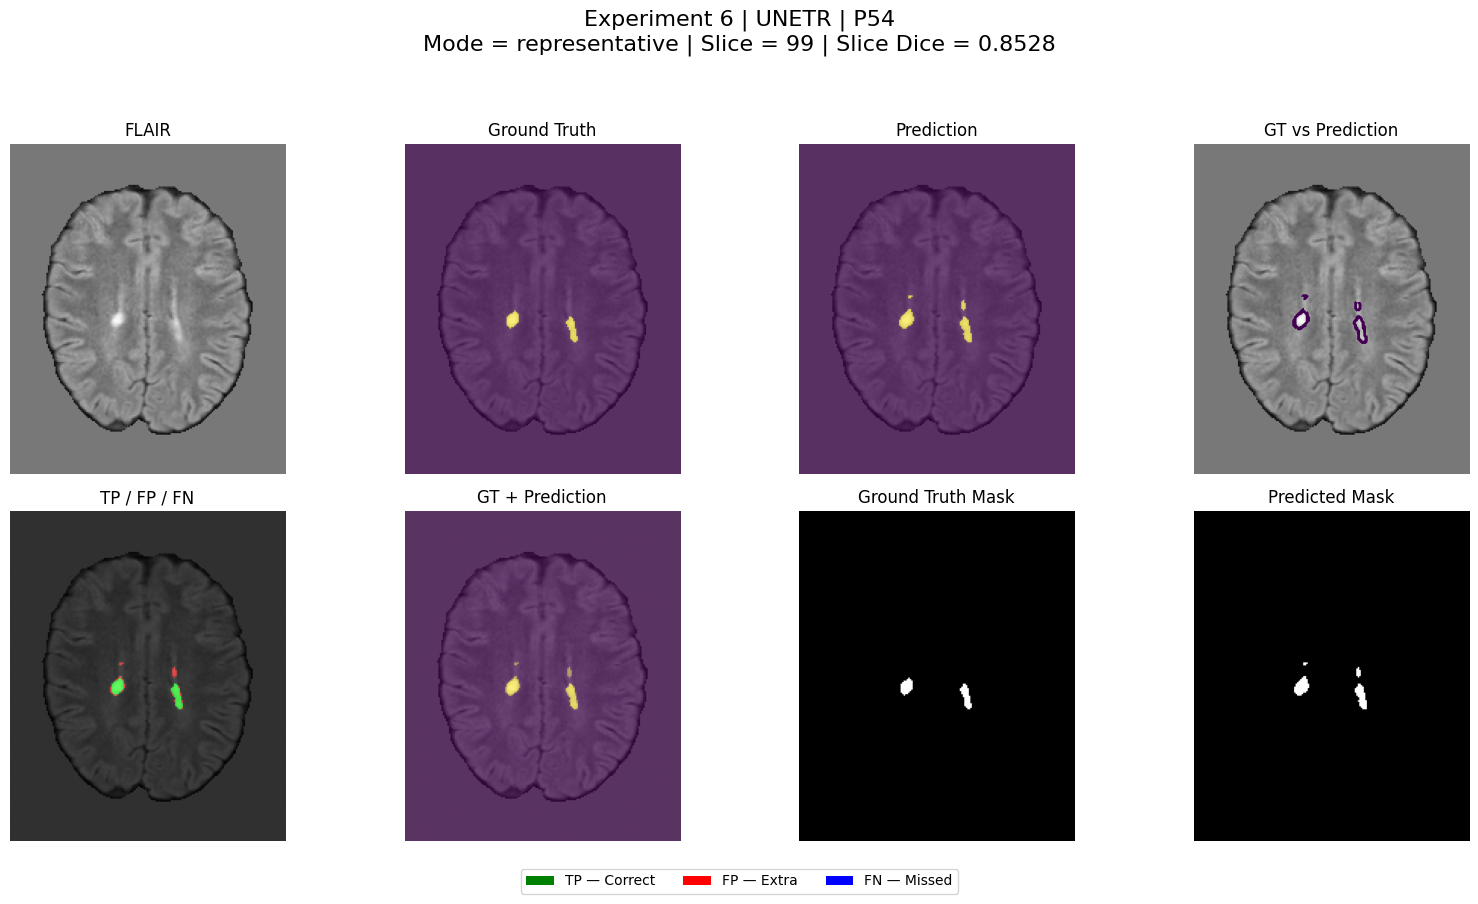


EXPERIMENT 6 — UNETR | P54
Visualization mode : representative
Slice              : 99
GT lesion voxels   : 139
Predicted voxels   : 187
TP                 : 139
FP                 : 48
FN                 : 0
Precision          : 0.7433
Recall             : 1.0000
Dice               : 0.8528
IoU                : 0.7433

PATIENT 2/22 — P55


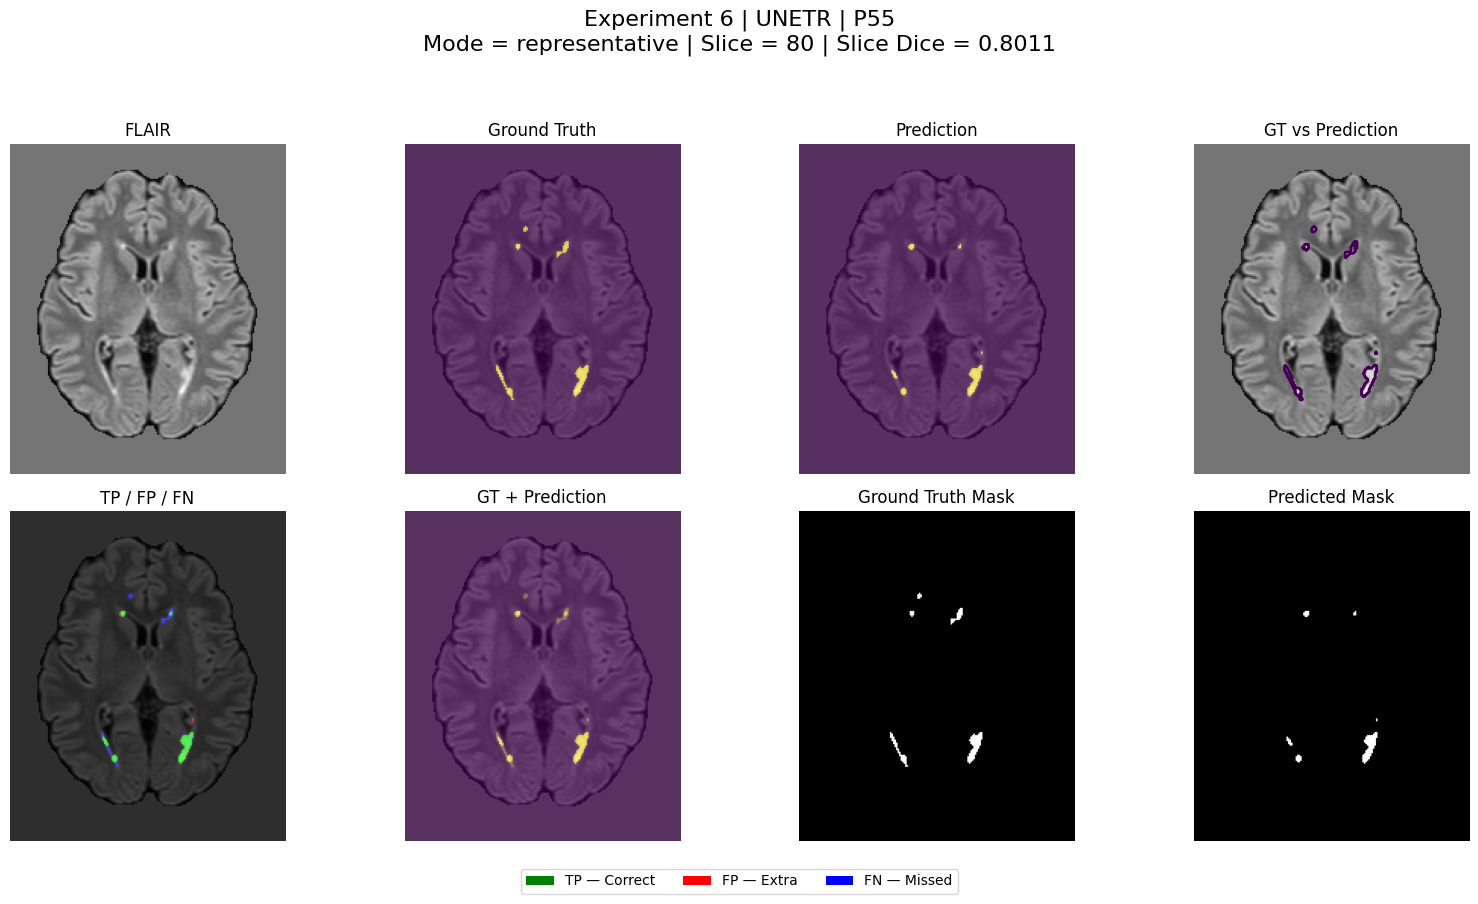


EXPERIMENT 6 — UNETR | P55
Visualization mode : representative
Slice              : 80
GT lesion voxels   : 211
Predicted voxels   : 156
TP                 : 147
FP                 : 9
FN                 : 64
Precision          : 0.9423
Recall             : 0.6967
Dice               : 0.8011
IoU                : 0.6682

PATIENT 3/22 — P56


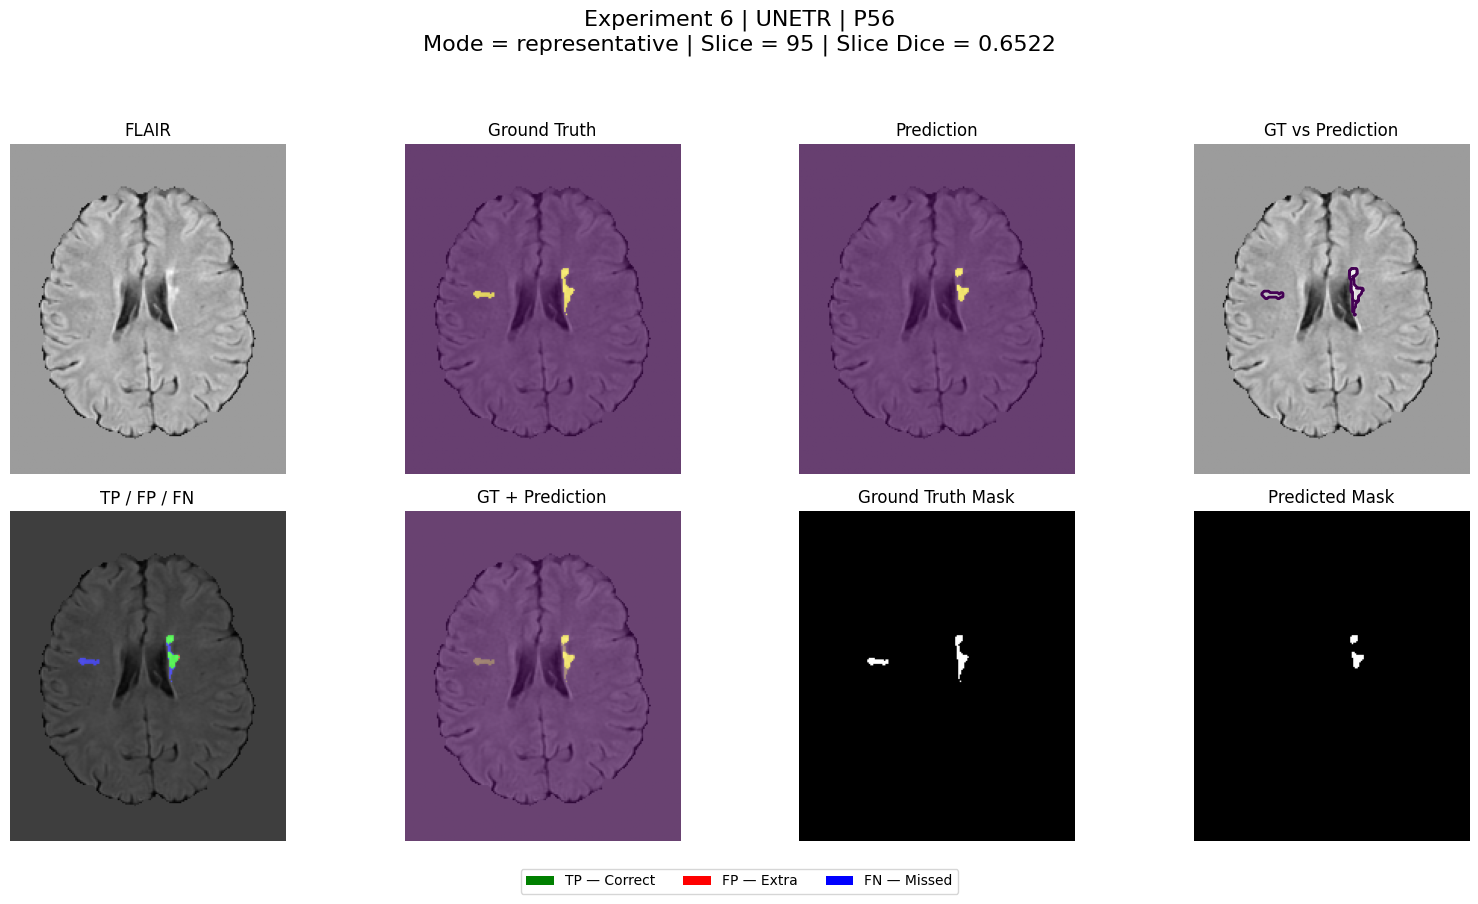


EXPERIMENT 6 — UNETR | P56
Visualization mode : representative
Slice              : 95
GT lesion voxels   : 153
Predicted voxels   : 77
TP                 : 75
FP                 : 2
FN                 : 78
Precision          : 0.9740
Recall             : 0.4902
Dice               : 0.6522
IoU                : 0.4839

PATIENT 4/22 — P57


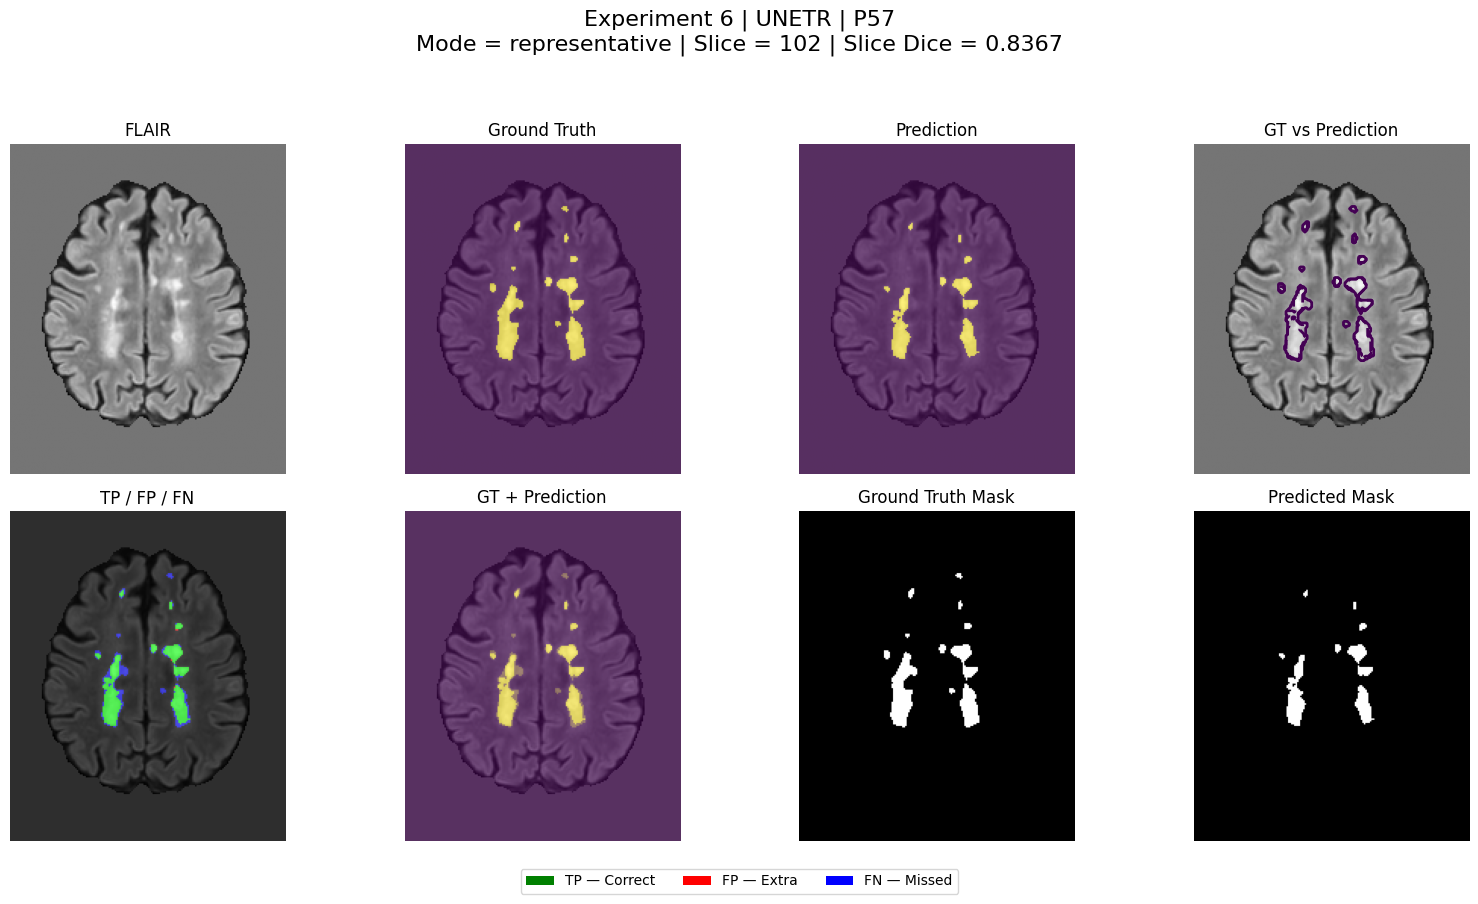


EXPERIMENT 6 — UNETR | P57
Visualization mode : representative
Slice              : 102
GT lesion voxels   : 1,036
Predicted voxels   : 752
TP                 : 748
FP                 : 4
FN                 : 288
Precision          : 0.9947
Recall             : 0.7220
Dice               : 0.8367
IoU                : 0.7192

PATIENT 5/22 — P58


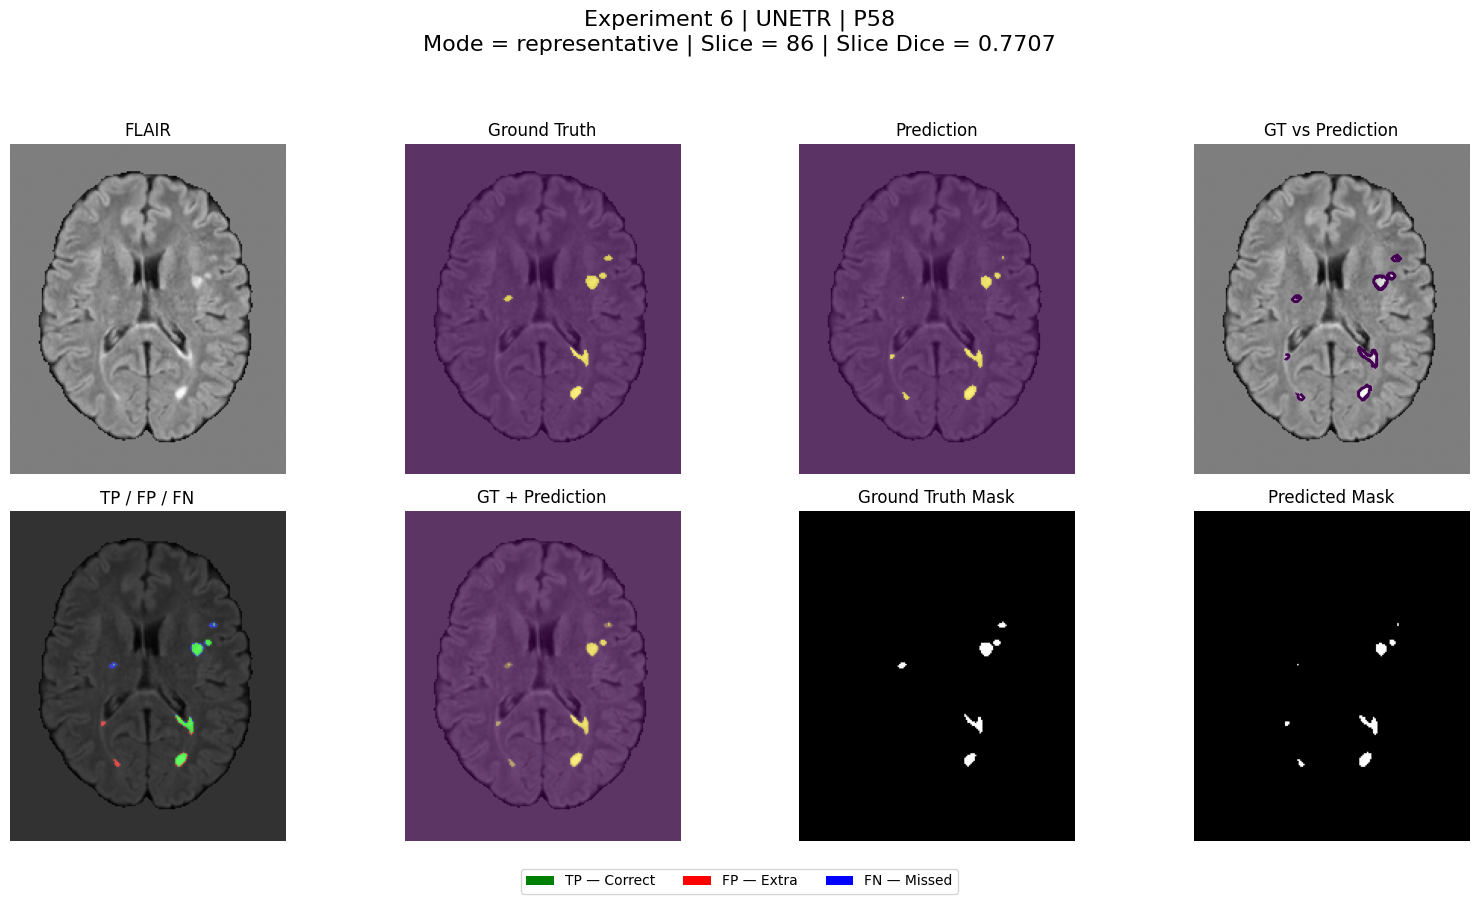


EXPERIMENT 6 — UNETR | P58
Visualization mode : representative
Slice              : 86
GT lesion voxels   : 210
Predicted voxels   : 200
TP                 : 158
FP                 : 42
FN                 : 52
Precision          : 0.7900
Recall             : 0.7524
Dice               : 0.7707
IoU                : 0.6270

PATIENT 6/22 — P59


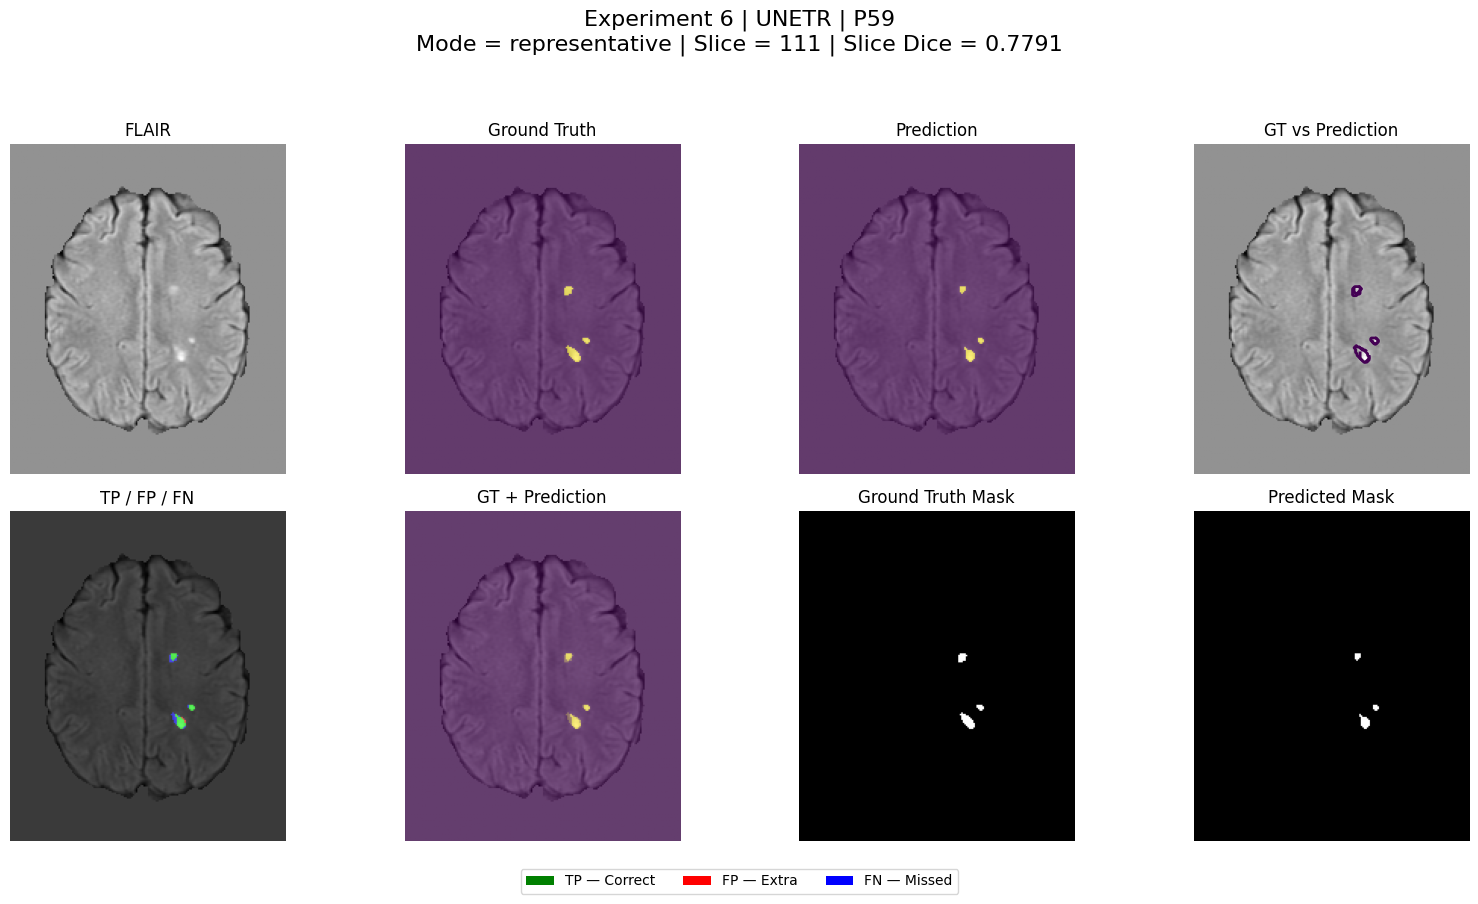


EXPERIMENT 6 — UNETR | P59
Visualization mode : representative
Slice              : 111
GT lesion voxels   : 101
Predicted voxels   : 71
TP                 : 67
FP                 : 4
FN                 : 34
Precision          : 0.9437
Recall             : 0.6634
Dice               : 0.7791
IoU                : 0.6381

PATIENT 7/22 — P60


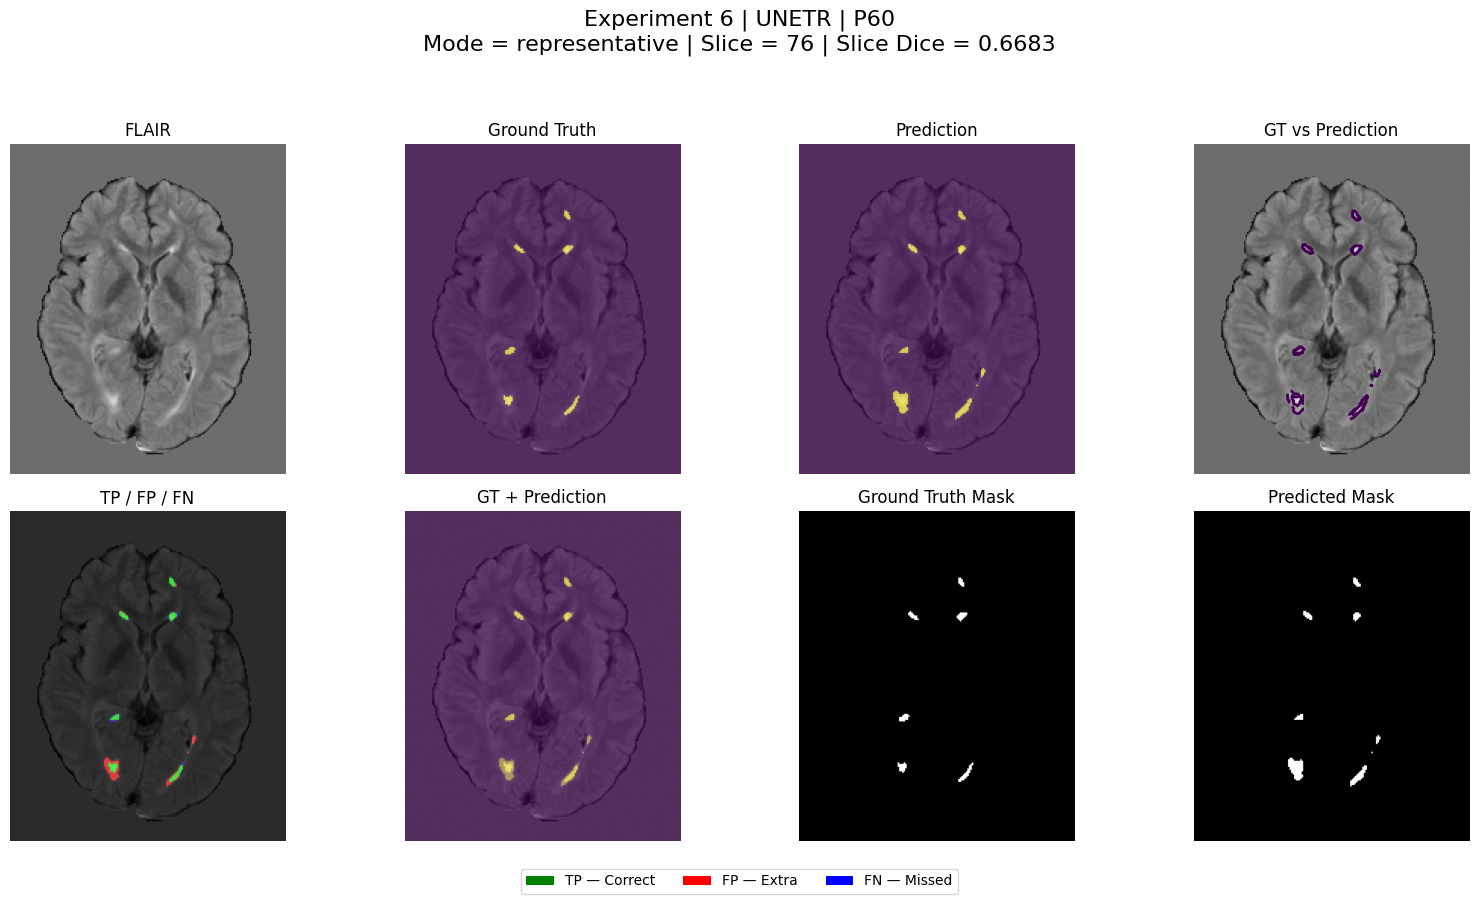


EXPERIMENT 6 — UNETR | P60
Visualization mode : representative
Slice              : 76
GT lesion voxels   : 151
Predicted voxels   : 253
TP                 : 135
FP                 : 118
FN                 : 16
Precision          : 0.5336
Recall             : 0.8940
Dice               : 0.6683
IoU                : 0.5019

PATIENT 8/22 — P61


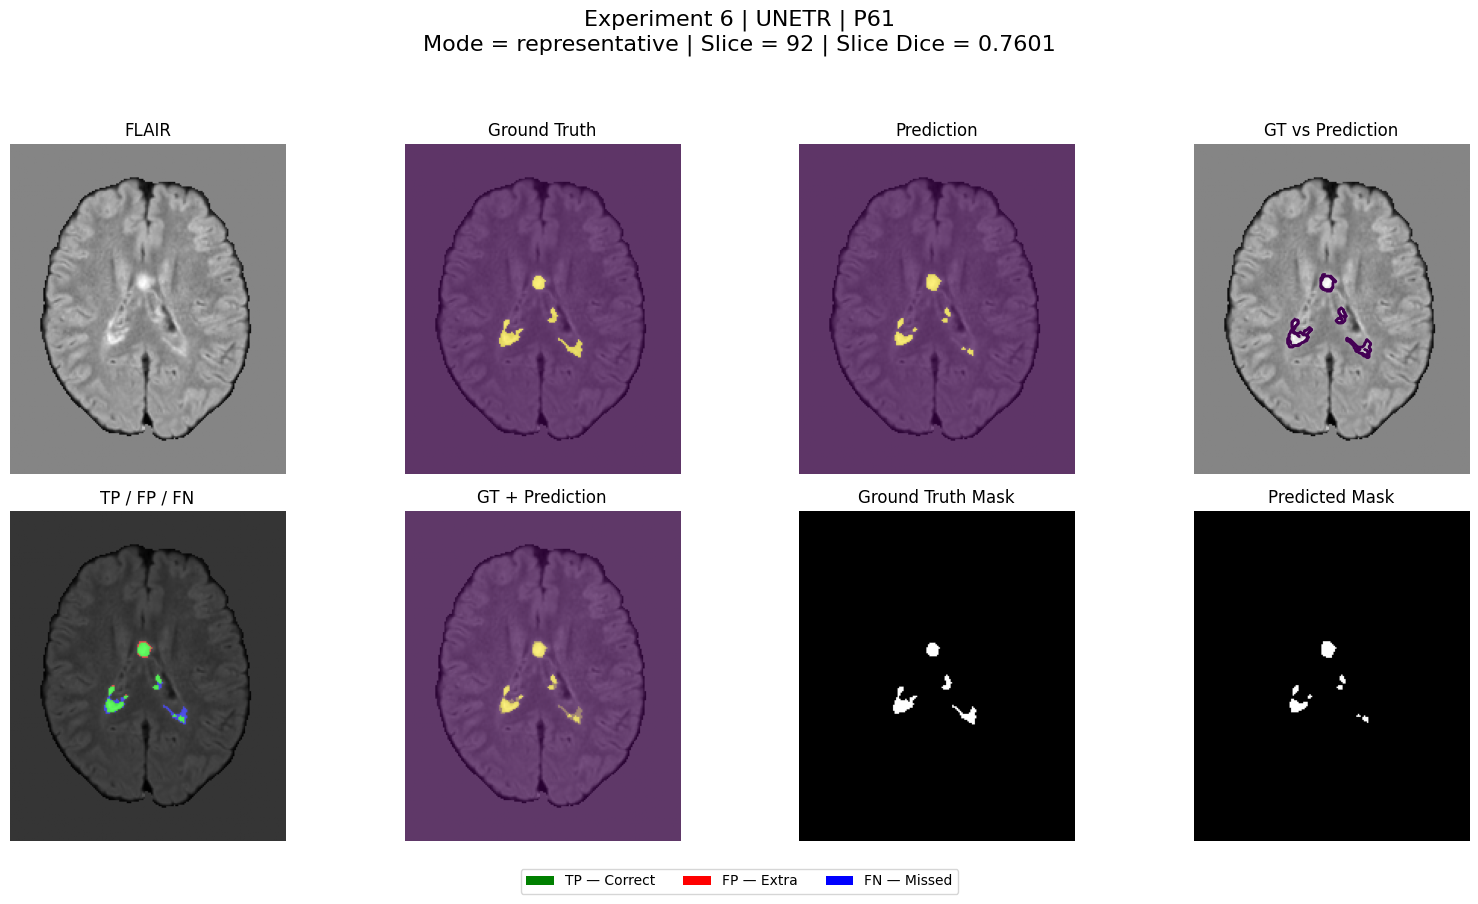


EXPERIMENT 6 — UNETR | P61
Visualization mode : representative
Slice              : 92
GT lesion voxels   : 300
Predicted voxels   : 221
TP                 : 198
FP                 : 23
FN                 : 102
Precision          : 0.8959
Recall             : 0.6600
Dice               : 0.7601
IoU                : 0.6130

PATIENT 9/22 — P62


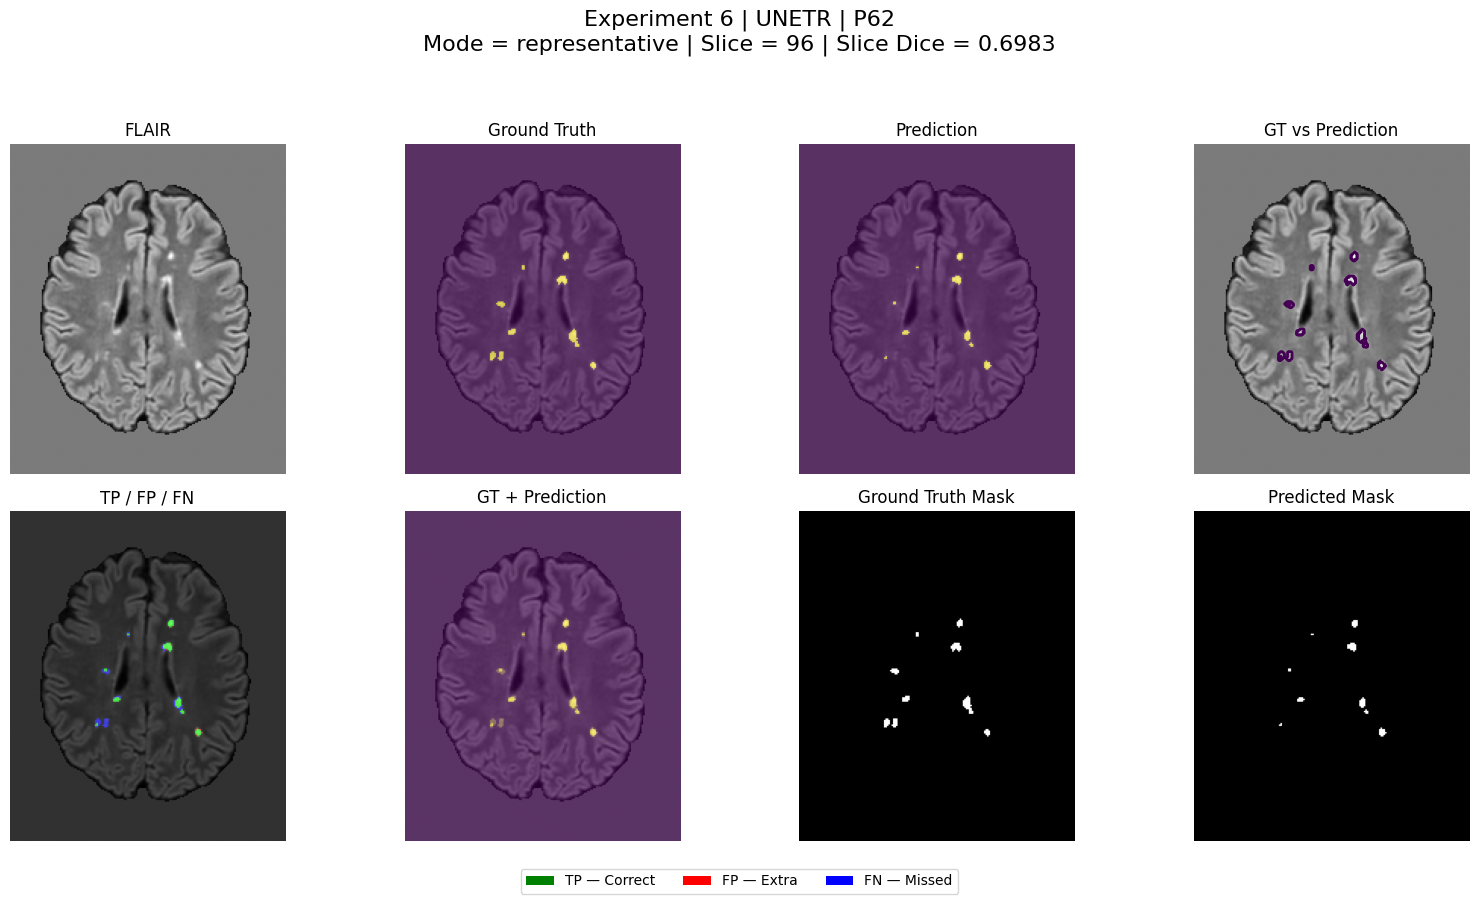


EXPERIMENT 6 — UNETR | P62
Visualization mode : representative
Slice              : 96
GT lesion voxels   : 183
Predicted voxels   : 112
TP                 : 103
FP                 : 9
FN                 : 80
Precision          : 0.9196
Recall             : 0.5628
Dice               : 0.6983
IoU                : 0.5365

PATIENT 10/22 — P63


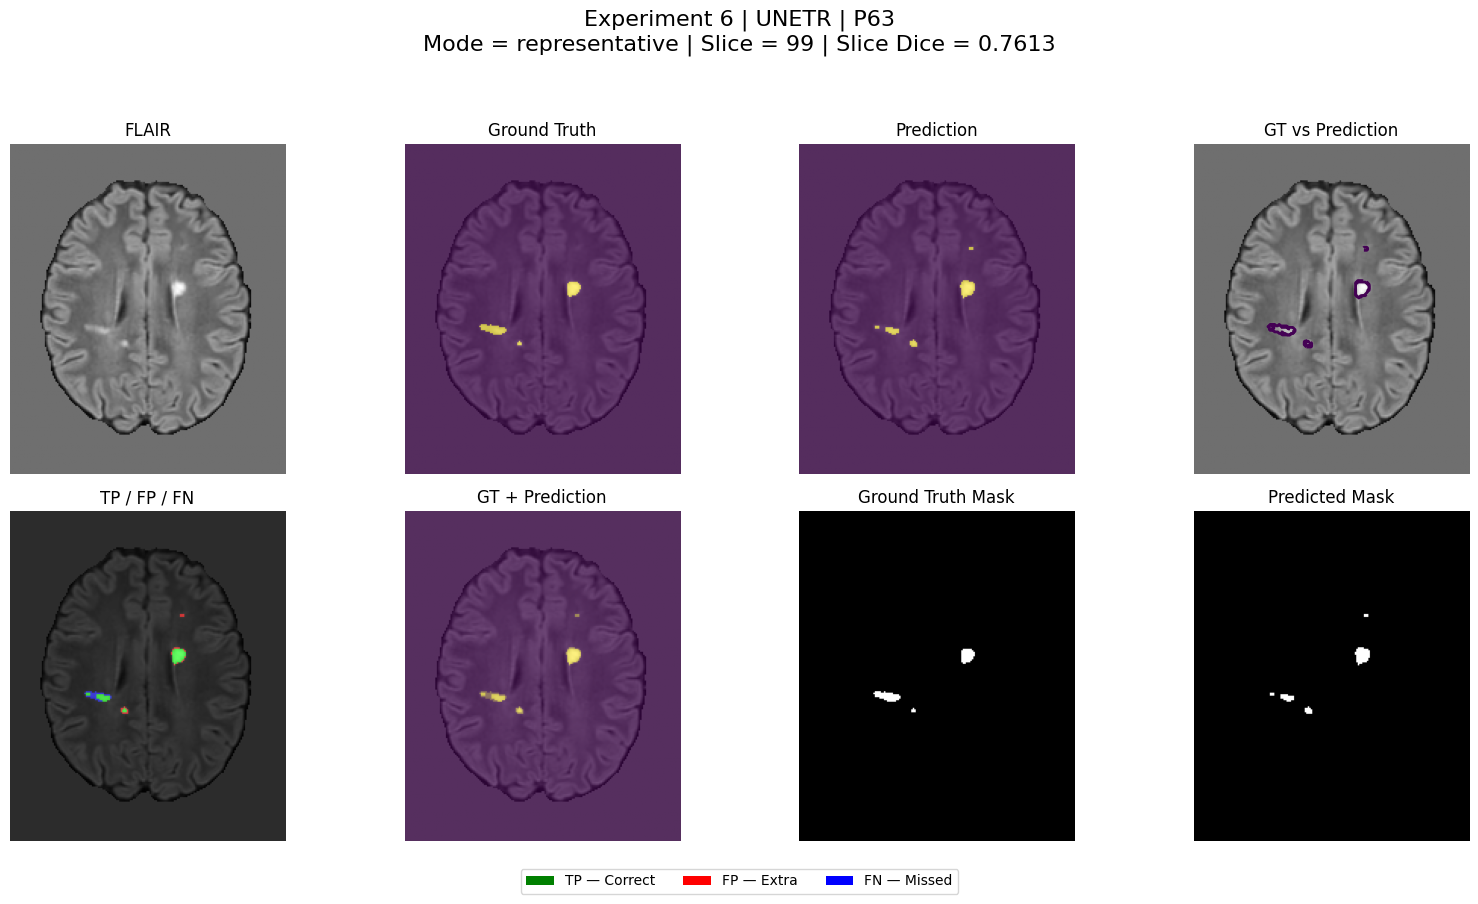


EXPERIMENT 6 — UNETR | P63
Visualization mode : representative
Slice              : 99
GT lesion voxels   : 160
Predicted voxels   : 150
TP                 : 118
FP                 : 32
FN                 : 42
Precision          : 0.7867
Recall             : 0.7375
Dice               : 0.7613
IoU                : 0.6146

PATIENT 11/22 — P64


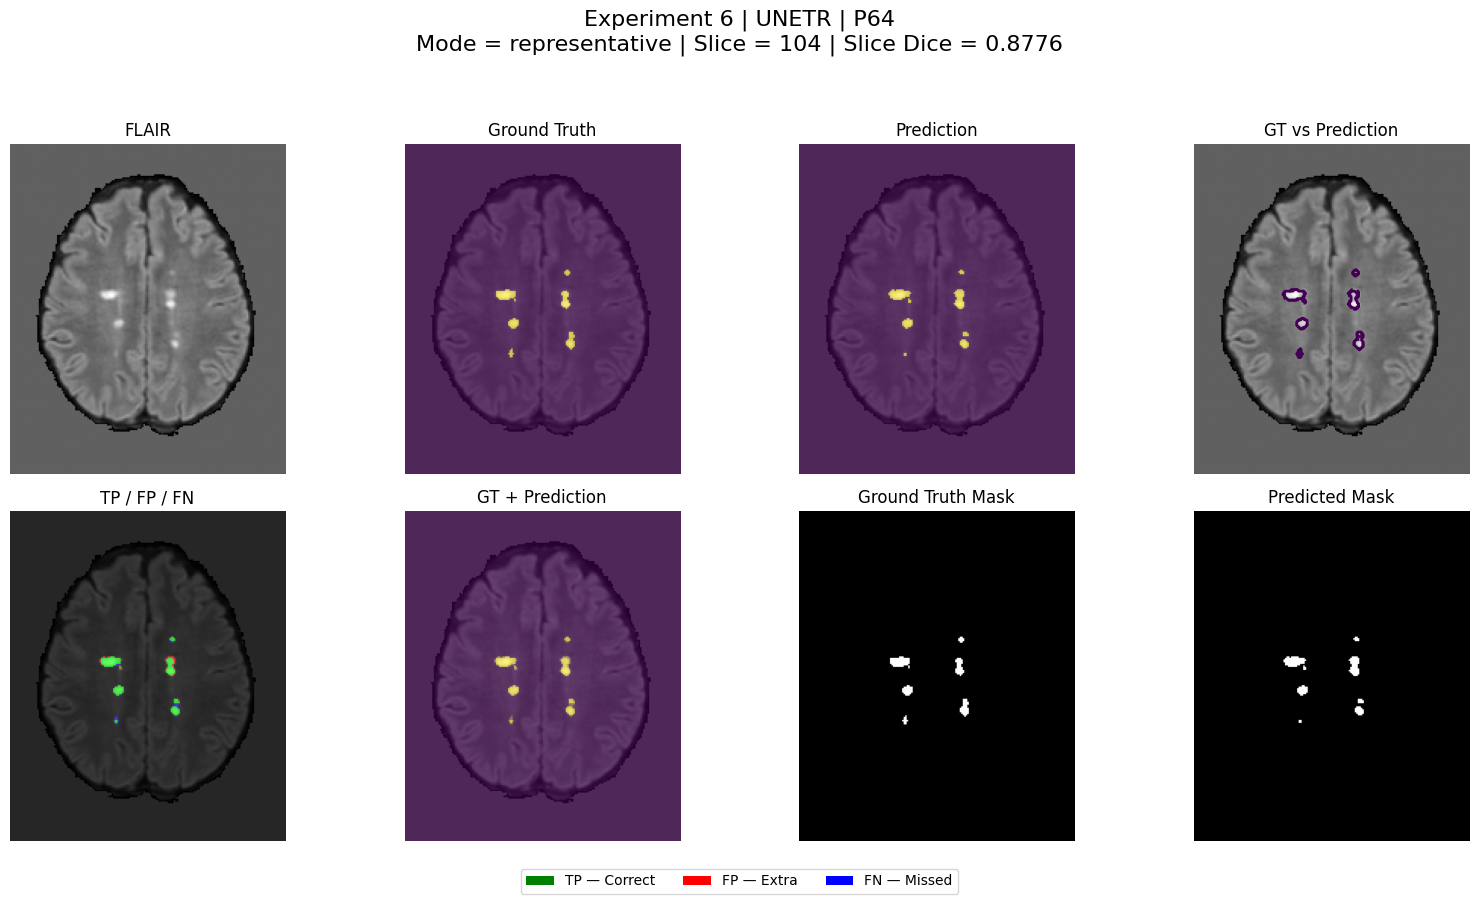


EXPERIMENT 6 — UNETR | P64
Visualization mode : representative
Slice              : 104
GT lesion voxels   : 234
Predicted voxels   : 240
TP                 : 208
FP                 : 32
FN                 : 26
Precision          : 0.8667
Recall             : 0.8889
Dice               : 0.8776
IoU                : 0.7820

PATIENT 12/22 — P65


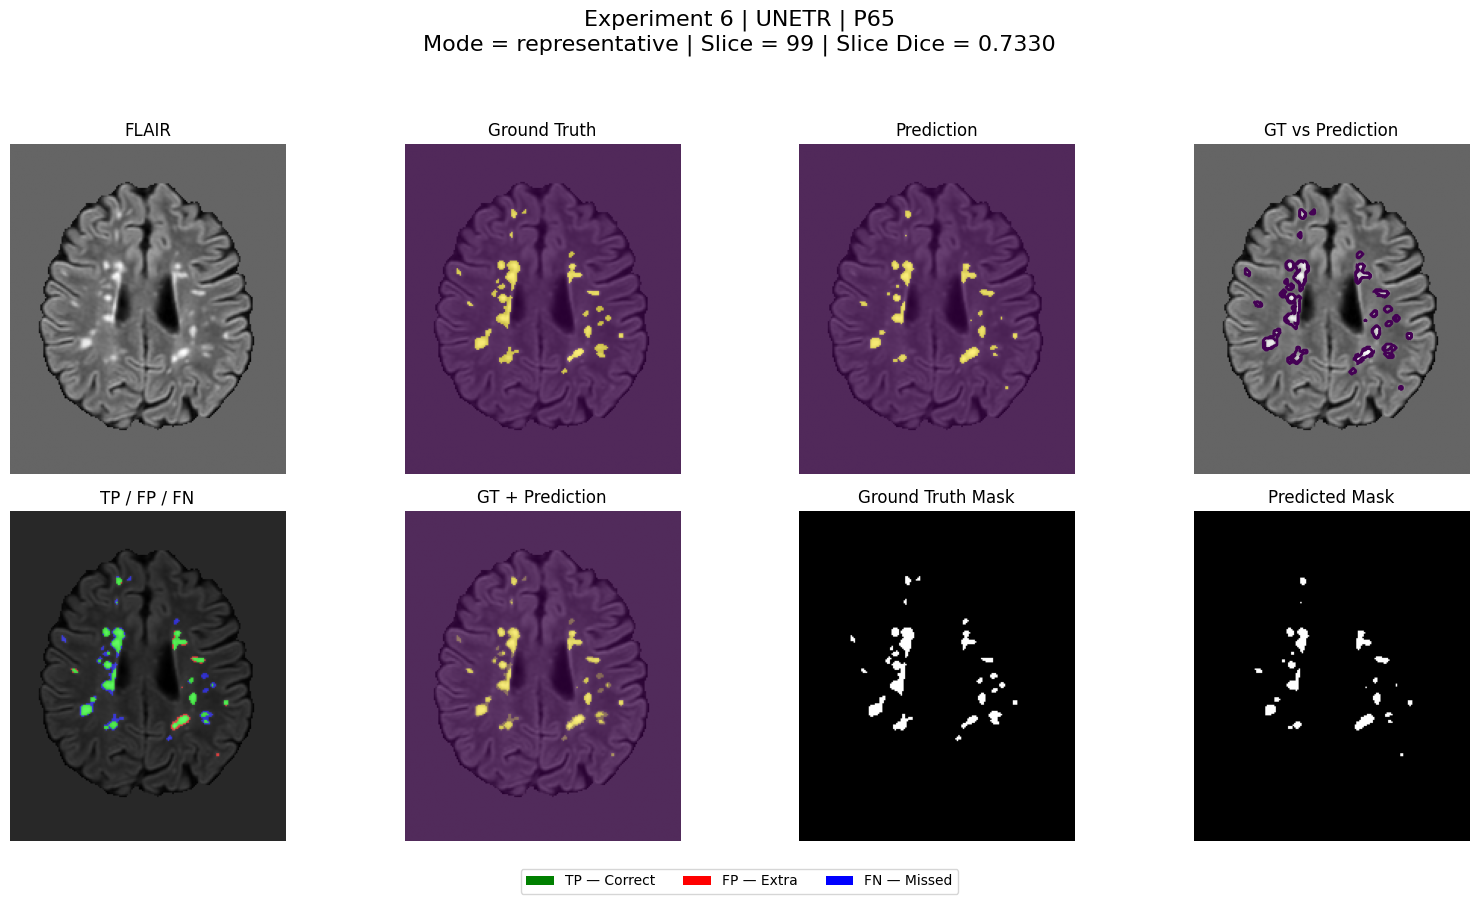


EXPERIMENT 6 — UNETR | P65
Visualization mode : representative
Slice              : 99
GT lesion voxels   : 772
Predicted voxels   : 554
TP                 : 486
FP                 : 68
FN                 : 286
Precision          : 0.8773
Recall             : 0.6295
Dice               : 0.7330
IoU                : 0.5786

PATIENT 13/22 — P66


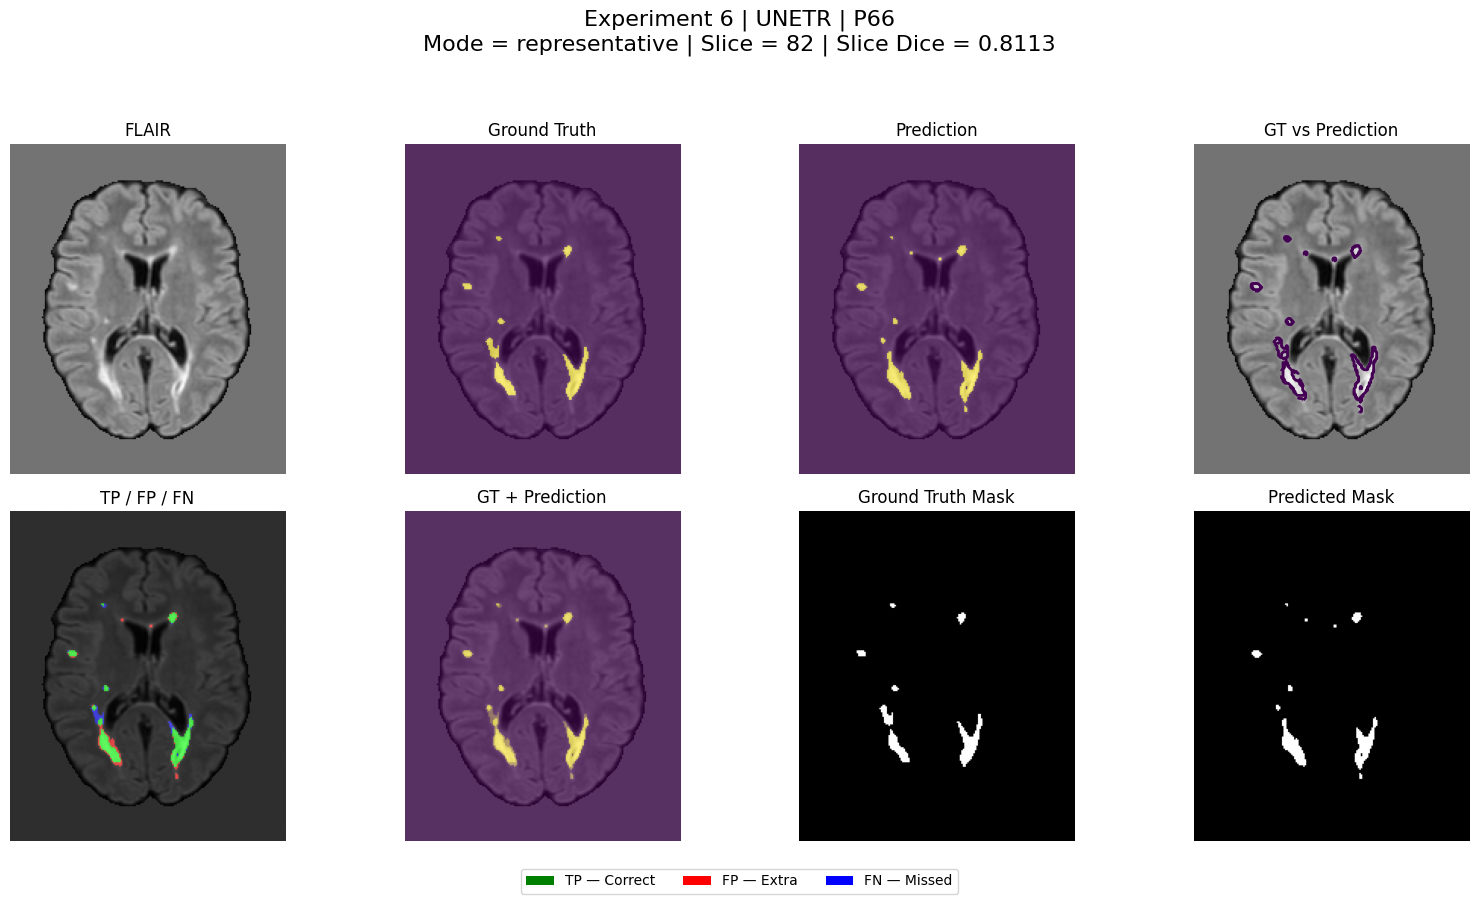


EXPERIMENT 6 — UNETR | P66
Visualization mode : representative
Slice              : 82
GT lesion voxels   : 497
Predicted voxels   : 526
TP                 : 415
FP                 : 111
FN                 : 82
Precision          : 0.7890
Recall             : 0.8350
Dice               : 0.8113
IoU                : 0.6826

PATIENT 14/22 — P67


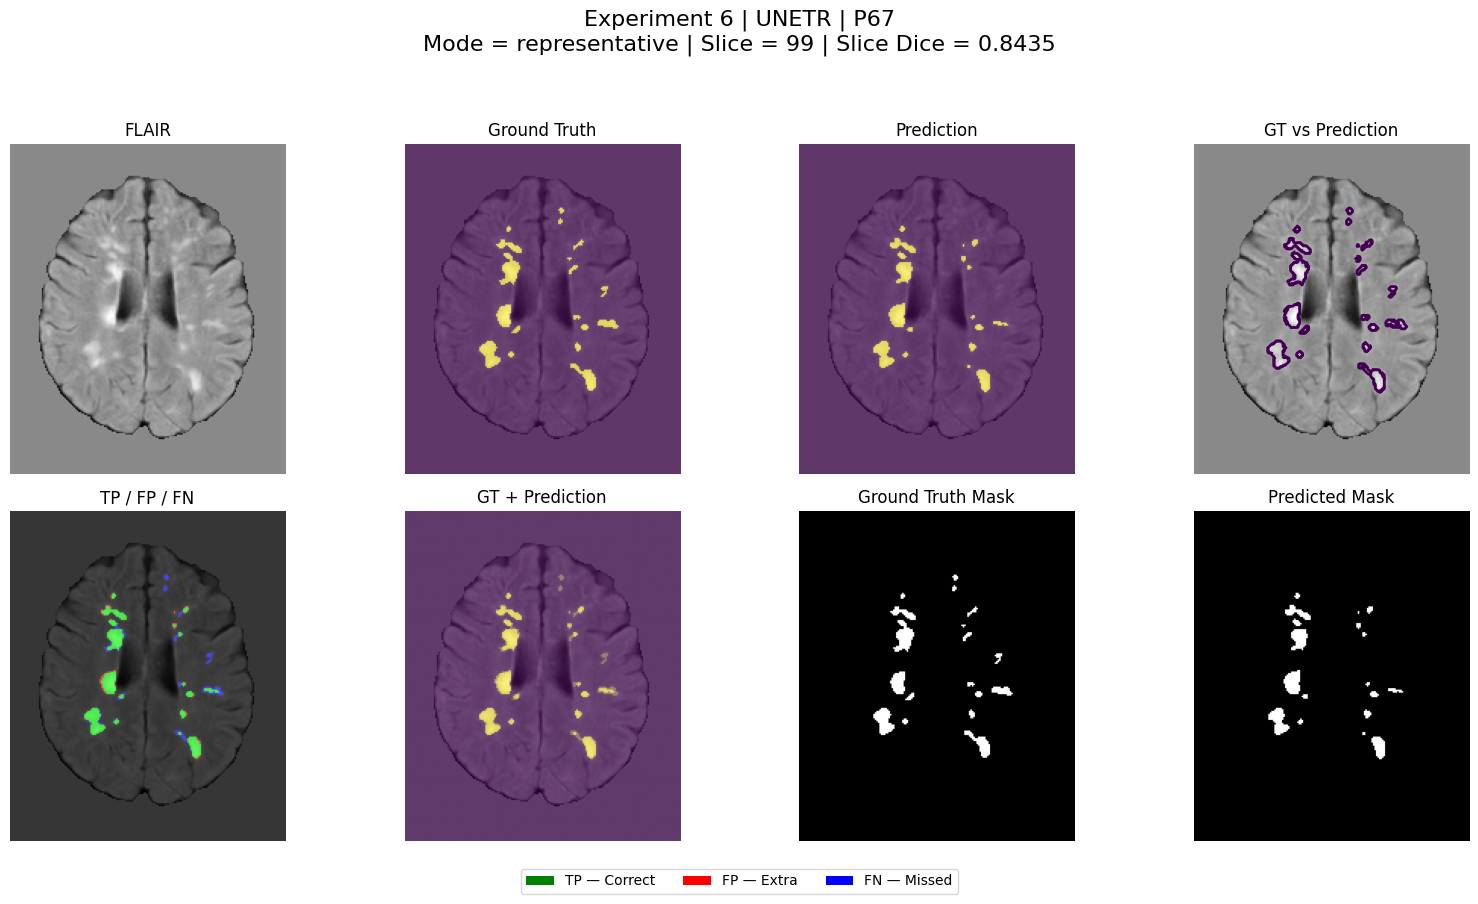


EXPERIMENT 6 — UNETR | P67
Visualization mode : representative
Slice              : 99
GT lesion voxels   : 830
Predicted voxels   : 716
TP                 : 652
FP                 : 64
FN                 : 178
Precision          : 0.9106
Recall             : 0.7855
Dice               : 0.8435
IoU                : 0.7293

PATIENT 15/22 — P68


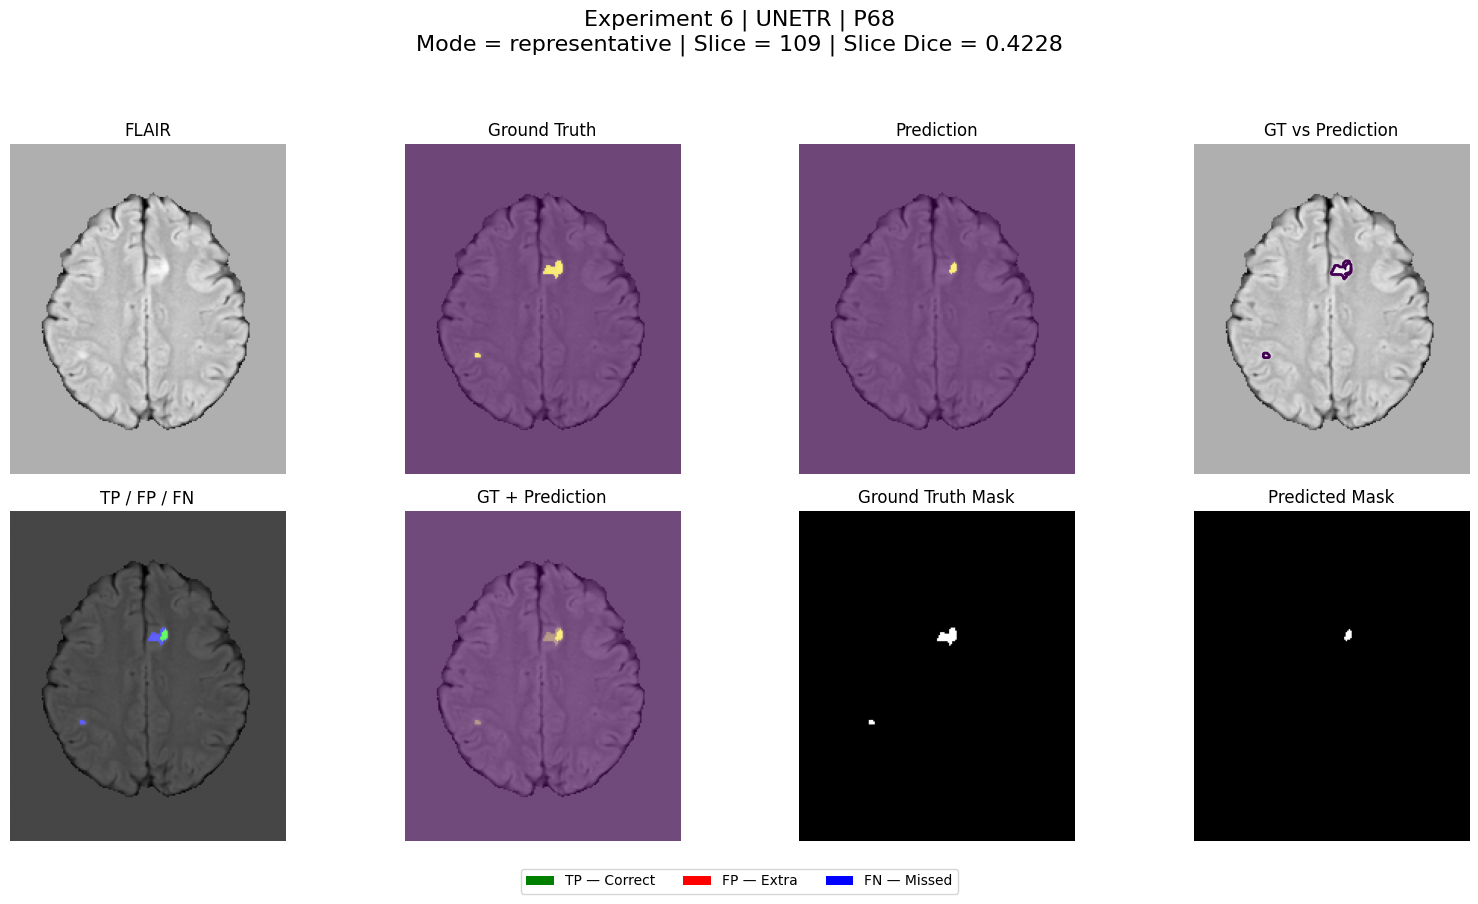


EXPERIMENT 6 — UNETR | P68
Visualization mode : representative
Slice              : 109
GT lesion voxels   : 97
Predicted voxels   : 26
TP                 : 26
FP                 : 0
FN                 : 71
Precision          : 1.0000
Recall             : 0.2680
Dice               : 0.4228
IoU                : 0.2680

PATIENT 16/22 — P69


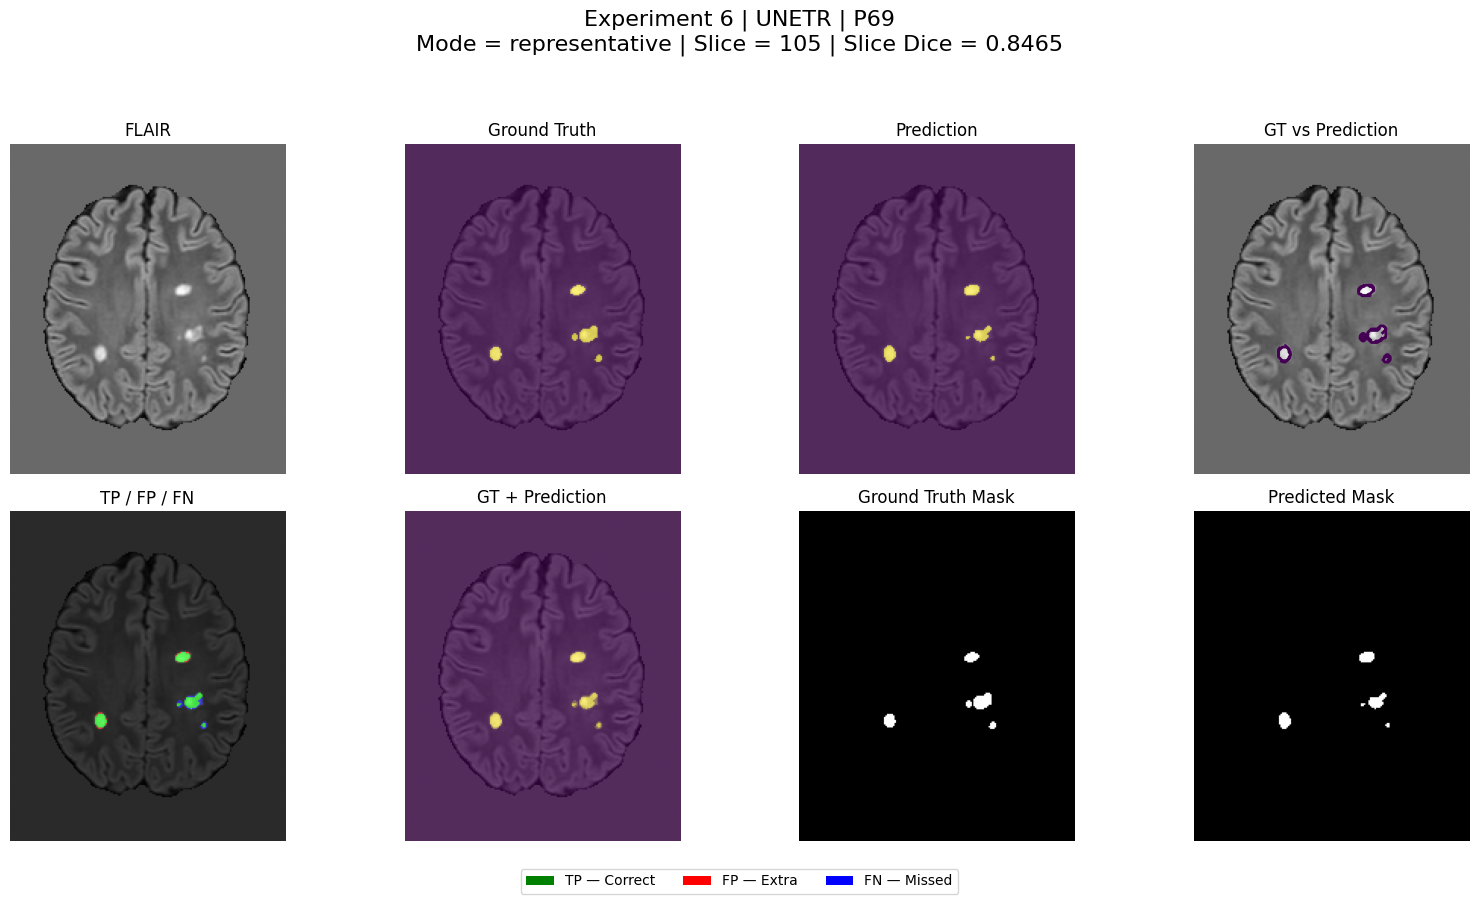


EXPERIMENT 6 — UNETR | P69
Visualization mode : representative
Slice              : 105
GT lesion voxels   : 241
Predicted voxels   : 215
TP                 : 193
FP                 : 22
FN                 : 48
Precision          : 0.8977
Recall             : 0.8008
Dice               : 0.8465
IoU                : 0.7338

PATIENT 17/22 — P70


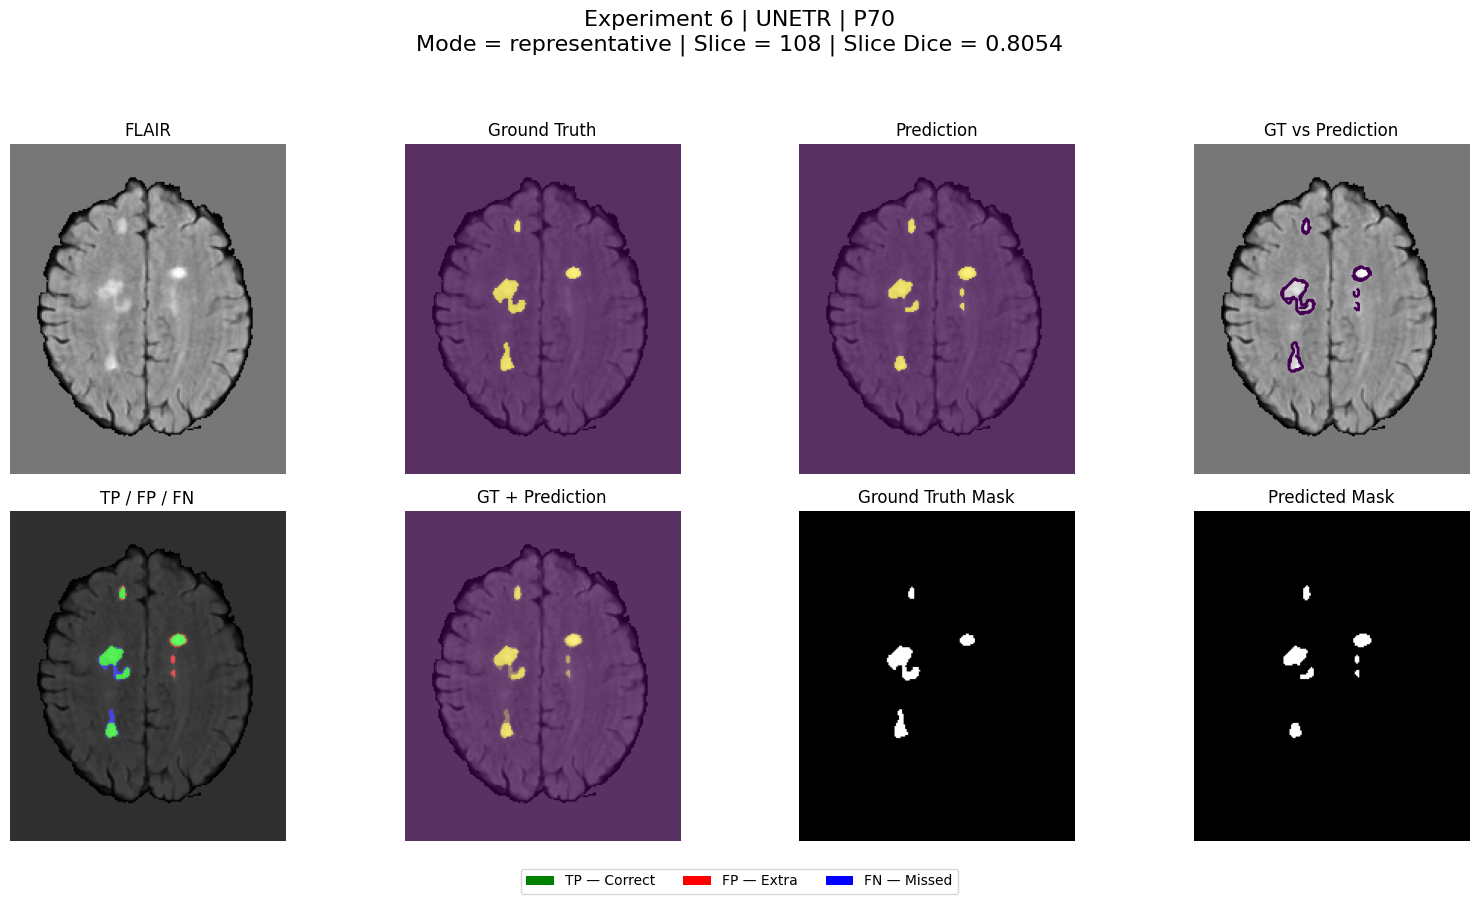


EXPERIMENT 6 — UNETR | P70
Visualization mode : representative
Slice              : 108
GT lesion voxels   : 428
Predicted voxels   : 384
TP                 : 327
FP                 : 57
FN                 : 101
Precision          : 0.8516
Recall             : 0.7640
Dice               : 0.8054
IoU                : 0.6742

PATIENT 18/22 — P71


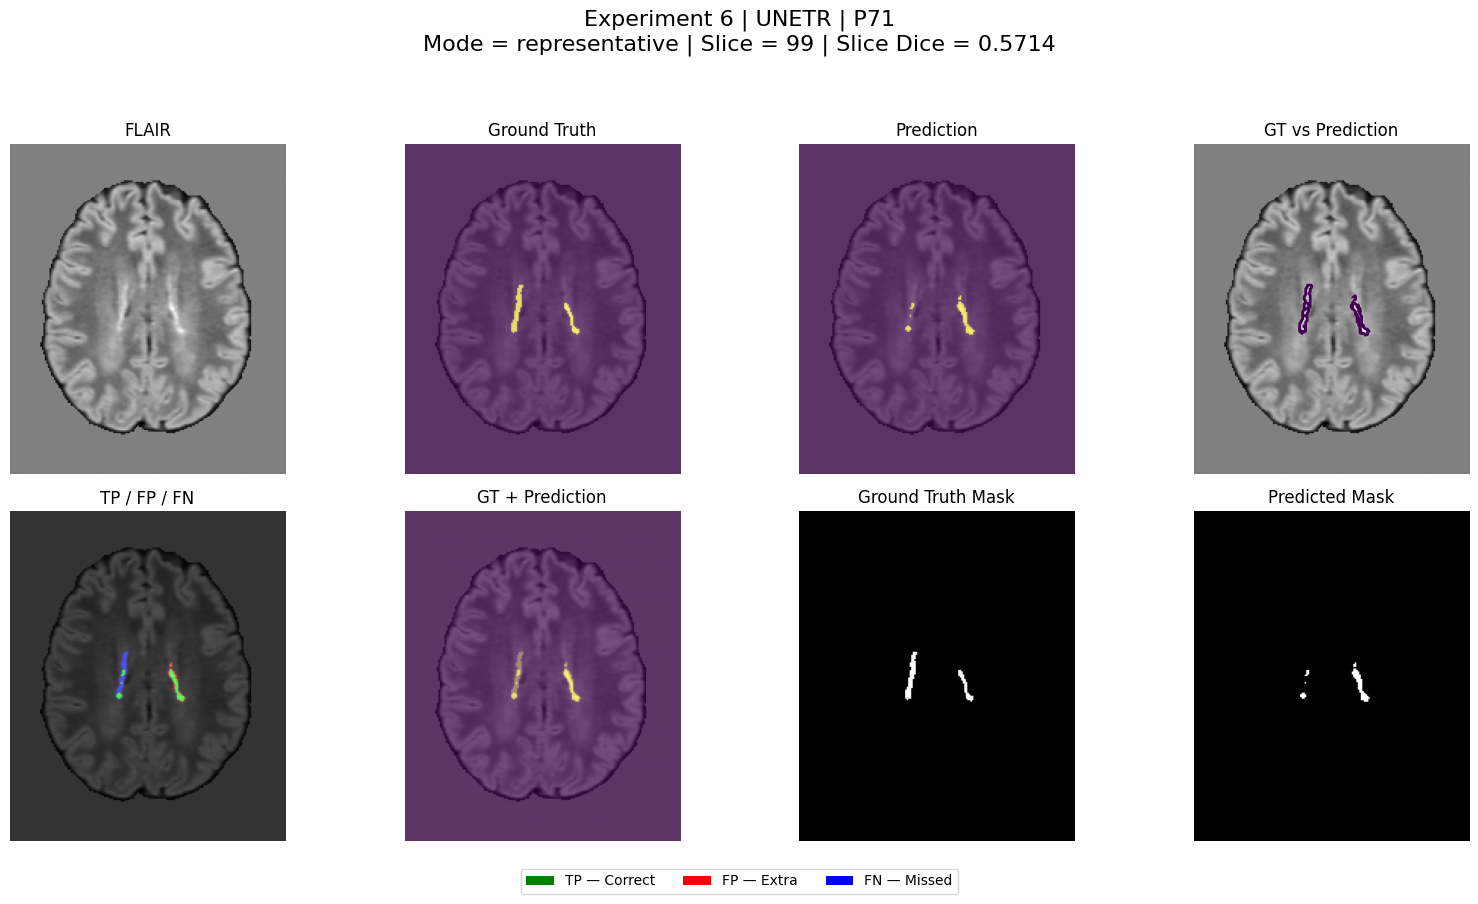


EXPERIMENT 6 — UNETR | P71
Visualization mode : representative
Slice              : 99
GT lesion voxels   : 164
Predicted voxels   : 109
TP                 : 78
FP                 : 31
FN                 : 86
Precision          : 0.7156
Recall             : 0.4756
Dice               : 0.5714
IoU                : 0.4000

PATIENT 19/22 — P72


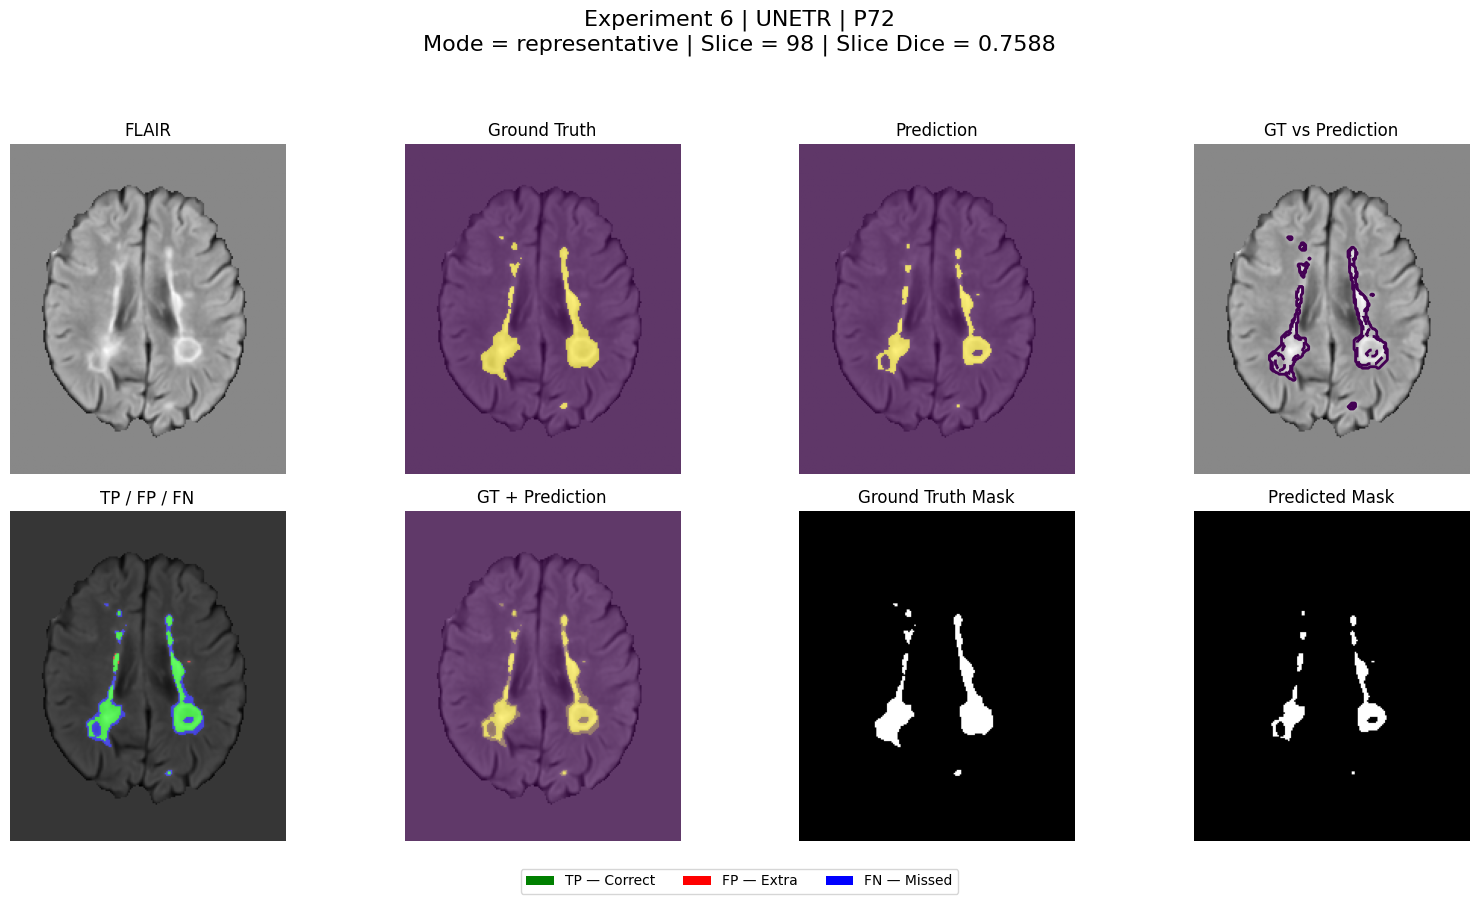


EXPERIMENT 6 — UNETR | P72
Visualization mode : representative
Slice              : 98
GT lesion voxels   : 1,331
Predicted voxels   : 825
TP                 : 818
FP                 : 7
FN                 : 513
Precision          : 0.9915
Recall             : 0.6146
Dice               : 0.7588
IoU                : 0.6114

PATIENT 20/22 — P73


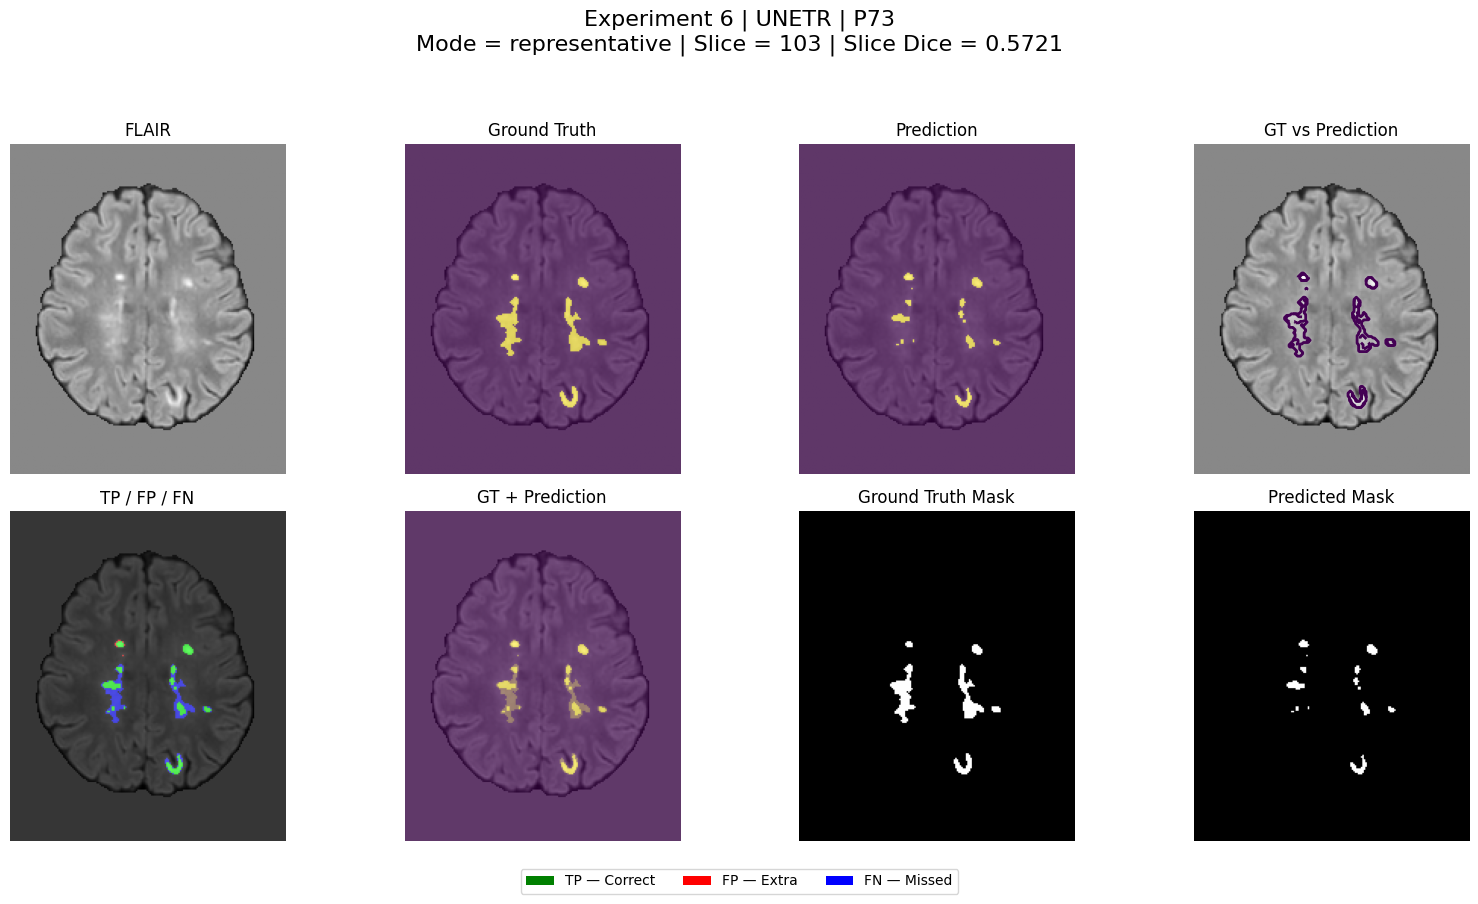


EXPERIMENT 6 — UNETR | P73
Visualization mode : representative
Slice              : 103
GT lesion voxels   : 645
Predicted voxels   : 271
TP                 : 262
FP                 : 9
FN                 : 383
Precision          : 0.9668
Recall             : 0.4062
Dice               : 0.5721
IoU                : 0.4006

PATIENT 21/22 — P74


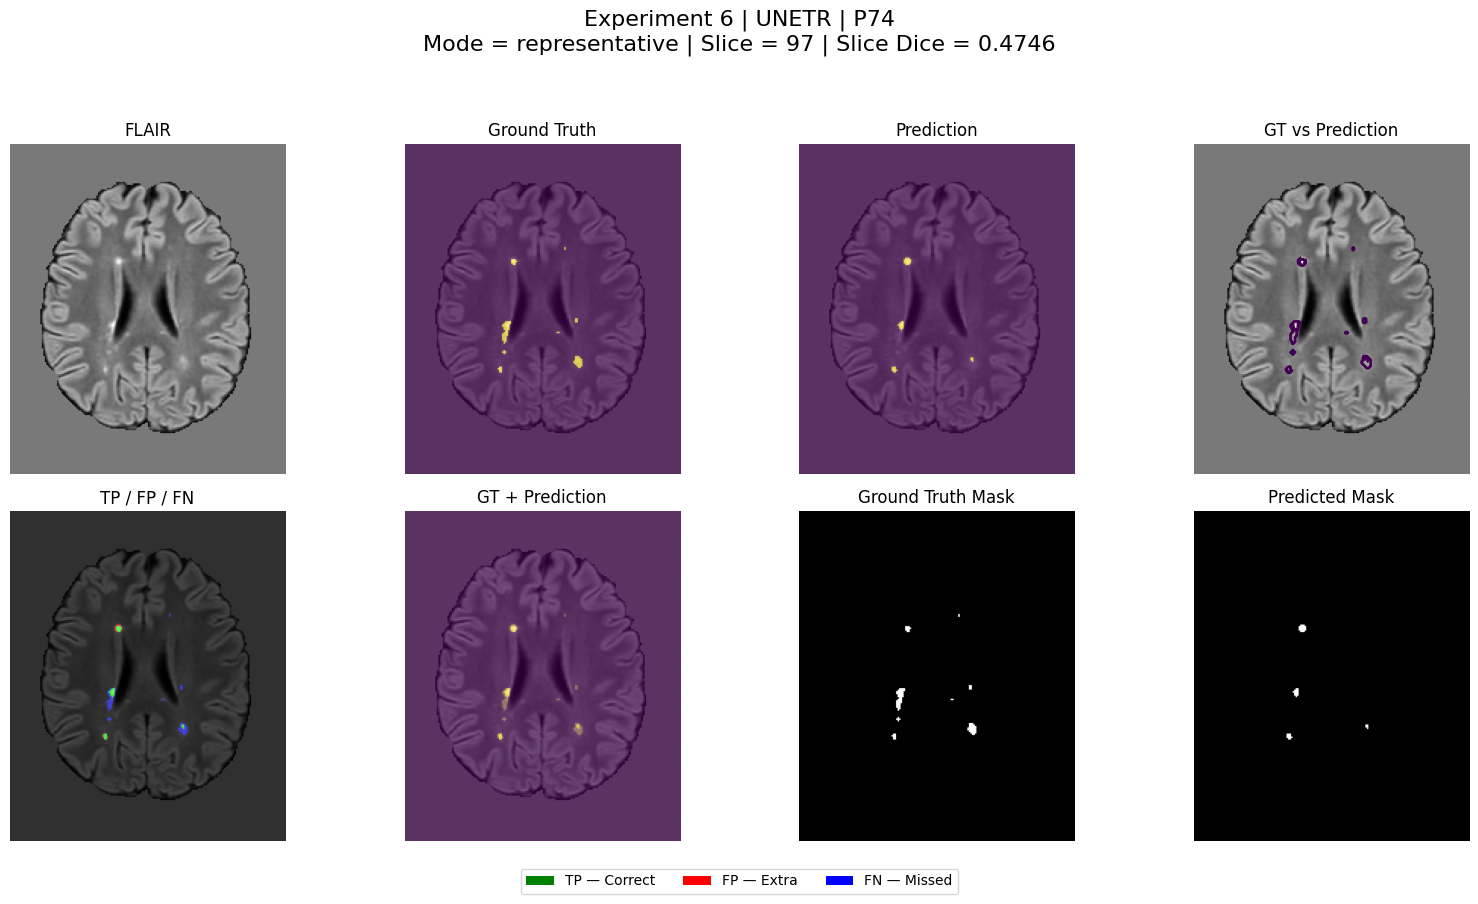


EXPERIMENT 6 — UNETR | P74
Visualization mode : representative
Slice              : 97
GT lesion voxels   : 123
Predicted voxels   : 54
TP                 : 42
FP                 : 12
FN                 : 81
Precision          : 0.7778
Recall             : 0.3415
Dice               : 0.4746
IoU                : 0.3111

PATIENT 22/22 — P75


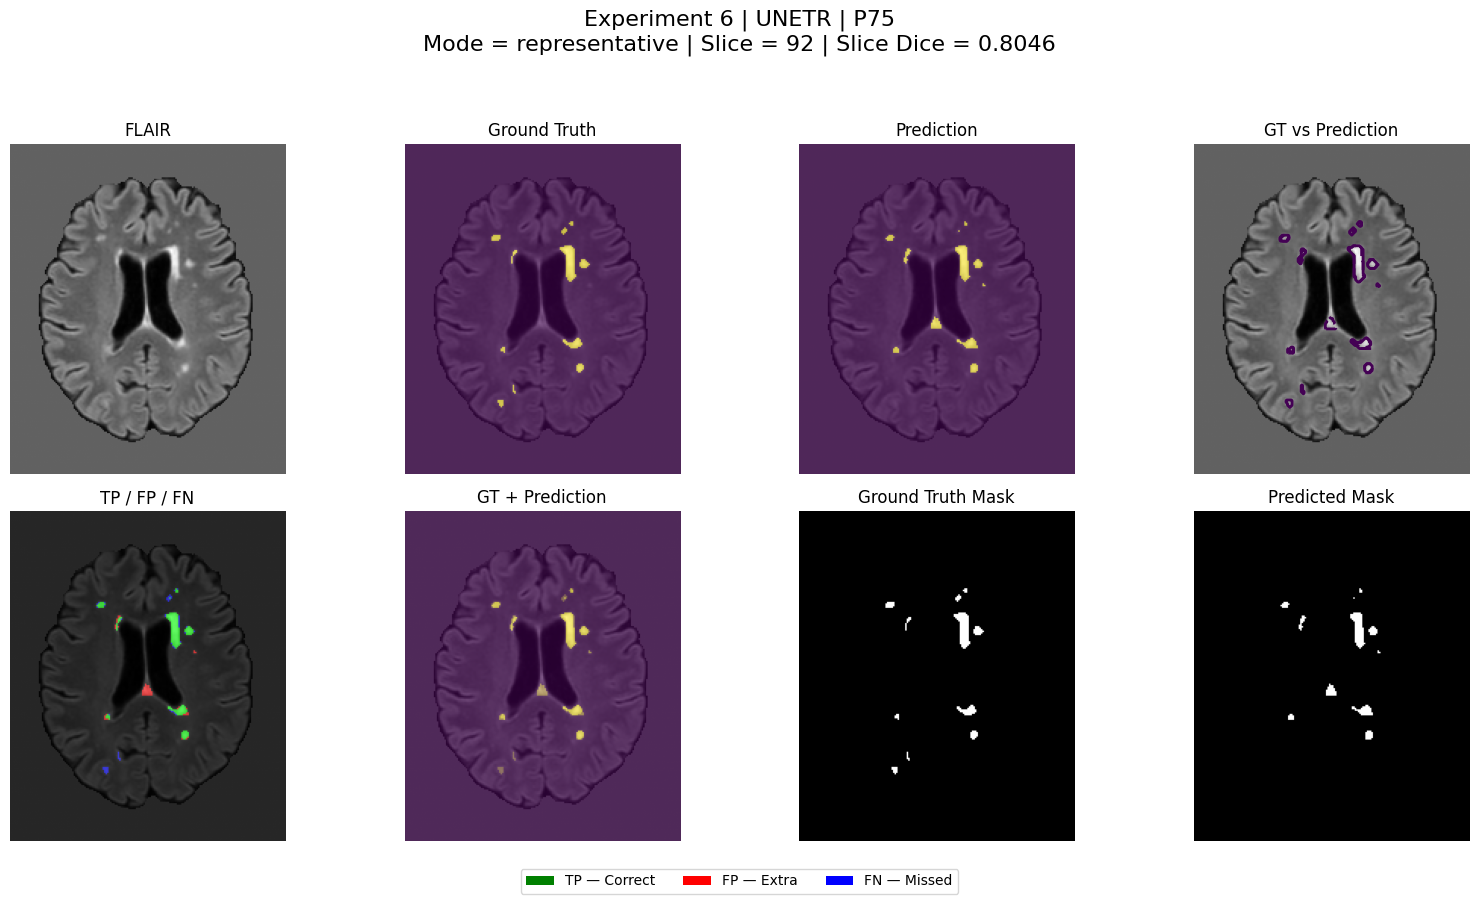


EXPERIMENT 6 — UNETR | P75
Visualization mode : representative
Slice              : 92
GT lesion voxels   : 342
Predicted voxels   : 349
TP                 : 278
FP                 : 71
FN                 : 64
Precision          : 0.7966
Recall             : 0.8129
Dice               : 0.8046
IoU                : 0.6731


In [8]:
# ============================================================
# EXPERIMENT 6 — VISUALIZE ALL 22 TEST PATIENTS
# REPRESENTATIVE SLICE
# ============================================================

print("=" * 80)
print("EXPERIMENT 6 — UNETR ALL 22 TEST VISUALIZATIONS")
print("=" * 80)

print(
    "Total patients:",
    len(test_files_unetr_exp6)
)

print(
    "Slice mode:",
    "representative"
)

print("=" * 80)


for i, item in enumerate(
    test_files_unetr_exp6,
    start=1
):

    patient = item["patient"]

    print(
        f"\nPATIENT {i}/"
        f"{len(test_files_unetr_exp6)} — "
        f"{patient}"
    )

    visualize_unetr_exp6(
        patient=patient,
        slice_mode="representative"
    )

## analysis starts here

In [9]:
# ============================================================
# EXPERIMENT 6 — UNETR
# HARD / LOW-BRIGHTNESS LESION ANALYSIS
#
# Purpose:
#   Determine whether FLAIR brightness is related to
#   lesion detection failure.
#
# NO TRAINING
# NO MODEL MODIFICATION
# ============================================================

import os
import numpy as np
import pandas as pd
import nibabel as nib


# ============================================================
# 1. MAIN ROOT
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)


# ============================================================
# 2. EXPERIMENT 6 TEST ROOT
# ============================================================

EXP6_TEST_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed",
    "test"
)


# ============================================================
# 3. UNETR BEST MODEL
# ============================================================

EXP6_UNETR_ROOT = os.path.join(
    DATASET_ROOT,
    "Experiment_6_UNETR_FLAIR"
)

BEST_MODEL_UNETR = os.path.join(
    EXP6_UNETR_ROOT,
    "best_model_unetr_flair.pth"
)


# ============================================================
# 4. CHECK
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — HARD / LOW-BRIGHTNESS LESION ANALYSIS")
print("=" * 70)

print("\nDataset root:")
print(DATASET_ROOT)

print("\nTest root:")
print(EXP6_TEST_ROOT)

print("\nBest UNETR:")
print(BEST_MODEL_UNETR)

print("\n--- EXISTENCE CHECK ---")

print(
    "Dataset root:",
    os.path.exists(DATASET_ROOT)
)

print(
    "Test root:",
    os.path.exists(EXP6_TEST_ROOT)
)

print(
    "Best model:",
    os.path.exists(BEST_MODEL_UNETR)
)

print("=" * 70)

EXPERIMENT 6 — HARD / LOW-BRIGHTNESS LESION ANALYSIS

Dataset root:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset

Test root:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test

Best UNETR:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR_FLAIR\best_model_unetr_flair.pth

--- EXISTENCE CHECK ---
Dataset root: True
Test root: True
Best model: True


In [10]:
# ============================================================
# EXPERIMENT 6 — SINGLE PATIENT LESION BRIGHTNESS CHECK
# PATIENT: P68
# ============================================================

patient = "P68"


# ============================================================
# 1. PATHS
# ============================================================

patient_root = os.path.join(
    EXP6_TEST_ROOT,
    patient
)


flair_path = os.path.join(
    patient_root,
    f"{patient}_FLAIR_N4_Z.nii.gz"
)

mask_path = os.path.join(
    patient_root,
    f"{patient}_MASK.nii.gz"
)


print("=" * 70)
print(
    f"PATIENT {patient} — LESION BRIGHTNESS CHECK"
)
print("=" * 70)


print(
    "FLAIR exists:",
    os.path.exists(flair_path)
)

print(
    "MASK exists :",
    os.path.exists(mask_path)
)


if not os.path.exists(flair_path):
    raise FileNotFoundError(flair_path)

if not os.path.exists(mask_path):
    raise FileNotFoundError(mask_path)


# ============================================================
# 2. LOAD
# ============================================================

flair_img = nib.load(
    flair_path
)

mask_img = nib.load(
    mask_path
)


flair = flair_img.get_fdata(
    dtype=np.float32
)

mask = mask_img.get_fdata(
    dtype=np.float32
)


mask = mask > 0


# ============================================================
# 3. CHECK SHAPE
# ============================================================

print("\n--- SHAPE ---")

print(
    "FLAIR:",
    flair.shape
)

print(
    "MASK :",
    mask.shape
)


if flair.shape != mask.shape:

    raise RuntimeError(
        "FLAIR and MASK shapes do not match."
    )


# ============================================================
# 4. GT LESION INTENSITIES
# ============================================================

lesion_values = flair[
    mask
]


# ============================================================
# 5. WHOLE IMAGE STATISTICS
# ============================================================

brain_values = flair[
    flair != 0
]


print("\n--- IMAGE INTENSITY ---")

print(
    "Brain mean:",
    float(
        np.mean(brain_values)
    )
)

print(
    "Brain std :",
    float(
        np.std(brain_values)
    )
)


# ============================================================
# 6. LESION STATISTICS
# ============================================================

print("\n--- GT LESION INTENSITY ---")

print(
    "Lesion voxels:",
    len(lesion_values)
)

print(
    "Minimum:",
    float(
        np.min(lesion_values)
    )
)

print(
    "Maximum:",
    float(
        np.max(lesion_values)
    )
)

print(
    "Mean:",
    float(
        np.mean(lesion_values)
    )
)

print(
    "Median:",
    float(
        np.median(lesion_values)
    )
)

print(
    "Std:",
    float(
        np.std(lesion_values)
    )

)

print(
    "10th percentile:",
    float(
        np.percentile(
            lesion_values,
            10
        )
    )
)

print(
    "25th percentile:",
    float(
        np.percentile(
            lesion_values,
            25
        )
    )
)

print(
    "50th percentile:",
    float(
        np.percentile(
            lesion_values,
            50
        )
    )
)

print(
    "75th percentile:",
    float(
        np.percentile(
            lesion_values,
            75
        )
    )
)

print(
    "90th percentile:",
    float(
        np.percentile(
            lesion_values,
            90
        )
    )
)

# ============================================================
# 7. CONTRAST RELATIVE TO BRAIN
# ============================================================

lesion_mean = float(
    np.mean(lesion_values)
)

brain_mean = float(
    np.mean(brain_values)
)

brain_std = float(
    np.std(brain_values)
)


contrast_difference = (
    lesion_mean
    -
    brain_mean
)


contrast_z = (
    contrast_difference
    /
    brain_std
    if brain_std > 0
    else 0.0
)


print("\n--- LESION / BRAIN CONTRAST ---")

print(
    "Lesion mean - brain mean:",
    f"{contrast_difference:.4f}"
)

print(
    "Contrast z-score:",
    f"{contrast_z:.4f}"
)


print("=" * 70)

PATIENT P68 — LESION BRIGHTNESS CHECK
FLAIR exists: True
MASK exists : True

--- SHAPE ---
FLAIR: (182, 218, 182)
MASK : (182, 218, 182)

--- IMAGE INTENSITY ---
Brain mean: -6.664394618383085e-07
Brain std : 1.0

--- GT LESION INTENSITY ---
Lesion voxels: 919
Minimum: 0.5882763266563416
Maximum: 2.365058183670044
Mean: 1.2664285898208618
Median: 1.271187663078308
Std: 0.2975330948829651
10th percentile: 0.8648849964141846
25th percentile: 1.0448315143585205
50th percentile: 1.271187663078308
75th percentile: 1.4789748787879944
90th percentile: 1.6542674779891968

--- LESION / BRAIN CONTRAST ---
Lesion mean - brain mean: 1.2664
Contrast z-score: 1.2664


In [11]:
# ============================================================
# EXPERIMENT 6 — ALL TEST PATIENTS
# GT LESION FLAIR BRIGHTNESS ANALYSIS
# ============================================================

import os
import numpy as np
import nibabel as nib
import pandas as pd


# ============================================================
# ROOT
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)

TEST_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed",
    "test"
)


# ============================================================
# PATIENT LIST
# ============================================================

patients = sorted(
    [
        p
        for p in os.listdir(TEST_ROOT)
        if os.path.isdir(
            os.path.join(TEST_ROOT, p)
        )
    ],
    key=lambda x:
        int(x[1:])
        if x.startswith("P")
        and x[1:].isdigit()
        else x
)


print("=" * 80)
print("EXPERIMENT 6 — GT LESION FLAIR BRIGHTNESS")
print("=" * 80)

print(
    "Test patients found:",
    len(patients)
)


# ============================================================
# ANALYSIS
# ============================================================

brightness_results = []


for patient in patients:

    patient_root = os.path.join(
        TEST_ROOT,
        patient
    )


    flair_path = os.path.join(
        patient_root,
        f"{patient}_FLAIR_N4_Z.nii.gz"
    )

    mask_path = os.path.join(
        patient_root,
        f"{patient}_MASK.nii.gz"
    )


    if not os.path.exists(flair_path):
        print(
            f"⚠ Missing FLAIR: {patient}"
        )
        continue


    if not os.path.exists(mask_path):
        print(
            f"⚠ Missing MASK: {patient}"
        )
        continue


    # --------------------------------------------------------
    # LOAD
    # --------------------------------------------------------

    flair_img = nib.load(
        flair_path
    )

    mask_img = nib.load(
        mask_path
    )


    flair = flair_img.get_fdata(
        dtype=np.float32
    )

    mask = (
        mask_img.get_fdata(
            dtype=np.float32
        ) > 0
    )


    if flair.shape != mask.shape:

        print(
            f"⚠ Shape mismatch: {patient}"
        )

        continue


    # --------------------------------------------------------
    # LESION VOXELS
    # --------------------------------------------------------

    lesion_values = flair[
        mask
    ]


    if len(lesion_values) == 0:

        print(
            f"⚠ No lesion: {patient}"
        )

        continue


    # --------------------------------------------------------
    # NONZERO BRAIN
    # --------------------------------------------------------

    brain_values = flair[
        flair != 0
    ]


    brain_mean = float(
        np.mean(
            brain_values
        )
    )

    brain_std = float(
        np.std(
            brain_values
        )
    )


    # --------------------------------------------------------
    # LESION STATISTICS
    # --------------------------------------------------------

    lesion_mean = float(
        np.mean(
            lesion_values
        )
    )

    lesion_median = float(
        np.median(
            lesion_values
        )
    )

    lesion_min = float(
        np.min(
            lesion_values
        )
    )

    lesion_max = float(
        np.max(
            lesion_values
        )
    )


    p10 = float(
        np.percentile(
            lesion_values,
            10
        )
    )

    p25 = float(
        np.percentile(
            lesion_values,
            25
        )
    )

    p50 = float(
        np.percentile(
            lesion_values,
            50
        )
    )

    p75 = float(
        np.percentile(
            lesion_values,
            75
        )
    )

    p90 = float(
        np.percentile(
            lesion_values,
            90
        )
    )


    # --------------------------------------------------------
    # RELATIVE LESION CONTRAST
    # --------------------------------------------------------

    relative_mean = (

        (
            lesion_mean
            -
            brain_mean
        )
        /
        brain_std

        if brain_std > 0

        else 0.0
    )


    relative_p10 = (

        (
            p10
            -
            brain_mean
        )
        /
        brain_std

        if brain_std > 0

        else 0.0
    )


    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    brightness_results.append({

        "Patient":
            patient,

        "Lesion_Voxels":
            len(lesion_values),

        "Lesion_Min":
            lesion_min,

        "Lesion_Max":
            lesion_max,

        "Lesion_Mean":
            lesion_mean,

        "Lesion_Median":
            lesion_median,

        "Lesion_P10":
            p10,

        "Lesion_P25":
            p25,

        "Lesion_P50":
            p50,

        "Lesion_P75":
            p75,

        "Lesion_P90":
            p90,

        "Brain_Mean":
            brain_mean,

        "Brain_Std":
            brain_std,

        "Relative_Mean_Contrast":
            relative_mean,

        "Relative_P10_Contrast":
            relative_p10
    })


# ============================================================
# DATAFRAME
# ============================================================

lesion_brightness_df = pd.DataFrame(
    brightness_results
)


# ============================================================
# DISPLAY
# ============================================================

print("\n")
print("=" * 100)
print("ALL TEST PATIENT — LESION BRIGHTNESS")
print("=" * 100)

display(
    lesion_brightness_df
)


# ============================================================
# SORT BY LESION MEAN
# ============================================================

print("\n")
print("=" * 100)
print("LOWEST LESION MEAN INTENSITY")
print("=" * 100)

display(
    lesion_brightness_df
    .sort_values(
        "Lesion_Mean",
        ascending=True
    )[
        [
            "Patient",
            "Lesion_Voxels",
            "Lesion_Mean",
            "Lesion_P10",
            "Lesion_P25",
            "Lesion_P50",
            "Relative_Mean_Contrast",
            "Relative_P10_Contrast"
        ]
    ]
)


print("\n")
print("=" * 100)
print("HIGHEST LESION MEAN INTENSITY")
print("=" * 100)

display(
    lesion_brightness_df
    .sort_values(
        "Lesion_Mean",
        ascending=False
    )[
        [
            "Patient",
            "Lesion_Voxels",
            "Lesion_Mean",
            "Lesion_P10",
            "Lesion_P25",
            "Lesion_P50",
            "Relative_Mean_Contrast",
            "Relative_P10_Contrast"
        ]
    ]
)

print("=" * 100)

EXPERIMENT 6 — GT LESION FLAIR BRIGHTNESS
Test patients found: 22


ALL TEST PATIENT — LESION BRIGHTNESS


,Patient,Lesion_Voxels,Lesion_Min,Lesion_Max,Lesion_Mean,Lesion_Median,Lesion_P10,Lesion_P25,Lesion_P50,Lesion_P75,Lesion_P90,Brain_Mean,Brain_Std,Relative_Mean_Contrast,Relative_P10_Contrast
0,P54,1332,0.682434,4.026710,2.270699,2.169461,1.606909,1.838706,2.169461,2.649396,3.158588,-4.082192e-07,1.0,2.270700,1.606910
1,P55,5209,-0.858769,4.718225,1.929233,1.828524,0.853638,1.330675,1.828524,2.474569,3.234555,3.604534e-07,1.0,1.929232,0.853638
2,P56,1754,0.421996,3.789949,1.844263,1.683322,0.962144,1.219793,1.683322,2.417547,3.006336,-8.635077e-07,1.0,1.844264,0.962145
3,P57,42098,-1.536498,3.368072,1.682213,1.664278,1.083807,1.337992,1.664278,2.033813,2.335249,-3.390312e-07,1.0,1.682213,1.083807
4,P58,6689,-0.424182,3.888891,1.590733,1.471360,0.792232,1.085530,1.471360,1.985692,2.625469,2.478204e-07,1.0,1.590733,0.792232
5,P59,2403,-0.067592,3.705162,1.328119,1.172076,0.747323,0.898159,1.172076,1.630620,2.147915,1.245772e-06,1.0,1.328117,0.747322
6,P60,6649,0.277974,4.509929,2.064228,1.951163,1.308558,1.573037,1.951163,2.477572,3.002769,-5.997970e-07,1.0,2.064229,1.308559
7,P61,4738,0.319213,3.314497,1.799125,1.762477,1.236008,1.469435,1.762477,2.082668,2.425029,1.443599e-06,1.0,1.799124,1.236007
8,P62,4182,-0.556592,5.162034,1.840118,1.773622,0.800913,1.275661,1.773622,2.308409,2.965988,1.686240e-06,1.0,1.840116,0.800912
9,P63,2908,-0.041008,4.433374,2.283453,2.209595,1.160220,1.592069,2.209595,2.917600,3.644395,2.193060e-07,1.0,2.283452,1.160220




LOWEST LESION MEAN INTENSITY


,Patient,Lesion_Voxels,Lesion_Mean,Lesion_P10,Lesion_P25,Lesion_P50,Relative_Mean_Contrast,Relative_P10_Contrast
14,P68,919,1.266429,0.864885,1.044832,1.271188,1.266429,0.864886
5,P59,2403,1.328119,0.747323,0.898159,1.172076,1.328117,0.747322
18,P72,32992,1.544149,0.967890,1.192478,1.522526,1.544149,0.967890
4,P58,6689,1.590733,0.792232,1.085530,1.471360,1.590733,0.792232
3,P57,42098,1.682213,1.083807,1.337992,1.664278,1.682213,1.083807
19,P73,12206,1.707309,0.986876,1.226685,1.615273,1.707309,0.986875
20,P74,1972,1.723312,0.629204,1.063967,1.608957,1.723313,0.629205
16,P70,9723,1.735453,1.222006,1.438839,1.721730,1.735454,1.222006
12,P66,16938,1.776647,1.062643,1.353480,1.719013,1.776646,1.062643
13,P67,23429,1.788517,1.092214,1.356737,1.730783,1.788517,1.092215




HIGHEST LESION MEAN INTENSITY


,Patient,Lesion_Voxels,Lesion_Mean,Lesion_P10,Lesion_P25,Lesion_P50,Relative_Mean_Contrast,Relative_P10_Contrast
15,P69,5994,2.435971,1.025332,1.589653,2.399904,2.435971,1.025332
9,P63,2908,2.283453,1.160220,1.592069,2.209595,2.283452,1.160220
0,P54,1332,2.270699,1.606909,1.838706,2.169461,2.270700,1.606910
17,P71,3293,2.088004,1.308103,1.632749,2.044116,2.088004,1.308103
11,P65,25338,2.086394,1.139870,1.488244,1.984585,2.086395,1.139871
6,P60,6649,2.064228,1.308558,1.573037,1.951163,2.064229,1.308559
21,P75,9568,2.001281,0.828596,1.327376,1.803786,2.001280,0.828595
10,P64,4760,1.935517,1.185574,1.485284,1.860574,1.935518,1.185574
1,P55,5209,1.929233,0.853638,1.330675,1.828524,1.929232,0.853638
2,P56,1754,1.844263,0.962144,1.219793,1.683322,1.844264,0.962145


In [12]:
# ============================================================
# EXPERIMENT 6 / EXPERIMENT 5
# LOW-BRIGHTNESS LESION vs MULTIMODAL BENEFIT
#
# Compare:
#   FLAIR-only UNETR
#   FLAIR + T1 + T2 3D U-Net
#
# Existing variables expected:
#   unetr_test_results_df
#   lesion_brightness_df
#
# The 3D U-Net table can be supplied manually below if needed.
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. UNETR RESULTS
# ============================================================

unetr_compare = unetr_test_results_df[
    [
        "Patient",
        "TP",
        "FP",
        "FN",
        "Precision",
        "Recall",
        "Dice",
        "IoU"
    ]
].copy()


unetr_compare = unetr_compare.rename(
    columns={
        "TP": "UNETR_TP",
        "FP": "UNETR_FP",
        "FN": "UNETR_FN",
        "Precision": "UNETR_Precision",
        "Recall": "UNETR_Recall",
        "Dice": "UNETR_Dice",
        "IoU": "UNETR_IoU"
    }
)


# ============================================================
# 2. YOUR OLD MULTIMODAL 3D U-NET RESULTS
# ============================================================

# Paste the complete 22-row result from your Experiment 5
# into this dataframe.

multimodal_data = [
    ["P69", 5994, 5454, 4599, 855, 1395, 0.843234, 0.767267, 0.803459, 0.671485],
    ["P72", 32992, 27033, 23459, 3574, 9533, 0.867791, 0.711051, 0.781641, 0.641552],
    ["P63", 2908, 3475, 2473, 1002, 435, 0.711655, 0.850413, 0.774871, 0.632481],
    ["P54", 1332, 1896, 1247, 649, 85, 0.657700, 0.936186, 0.772615, 0.629480],
    ["P65", 25338, 21646, 17076, 4570, 8262, 0.788876, 0.673928, 0.726886, 0.570951],
    ["P67", 23429, 27752, 18463, 9289, 4966, 0.665285, 0.788040, 0.721479, 0.564307],
    ["P57", 42098, 33175, 26760, 6415, 15338, 0.806631, 0.635660, 0.711012, 0.551605],
    ["P56", 1754, 1521, 1152, 369, 602, 0.757396, 0.656784, 0.703511, 0.542628],
    ["P73", 12206, 10447, 7773, 2674, 4433, 0.744041, 0.636818, 0.686267, 0.522379],
    ["P75", 9568, 7447, 5832, 1615, 3736, 0.783134, 0.609532, 0.685513, 0.521506],
    ["P70", 9723, 13783, 7924, 5859, 1799, 0.574911, 0.814975, 0.674211, 0.508535],
    ["P62", 4182, 3350, 2495, 855, 1687, 0.744776, 0.596604, 0.662507, 0.495335],
    ["P64", 4760, 5959, 3538, 2421, 1222, 0.593724, 0.743277, 0.660136, 0.492689],
    ["P74", 1972, 2073, 1293, 780, 679, 0.623734, 0.655680, 0.639308, 0.469840],
    ["P66", 16938, 18710, 11115, 7595, 5823, 0.594067, 0.656217, 0.623597, 0.453063],
    ["P55", 5209, 4264, 2927, 1337, 2282, 0.686445, 0.561912, 0.617967, 0.447143],
    ["P61", 4738, 5530, 3126, 2404, 1612, 0.565280, 0.659772, 0.608882, 0.437693],
    ["P60", 6649, 8092, 4332, 3760, 2317, 0.535344, 0.651527, 0.587748, 0.416178],
    ["P58", 6689, 4837, 3387, 1450, 3302, 0.700227, 0.506354, 0.587715, 0.416144],
    ["P71", 3293, 5421, 2481, 2940, 812, 0.457665, 0.753416, 0.569429, 0.398043],
    ["P68", 919, 814, 308, 506, 611, 0.378378, 0.335147, 0.355453, 0.216140],
    ["P59", 2403, 2496, 746, 1750, 1657, 0.298878, 0.310445, 0.304552, 0.179629]
]


multimodal_compare = pd.DataFrame(
    multimodal_data,
    columns=[
        "Patient",
        "MM_GT_Voxels",
        "MM_Pred_Voxels",
        "MM_TP",
        "MM_FP",
        "MM_FN",
        "MM_Precision",
        "MM_Recall",
        "MM_Dice",
        "MM_IoU"
    ]
)


# ============================================================
# 3. FLAIR BRIGHTNESS
# ============================================================

brightness_compare = lesion_brightness_df[
    [
        "Patient",
        "Lesion_Voxels",
        "Lesion_Mean",
        "Lesion_Median",
        "Lesion_P10",
        "Lesion_P25",
        "Lesion_P50",
        "Lesion_P75",
        "Lesion_P90",
        "Relative_Mean_Contrast",
        "Relative_P10_Contrast"
    ]
].copy()


# ============================================================
# 4. MERGE
# ============================================================

comparison_df = (
    unetr_compare
    .merge(
        multimodal_compare,
        on="Patient",
        how="inner"
    )
    .merge(
        brightness_compare,
        on="Patient",
        how="inner"
    )
)


# ============================================================
# 5. CALCULATE MODEL DIFFERENCES
# ============================================================

comparison_df["Dice_Difference_MM_minus_UNETR"] = (
    comparison_df["MM_Dice"]
    -
    comparison_df["UNETR_Dice"]
)

comparison_df["Recall_Difference_MM_minus_UNETR"] = (
    comparison_df["MM_Recall"]
    -
    comparison_df["UNETR_Recall"]
)

comparison_df["Precision_Difference_MM_minus_UNETR"] = (
    comparison_df["MM_Precision"]
    -
    comparison_df["UNETR_Precision"]
)

comparison_df["FP_Difference_MM_minus_UNETR"] = (
    comparison_df["MM_FP"]
    -
    comparison_df["UNETR_FP"]
)

comparison_df["FN_Difference_MM_minus_UNETR"] = (
    comparison_df["MM_FN"]
    -
    comparison_df["UNETR_FN"]
)


# ============================================================
# 6. SORT BY FLAIR BRIGHTNESS
# ============================================================

comparison_df = comparison_df.sort_values(
    "Lesion_Mean",
    ascending=True
).reset_index(drop=True)


# ============================================================
# 7. DISPLAY
# ============================================================

print("=" * 100)
print("LOW-BRIGHTNESS vs MULTIMODAL BENEFIT")
print("=" * 100)

display(
    comparison_df[
        [
            "Patient",
            "Lesion_Voxels",
            "Lesion_Mean",
            "Lesion_Median",
            "Lesion_P10",

            "UNETR_Recall",
            "MM_Recall",
            "Recall_Difference_MM_minus_UNETR",

            "UNETR_Dice",
            "MM_Dice",
            "Dice_Difference_MM_minus_UNETR",

            "UNETR_FP",
            "MM_FP",

            "UNETR_FN",
            "MM_FN"
        ]
    ]
)

LOW-BRIGHTNESS vs MULTIMODAL BENEFIT


,Patient,Lesion_Voxels,Lesion_Mean,Lesion_Median,Lesion_P10,UNETR_Recall,MM_Recall,Recall_Difference_MM_minus_UNETR,UNETR_Dice,MM_Dice,Dice_Difference_MM_minus_UNETR,UNETR_FP,MM_FP,UNETR_FN,MM_FN
0,P68,919,1.266429,1.271188,0.864885,0.263330,0.335147,0.071817,0.252874,0.355453,0.102579,753,506,677,611
1,P59,2403,1.328119,1.172076,0.747323,0.348731,0.310445,-0.038286,0.376883,0.304552,-0.072331,1206,1750,1565,1657
2,P72,32992,1.544149,1.522526,0.967890,0.685105,0.711051,0.025946,0.780612,0.781641,0.001029,2316,3574,10389,9533
3,P58,6689,1.590733,1.471360,0.792232,0.507101,0.506354,-0.000747,0.572441,0.587715,0.015274,1770,1450,3297,3302
4,P57,42098,1.682213,1.664278,1.083807,0.636586,0.635660,-0.000926,0.733466,0.711012,-0.022454,4178,6415,15299,15338
5,P73,12206,1.707309,1.615273,0.986876,0.574308,0.636818,0.062510,0.675305,0.686267,0.010962,1545,2674,5196,4433
6,P74,1972,1.723312,1.608958,0.629204,0.614604,0.655680,0.041076,0.645367,0.639308,-0.006059,572,780,760,679
7,P70,9723,1.735453,1.721730,1.222006,0.792451,0.814975,0.022524,0.703268,0.674211,-0.029057,4484,5859,2018,1799
8,P66,16938,1.776647,1.719013,1.062643,0.677235,0.656217,-0.021018,0.677675,0.623597,-0.054078,5445,7595,5467,5823
9,P67,23429,1.788517,1.730783,1.092214,0.799565,0.788040,-0.011525,0.734152,0.721479,-0.012673,8871,9289,4696,4966


In [13]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

from scipy.stats import pearsonr, spearmanr


def print_correlation(
    x,
    y,
    name_x,
    name_y
):

    valid = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x_valid = x[valid]
    y_valid = y[valid]

    pearson_r, pearson_p = pearsonr(
        x_valid,
        y_valid
    )

    spearman_r, spearman_p = spearmanr(
        x_valid,
        y_valid
    )

    print(
        f"\n{name_x} vs {name_y}"
    )

    print(
        f"Pearson  r = {pearson_r:.4f}, "
        f"p = {pearson_p:.4f}"
    )

    print(
        f"Spearman ρ = {spearman_r:.4f}, "
        f"p = {spearman_p:.4f}"
    )


# ============================================================
# 1. BRIGHTNESS vs MULTIMODAL DICE BENEFIT
# ============================================================

print("=" * 80)
print("BRIGHTNESS vs MULTIMODAL BENEFIT")
print("=" * 80)


print_correlation(
    comparison_df["Lesion_Mean"].values,
    comparison_df["Dice_Difference_MM_minus_UNETR"].values,
    "Lesion Mean FLAIR",
    "MM Dice - UNETR Dice"
)


print_correlation(
    comparison_df["Lesion_Median"].values,
    comparison_df["Dice_Difference_MM_minus_UNETR"].values,
    "Lesion Median FLAIR",
    "MM Dice - UNETR Dice"
)


print_correlation(
    comparison_df["Lesion_P10"].values,
    comparison_df["Dice_Difference_MM_minus_UNETR"].values,
    "Lesion P10 FLAIR",
    "MM Dice - UNETR Dice"
)


# ============================================================
# 2. BRIGHTNESS vs RECALL BENEFIT
# ============================================================

print("\n" + "=" * 80)
print("BRIGHTNESS vs RECALL BENEFIT")
print("=" * 80)


print_correlation(
    comparison_df["Lesion_Mean"].values,
    comparison_df["Recall_Difference_MM_minus_UNETR"].values,
    "Lesion Mean FLAIR",
    "MM Recall - UNETR Recall"
)


print_correlation(
    comparison_df["Lesion_Median"].values,
    comparison_df["Recall_Difference_MM_minus_UNETR"].values,
    "Lesion Median FLAIR",
    "MM Recall - UNETR Recall"
)


print_correlation(
    comparison_df["Lesion_P10"].values,
    comparison_df["Recall_Difference_MM_minus_UNETR"].values,
    "Lesion P10 FLAIR",
    "MM Recall - UNETR Recall"
)

BRIGHTNESS vs MULTIMODAL BENEFIT

Lesion Mean FLAIR vs MM Dice - UNETR Dice
Pearson  r = -0.0875, p = 0.6986
Spearman ρ = -0.0582, p = 0.7971

Lesion Median FLAIR vs MM Dice - UNETR Dice
Pearson  r = -0.0443, p = 0.8450
Spearman ρ = -0.1056, p = 0.6400

Lesion P10 FLAIR vs MM Dice - UNETR Dice
Pearson  r = 0.0461, p = 0.8385
Spearman ρ = -0.0322, p = 0.8869

BRIGHTNESS vs RECALL BENEFIT

Lesion Mean FLAIR vs MM Recall - UNETR Recall
Pearson  r = -0.2557, p = 0.2506
Spearman ρ = -0.2840, p = 0.2002

Lesion Median FLAIR vs MM Recall - UNETR Recall
Pearson  r = -0.1726, p = 0.4425
Spearman ρ = -0.2253, p = 0.3134

Lesion P10 FLAIR vs MM Recall - UNETR Recall
Pearson  r = -0.0689, p = 0.7605
Spearman ρ = 0.0446, p = 0.8437


In [15]:
# ============================================================
# CASES WHERE MULTIMODAL MODEL IMPROVED OVER UNETR
# ============================================================

print("=" * 100)
print("MULTIMODAL IMPROVEMENT")
print("=" * 100)

display(
    comparison_df
    .sort_values(
        "Dice_Difference_MM_minus_UNETR",
        ascending=False
    )[
        [
            "Patient",
            "Lesion_Voxels",
            "Lesion_Mean",
            "Lesion_Median",
            "Lesion_P10",

            "UNETR_Dice",
            "MM_Dice",
            "Dice_Difference_MM_minus_UNETR",

            "UNETR_Recall",
            "MM_Recall",
            "Recall_Difference_MM_minus_UNETR",

            "UNETR_FN",
            "MM_FN"
        ]
    ]
)


print("\n")
print("=" * 100)
print("CASES WHERE UNETR WAS BETTER")
print("=" * 100)

display(
    comparison_df
    .sort_values(
        "Dice_Difference_MM_minus_UNETR",
        ascending=True
    )[
        [
            "Patient",
            "Lesion_Voxels",
            "Lesion_Mean",
            "Lesion_Median",
            "Lesion_P10",

            "UNETR_Dice",
            "MM_Dice",
            "Dice_Difference_MM_minus_UNETR",

            "UNETR_Recall",
            "MM_Recall",
            "Recall_Difference_MM_minus_UNETR"
        ]
    ]
)

MULTIMODAL IMPROVEMENT


,Patient,Lesion_Voxels,Lesion_Mean,Lesion_Median,Lesion_P10,UNETR_Dice,MM_Dice,Dice_Difference_MM_minus_UNETR,UNETR_Recall,MM_Recall,Recall_Difference_MM_minus_UNETR,UNETR_FN,MM_FN
0,P68,919,1.266429,1.271188,0.864885,0.252874,0.355453,0.102579,0.263330,0.335147,0.071817,677,611
19,P54,1332,2.270699,2.169461,1.606909,0.720757,0.772615,0.051858,0.943694,0.936186,-0.007508,75,85
12,P56,1754,1.844263,1.683322,0.962144,0.681025,0.703511,0.022486,0.712087,0.656784,-0.055303,505,602
20,P63,2908,2.283453,2.209595,1.160220,0.754981,0.774871,0.019890,0.833906,0.850413,0.016507,483,435
3,P58,6689,1.590733,1.471360,0.792232,0.572441,0.587715,0.015274,0.507101,0.506354,-0.000747,3297,3302
10,P61,4738,1.799125,1.762477,1.236008,0.594470,0.608882,0.014412,0.626214,0.659772,0.033558,1771,1612
21,P69,5994,2.435971,2.399904,1.025332,0.790670,0.803459,0.012789,0.763430,0.767267,0.003837,1418,1395
5,P73,12206,1.707309,1.615273,0.986876,0.675305,0.686267,0.010962,0.574308,0.636818,0.062510,5196,4433
2,P72,32992,1.544149,1.522526,0.967890,0.780612,0.781641,0.001029,0.685105,0.711051,0.025946,10389,9533
6,P74,1972,1.723312,1.608958,0.629204,0.645367,0.639308,-0.006059,0.614604,0.655680,0.041076,760,679




CASES WHERE UNETR WAS BETTER


,Patient,Lesion_Voxels,Lesion_Mean,Lesion_Median,Lesion_P10,UNETR_Dice,MM_Dice,Dice_Difference_MM_minus_UNETR,UNETR_Recall,MM_Recall,Recall_Difference_MM_minus_UNETR
1,P59,2403,1.328119,1.172076,0.747323,0.376883,0.304552,-0.072331,0.348731,0.310445,-0.038286
18,P71,3293,2.088004,2.044116,1.308103,0.632394,0.569429,-0.062965,0.719101,0.753416,0.034315
8,P66,16938,1.776647,1.719013,1.062643,0.677675,0.623597,-0.054078,0.677235,0.656217,-0.021018
14,P64,4760,1.935517,1.860574,1.185574,0.704915,0.660136,-0.044779,0.729202,0.743277,0.014075
17,P65,25338,2.086394,1.984585,1.139870,0.768834,0.726886,-0.041948,0.712685,0.673928,-0.038757
13,P55,5209,1.929233,1.828524,0.853638,0.657990,0.617967,-0.040023,0.611442,0.561912,-0.049530
16,P60,6649,2.064228,1.951163,1.308558,0.623429,0.587748,-0.035681,0.764777,0.651527,-0.113250
11,P62,4182,1.840118,1.773622,0.800913,0.691971,0.662507,-0.029464,0.642994,0.596604,-0.046390
7,P70,9723,1.735453,1.721730,1.222006,0.703268,0.674211,-0.029057,0.792451,0.814975,0.022524
15,P75,9568,2.001281,1.803786,0.828596,0.713736,0.685513,-0.028223,0.611204,0.609532,-0.001672


In [16]:
# ============================================================
# LESION-LEVEL COMPARISON
#
# EXPERIMENT 5:
#   FLAIR + T1 + T2
#   3D U-Net
#
# EXPERIMENT 6:
#   FLAIR only
#   UNETR
#
# MAIN QUESTION:
#   Which GT lesions are missed by UNETR?
#   Are those lesions rescued by T1 + T2?
#
# ANALYSIS:
#   - Individual 3D GT lesions
#   - Lesion volume
#   - FLAIR intensity
#   - T1 intensity
#   - T2 intensity
#   - UNETR lesion recall
#   - Multimodal lesion recall
#   - Recall improvement
#   - Rescued lesions
#   - Missed by both
#   - Brightness-group analysis
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import torch
import nibabel as nib

from scipy import ndimage

from monai.networks.nets import UNETR, UNet
from monai.inferers import sliding_window_inference


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 90)
print("LESION-LEVEL ANALYSIS")
print("=" * 90)

print(
    "Device:",
    device
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 3. PATHS
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)

TEST_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed",
    "test"
)


# ------------------------------------------------------------
# Experiment 5 — multimodal 3D U-Net
# ------------------------------------------------------------

EXP5_MODEL = os.path.join(
    DATASET_ROOT,
    "Experiment_5_3D_UNet",
    "best_model_exp5.pth"
)


# ------------------------------------------------------------
# Experiment 6 — FLAIR-only UNETR
# ------------------------------------------------------------

EXP6_MODEL = os.path.join(
    DATASET_ROOT,
    "Experiment_6_UNETR_FLAIR",
    "best_model_unetr_flair.pth"
)


# ============================================================
# 4. PATH CHECK
# ============================================================

print("\n" + "=" * 90)
print("PATH CHECK")
print("=" * 90)

print(
    "Test root exists :",
    os.path.exists(TEST_ROOT)
)

print(
    "3D U-Net exists  :",
    os.path.exists(EXP5_MODEL)
)

print(
    "UNETR exists     :",
    os.path.exists(EXP6_MODEL)
)


if not os.path.exists(TEST_ROOT):

    raise FileNotFoundError(
        TEST_ROOT
    )

if not os.path.exists(EXP5_MODEL):

    raise FileNotFoundError(
        EXP5_MODEL
    )

if not os.path.exists(EXP6_MODEL):

    raise FileNotFoundError(
        EXP6_MODEL
    )


# ============================================================
# 5. FIND 22 TEST PATIENTS
# ============================================================

patients = sorted(
    [
        p
        for p in os.listdir(TEST_ROOT)
        if os.path.isdir(
            os.path.join(
                TEST_ROOT,
                p
            )
        )
    ],
    key=lambda x:
        int(x[1:])
        if (
            x.startswith("P")
            and
            x[1:].isdigit()
        )
        else x
)


print(
    "\nTest patients:",
    len(patients)
)


if len(patients) != 22:

    raise RuntimeError(
        f"Expected 22 test patients, "
        f"found {len(patients)}."
    )


# ============================================================
# 6. CREATE MODELS
# ============================================================

print("\n" + "=" * 90)
print("LOADING MODELS")
print("=" * 90)


# ------------------------------------------------------------
# Experiment 5 — 3D U-Net
# ------------------------------------------------------------

model_mm = UNet(
    spatial_dims=3,
    in_channels=3,
    out_channels=1,
    channels=(
        16,
        32,
        64,
        128,
        256
    ),
    strides=(
        2,
        2,
        2,
        2
    ),
    num_res_units=2,
    act="PRELU",
    norm="INSTANCE",
    dropout=0.0
).to(device)


state_mm = torch.load(
    EXP5_MODEL,
    map_location=device,
    weights_only=True
)

model_mm.load_state_dict(
    state_mm
)

model_mm.eval()


# ------------------------------------------------------------
# Experiment 6 — UNETR
# ------------------------------------------------------------

model_unetr = UNETR(
    in_channels=1,
    out_channels=1,

    img_size=(
        144,
        144,
        144
    ),

    feature_size=16,

    hidden_size=768,

    mlp_dim=3072,

    num_heads=12,

    proj_type="conv",

    norm_name="instance",

    res_block=True,

    dropout_rate=0.0
).to(device)


state_unetr = torch.load(
    EXP6_MODEL,
    map_location=device,
    weights_only=True
)

model_unetr.load_state_dict(
    state_unetr
)

model_unetr.eval()


print(
    "✓ 3D U-Net loaded"
)

print(
    "✓ UNETR loaded"
)


# ============================================================
# 7. HELPERS
# ============================================================

def safe_stats(values):

    values = np.asarray(
        values,
        dtype=np.float32
    )

    if len(values) == 0:

        return {
            "mean": np.nan,
            "median": np.nan,
            "min": np.nan,
            "max": np.nan,
            "p10": np.nan,
            "p25": np.nan,
            "p75": np.nan,
            "p90": np.nan
        }

    return {

        "mean":
            float(np.mean(values)),

        "median":
            float(np.median(values)),

        "min":
            float(np.min(values)),

        "max":
            float(np.max(values)),

        "p10":
            float(np.percentile(values, 10)),

        "p25":
            float(np.percentile(values, 25)),

        "p75":
            float(np.percentile(values, 75)),

        "p90":
            float(np.percentile(values, 90))
    }


def lesion_recall(
    lesion_mask,
    prediction
):

    lesion_voxels = int(
        lesion_mask.sum()
    )

    if lesion_voxels == 0:
        return 0.0

    tp = int(
        np.logical_and(
            lesion_mask,
            prediction
        ).sum()
    )

    return tp / lesion_voxels


def lesion_tp_fn(
    lesion_mask,
    prediction
):

    tp = int(
        np.logical_and(
            lesion_mask,
            prediction
        ).sum()
    )

    fn = int(
        np.logical_and(
            lesion_mask,
            ~prediction
        ).sum()
    )

    return tp, fn


# ============================================================
# 8. DETECTION THRESHOLD
# ============================================================

# A lesion is considered "detected" if at least this fraction
# of its GT voxels is recovered.
#
# We keep the raw recall too, so this threshold does not hide
# the actual result.

DETECTION_RECALL_THRESHOLD = 0.10


print(
    "\nLesion detection threshold:",
    DETECTION_RECALL_THRESHOLD
)


# ============================================================
# 9. RESULT STORAGE
# ============================================================

lesion_results = []


# ============================================================
# 10. PROCESS EVERY PATIENT
# ============================================================

for patient_index, patient in enumerate(
    patients,
    start=1
):

    print("\n" + "=" * 90)

    print(
        f"PATIENT {patient_index}/"
        f"{len(patients)} — {patient}"
    )

    print("=" * 90)


    patient_root = os.path.join(
        TEST_ROOT,
        patient
    )


    # ========================================================
    # PATHS
    # ========================================================

    flair_path = os.path.join(
        patient_root,
        f"{patient}_FLAIR_N4_Z.nii.gz"
    )

    t1_path = os.path.join(
        patient_root,
        f"{patient}_T1_N4_Z.nii.gz"
    )

    t2_path = os.path.join(
        patient_root,
        f"{patient}_T2_N4_Z.nii.gz"
    )

    mask_path = os.path.join(
        patient_root,
        f"{patient}_MASK.nii.gz"
    )


    # ========================================================
    # LOAD IMAGES
    # ========================================================

    flair = nib.load(
        flair_path
    ).get_fdata(
        dtype=np.float32
    )

    t1 = nib.load(
        t1_path
    ).get_fdata(
        dtype=np.float32
    )

    t2 = nib.load(
        t2_path
    ).get_fdata(
        dtype=np.float32
    )

    gt = (
        nib.load(
            mask_path
        ).get_fdata(
            dtype=np.float32
        ) > 0
    )


    # ========================================================
    # BASIC CHECK
    # ========================================================

    if not (
        flair.shape
        ==
        t1.shape
        ==
        t2.shape
        ==
        gt.shape
    ):

        raise RuntimeError(
            f"Shape mismatch for {patient}"
        )


    # ========================================================
    # MODEL INPUTS
    # ========================================================

    flair_tensor = torch.from_numpy(
        flair
    ).float()


    multimodal_tensor = torch.from_numpy(
        np.stack(
            [
                flair,
                t1,
                t2
            ],
            axis=0
        )
    ).float()


    # ========================================================
    # UNETR — FLAIR ONLY
    # ========================================================

    flair_gpu = (
        flair_tensor
        .unsqueeze(0)
        .unsqueeze(0)
        .to(
            device,
            non_blocking=True
        )
    )


    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            unetr_output = (
                sliding_window_inference(

                    inputs=flair_gpu,

                    roi_size=(
                        144,
                        144,
                        144
                    ),

                    sw_batch_size=1,

                    predictor=model_unetr,

                    overlap=0.5
                )
            )


    unetr_pred = (
        torch.sigmoid(
            unetr_output
        )
        > 0.5
    ).squeeze().cpu().numpy()


    del flair_gpu
    del unetr_output

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    # ========================================================
    # MULTIMODAL 3D U-NET
    # ========================================================

    mm_gpu = (
        multimodal_tensor
        .unsqueeze(0)
        .to(
            device,
            non_blocking=True
        )
    )


    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            mm_output = (
                sliding_window_inference(

                    inputs=mm_gpu,

                    roi_size=(
                        144,
                        144,
                        144
                    ),

                    sw_batch_size=1,

                    predictor=model_mm,

                    overlap=0.5
                )
            )


    mm_pred = (
        torch.sigmoid(
            mm_output
        )
        > 0.5
    ).squeeze().cpu().numpy()


    del mm_gpu
    del mm_output

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    # ========================================================
    # GT 3D CONNECTED COMPONENTS
    #
    # 26-connectivity
    # ========================================================

    structure = (
        ndimage.generate_binary_structure(
            3,
            3
        )
    )


    labeled_gt, num_lesions = (
        ndimage.label(
            gt,
            structure=structure
        )
    )


    print(
        "GT lesions found:",
        num_lesions
    )


    # ========================================================
    # PATIENT BRAIN STATS
    # ========================================================

    brain_mask = (
        np.isfinite(flair)
        &
        (
            flair != 0
        )
    )


    # ========================================================
    # EVERY LESION
    # ========================================================

    for lesion_id in range(
        1,
        num_lesions + 1
    ):

        lesion = (
            labeled_gt
            ==
            lesion_id
        )


        lesion_voxels = int(
            lesion.sum()
        )


        if lesion_voxels == 0:
            continue


        # ----------------------------------------------------
        # MODALITY INTENSITIES
        # ----------------------------------------------------

        flair_values = flair[
            lesion
        ]

        t1_values = t1[
            lesion
        ]

        t2_values = t2[
            lesion
        ]


        flair_stats = safe_stats(
            flair_values
        )

        t1_stats = safe_stats(
            t1_values
        )

        t2_stats = safe_stats(
            t2_values
        )


        # ----------------------------------------------------
        # UNETR
        # ----------------------------------------------------

        unetr_tp, unetr_fn = (
            lesion_tp_fn(
                lesion,
                unetr_pred
            )
        )

        unetr_recall = (
            unetr_tp
            /
            lesion_voxels
        )


        # ----------------------------------------------------
        # MULTIMODAL
        # ----------------------------------------------------

        mm_tp, mm_fn = (
            lesion_tp_fn(
                lesion,
                mm_pred
            )
        )

        mm_recall = (
            mm_tp
            /
            lesion_voxels
        )


        # ----------------------------------------------------
        # RECALL DIFFERENCE
        # ----------------------------------------------------

        recall_difference = (
            mm_recall
            -
            unetr_recall
        )


        # ----------------------------------------------------
        # DETECTION STATUS
        # ----------------------------------------------------

        unetr_detected = (
            unetr_recall
            >=
            DETECTION_RECALL_THRESHOLD
        )

        mm_detected = (
            mm_recall
            >=
            DETECTION_RECALL_THRESHOLD
        )


        if (
            not unetr_detected
            and
            mm_detected
        ):

            status = (
                "RESCUED_BY_MULTIMODAL"
            )

        elif (
            not unetr_detected
            and
            not mm_detected
        ):

            status = (
                "MISSED_BY_BOTH"
            )

        elif (
            unetr_detected
            and
            not mm_detected
        ):

            status = (
                "UNETR_ONLY"
            )

        else:

            status = (
                "DETECTED_BY_BOTH"
            )


        # ----------------------------------------------------
        # SAVE
        # ----------------------------------------------------

        lesion_results.append({

            "Patient":
                patient,

            "Lesion_ID":
                lesion_id,

            "Lesion_Voxels":
                lesion_voxels,


            # ----------------------------------------------
            # FLAIR
            # ----------------------------------------------

            "FLAIR_Mean":
                flair_stats["mean"],

            "FLAIR_Median":
                flair_stats["median"],

            "FLAIR_Min":
                flair_stats["min"],

            "FLAIR_Max":
                flair_stats["max"],

            "FLAIR_P10":
                flair_stats["p10"],

            "FLAIR_P25":
                flair_stats["p25"],

            "FLAIR_P75":
                flair_stats["p75"],

            "FLAIR_P90":
                flair_stats["p90"],


            # ----------------------------------------------
            # T1
            # ----------------------------------------------

            "T1_Mean":
                t1_stats["mean"],

            "T1_Median":
                t1_stats["median"],

            "T1_P10":
                t1_stats["p10"],

            "T1_P90":
                t1_stats["p90"],


            # ----------------------------------------------
            # T2
            # ----------------------------------------------

            "T2_Mean":
                t2_stats["mean"],

            "T2_Median":
                t2_stats["median"],

            "T2_P10":
                t2_stats["p10"],

            "T2_P90":
                t2_stats["p90"],


            # ----------------------------------------------
            # UNETR
            # ----------------------------------------------

            "UNETR_TP":
                unetr_tp,

            "UNETR_FN":
                unetr_fn,

            "UNETR_Recall":
                unetr_recall,

            "UNETR_Detected":
                unetr_detected,


            # ----------------------------------------------
            # MULTIMODAL
            # ----------------------------------------------

            "MM_TP":
                mm_tp,

            "MM_FN":
                mm_fn,

            "MM_Recall":
                mm_recall,

            "MM_Detected":
                mm_detected,


            # ----------------------------------------------
            # COMPARISON
            # ----------------------------------------------

            "Recall_Improvement_MM_minus_UNETR":
                recall_difference,

            "Status":
                status
        })


    print(
        f"Completed {patient}: "
        f"{num_lesions} lesions"
    )


    # ========================================================
    # CLEAN MEMORY
    # ========================================================

    del flair
    del t1
    del t2
    del gt

    del flair_tensor
    del multimodal_tensor

    del unetr_pred
    del mm_pred

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()


# ============================================================
# 11. DATAFRAME
# ============================================================

lesion_df = pd.DataFrame(
    lesion_results
)


# ============================================================
# 12. BRIGHTNESS GROUPS
# ============================================================

# Use the COMPLETE lesion population to define relative
# FLAIR brightness. This avoids an arbitrary absolute
# Z-score threshold.

q25 = lesion_df[
    "FLAIR_Mean"
].quantile(
    0.25
)

q75 = lesion_df[
    "FLAIR_Mean"
].quantile(
    0.75
)


def brightness_group(value):

    if value <= q25:

        return "LOW"

    elif value >= q75:

        return "HIGH"

    else:

        return "MEDIUM"


lesion_df[
    "FLAIR_Brightness_Group"
] = lesion_df[
    "FLAIR_Mean"
].apply(
    brightness_group
)


# ============================================================
# 13. MAIN LESION TABLE
# ============================================================

print("\n" + "=" * 110)
print("LESION-LEVEL RESULTS")
print("=" * 110)

display(
    lesion_df[
        [
            "Patient",
            "Lesion_ID",
            "Lesion_Voxels",

            "FLAIR_Mean",
            "FLAIR_Median",
            "FLAIR_P10",
            "FLAIR_P90",

            "T1_Mean",
            "T2_Mean",

            "UNETR_Recall",
            "MM_Recall",

            "Recall_Improvement_MM_minus_UNETR",

            "Status"
        ]
    ]
    .sort_values(
        [
            "Patient",
            "Lesion_ID"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 14. OVERALL LESION STATUS
# ============================================================

print("\n" + "=" * 110)
print("OVERALL LESION DETECTION STATUS")
print("=" * 110)

status_counts = (
    lesion_df[
        "Status"
    ]
    .value_counts()
)


display(
    status_counts.to_frame(
        "Number_of_Lesions"
    )
)


# ============================================================
# 15. RESCUED LESIONS
# ============================================================

rescued_df = lesion_df[
    lesion_df["Status"]
    ==
    "RESCUED_BY_MULTIMODAL"
].copy()


print("\n" + "=" * 110)
print("LESIONS MISSED BY UNETR BUT DETECTED BY MULTIMODAL MODEL")
print("=" * 110)

print(
    "Number rescued:",
    len(rescued_df)
)


if len(rescued_df) > 0:

    display(
        rescued_df[
            [
                "Patient",
                "Lesion_ID",
                "Lesion_Voxels",

                "FLAIR_Mean",
                "FLAIR_Median",
                "FLAIR_P10",

                "T1_Mean",
                "T2_Mean",

                "UNETR_Recall",
                "MM_Recall",

                "Recall_Improvement_MM_minus_UNETR",

                "Status"
            ]
        ]
        .sort_values(
            "FLAIR_Mean"
        )
        .reset_index(drop=True)
    )


# ============================================================
# 16. MISSED BY BOTH
# ============================================================

both_missed_df = lesion_df[
    lesion_df["Status"]
    ==
    "MISSED_BY_BOTH"
].copy()


print("\n" + "=" * 110)
print("LESIONS MISSED BY BOTH MODELS")
print("=" * 110)

print(
    "Number:",
    len(both_missed_df)
)


if len(both_missed_df) > 0:

    display(
        both_missed_df[
            [
                "Patient",
                "Lesion_ID",
                "Lesion_Voxels",
                "FLAIR_Mean",
                "FLAIR_Median",
                "FLAIR_P10",
                "T1_Mean",
                "T2_Mean",
                "UNETR_Recall",
                "MM_Recall",
                "Status"
            ]
        ]
        .sort_values(
            "FLAIR_Mean"
        )
        .reset_index(drop=True)
    )


# ============================================================
# 17. BRIGHTNESS-GROUP SUMMARY
# ============================================================

brightness_summary = (
    lesion_df
    .groupby(
        "FLAIR_Brightness_Group"
    )
    .agg(

        Lesions=(
            "Lesion_ID",
            "count"
        ),

        Mean_Lesion_Volume=(
            "Lesion_Voxels",
            "mean"
        ),

        Mean_FLAIR=(
            "FLAIR_Mean",
            "mean"
        ),

        UNETR_Mean_Recall=(
            "UNETR_Recall",
            "mean"
        ),

        MM_Mean_Recall=(
            "MM_Recall",
            "mean"
        ),

        Mean_Recall_Improvement=(
            "Recall_Improvement_MM_minus_UNETR",
            "mean"
        )
    )
    .reset_index()
)


print("\n" + "=" * 110)
print("FLAIR BRIGHTNESS GROUP SUMMARY")
print("=" * 110)

display(
    brightness_summary
)


# ============================================================
# 18. RESCUE RATE BY BRIGHTNESS
# ============================================================

rescue_summary = (
    lesion_df
    .groupby(
        "FLAIR_Brightness_Group"
    )
    .agg(

        Total_Lesions=(
            "Lesion_ID",
            "count"
        ),

        Rescued=(
            "Status",
            lambda x:
                (
                    x
                    ==
                    "RESCUED_BY_MULTIMODAL"
                ).sum()
        ),

        Missed_By_Both=(
            "Status",
            lambda x:
                (
                    x
                    ==
                    "MISSED_BY_BOTH"
                ).sum()
        )
    )
    .reset_index()
)


rescue_summary[
    "Rescue_Rate"
] = (
    rescue_summary["Rescued"]
    /
    rescue_summary["Total_Lesions"]
)


rescue_summary[
    "Missed_By_Both_Rate"
] = (
    rescue_summary["Missed_By_Both"]
    /
    rescue_summary["Total_Lesions"]
)


print("\n" + "=" * 110)
print("MULTIMODAL RESCUE RATE BY FLAIR BRIGHTNESS")
print("=" * 110)

display(
    rescue_summary
)


# ============================================================
# 19. CORRELATIONS
# ============================================================

from scipy.stats import pearsonr, spearmanr


def correlation_report(
    x,
    y,
    x_name,
    y_name
):

    valid = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x = np.asarray(
        x
    )[valid]

    y = np.asarray(
        y
    )[valid]


    if len(x) < 3:

        return


    pearson_r, pearson_p = pearsonr(
        x,
        y
    )

    spearman_r, spearman_p = spearmanr(
        x,
        y
    )


    print(
        f"{x_name} vs {y_name}"
    )

    print(
        f"  Pearson  r = {pearson_r:.4f}, "
        f"p = {pearson_p:.4f}"
    )

    print(
        f"  Spearman ρ = {spearman_r:.4f}, "
        f"p = {spearman_p:.4f}"
    )


print("\n" + "=" * 110)
print("LESION-LEVEL CORRELATION ANALYSIS")
print("=" * 110)


correlation_report(

    lesion_df["FLAIR_Mean"],

    lesion_df["UNETR_Recall"],

    "FLAIR mean",

    "UNETR lesion recall"
)


correlation_report(

    lesion_df["FLAIR_Mean"],

    lesion_df["MM_Recall"],

    "FLAIR mean",

    "Multimodal lesion recall"
)


correlation_report(

    lesion_df["FLAIR_Mean"],

    lesion_df[
        "Recall_Improvement_MM_minus_UNETR"
    ],

    "FLAIR mean",

    "Multimodal recall improvement"
)


correlation_report(

    lesion_df["T1_Mean"],

    lesion_df[
        "Recall_Improvement_MM_minus_UNETR"
    ],

    "T1 mean",

    "Multimodal recall improvement"
)


correlation_report(

    lesion_df["T2_Mean"],

    lesion_df[
        "Recall_Improvement_MM_minus_UNETR"
    ],

    "T2 mean",

    "Multimodal recall improvement"
)


correlation_report(

    lesion_df["Lesion_Voxels"],

    lesion_df["UNETR_Recall"],

    "Lesion volume",

    "UNETR lesion recall"
)


# ============================================================
# 20. MOST IMPORTANT CASES
# ============================================================

print("\n" + "=" * 110)
print("TOP LESIONS WHERE MULTIMODAL MODEL HELPED MOST")
print("=" * 110)

display(
    lesion_df
    .sort_values(
        "Recall_Improvement_MM_minus_UNETR",
        ascending=False
    )
    [
        [
            "Patient",
            "Lesion_ID",
            "Lesion_Voxels",

            "FLAIR_Mean",
            "FLAIR_Median",
            "FLAIR_P10",

            "T1_Mean",
            "T2_Mean",

            "UNETR_Recall",
            "MM_Recall",

            "Recall_Improvement_MM_minus_UNETR",

            "Status"
        ]
    ]
    .head(20)
)


print("\n" + "=" * 110)
print("TOP LESIONS WHERE UNETR WAS BETTER")
print("=" * 110)

display(
    lesion_df
    .sort_values(
        "Recall_Improvement_MM_minus_UNETR",
        ascending=True
    )
    [
        [
            "Patient",
            "Lesion_ID",
            "Lesion_Voxels",

            "FLAIR_Mean",
            "FLAIR_Median",
            "FLAIR_P10",

            "T1_Mean",
            "T2_Mean",

            "UNETR_Recall",
            "MM_Recall",

            "Recall_Improvement_MM_minus_UNETR",

            "Status"
        ]
    ]
    .head(20)
)


# ============================================================
# 21. SAVE RESULTS
# ============================================================

OUTPUT_CSV = os.path.join(
    DATASET_ROOT,
    "Experiment_6_UNETR_lesion_level_analysis.csv"
)

lesion_df.to_csv(
    OUTPUT_CSV,
    index=False
)


print("\n" + "=" * 110)
print("ANALYSIS COMPLETE")
print("=" * 110)

print(
    "Lesion-level CSV saved to:"
)

print(
    OUTPUT_CSV
)

print("=" * 110)

LESION-LEVEL ANALYSIS
Device: cuda
GPU: NVIDIA GeForce RTX 3060

PATH CHECK
Test root exists : True
3D U-Net exists  : True
UNETR exists     : True

Test patients: 22

LOADING MODELS
✓ 3D U-Net loaded
✓ UNETR loaded

Lesion detection threshold: 0.1

PATIENT 1/22 — P54
GT lesions found: 5
Completed P54: 5 lesions

PATIENT 2/22 — P55
GT lesions found: 37
Completed P55: 37 lesions

PATIENT 3/22 — P56
GT lesions found: 4
Completed P56: 4 lesions

PATIENT 4/22 — P57
GT lesions found: 104
Completed P57: 104 lesions

PATIENT 5/22 — P58
GT lesions found: 42
Completed P58: 42 lesions

PATIENT 6/22 — P59
GT lesions found: 15
Completed P59: 15 lesions

PATIENT 7/22 — P60
GT lesions found: 25
Completed P60: 25 lesions

PATIENT 8/22 — P61
GT lesions found: 12
Completed P61: 12 lesions

PATIENT 9/22 — P62
GT lesions found: 50
Completed P62: 50 lesions

PATIENT 10/22 — P63
GT lesions found: 12
Completed P63: 12 lesions

PATIENT 11/22 — P64
GT lesions found: 32
Completed P64: 32 lesions

PATIENT 12/22

,Patient,Lesion_ID,Lesion_Voxels,FLAIR_Mean,FLAIR_Median,FLAIR_P10,FLAIR_P90,T1_Mean,T2_Mean,UNETR_Recall,MM_Recall,Recall_Improvement_MM_minus_UNETR,Status
0,P54,1,91,1.704892,1.737877,1.332133,2.077421,0.093467,0.657356,0.560440,0.560440,0.000000,DETECTED_BY_BOTH
1,P54,2,59,1.118212,1.126117,0.758589,1.385627,0.529028,-0.042224,0.457627,0.474576,0.016949,DETECTED_BY_BOTH
2,P54,3,169,2.295731,2.190010,1.838706,2.890687,0.155528,0.558175,1.000000,1.000000,0.000000,DETECTED_BY_BOTH
3,P54,4,531,2.593231,2.509426,1.843234,3.488630,-0.083219,1.366892,0.998117,0.984934,-0.013183,DETECTED_BY_BOTH
4,P54,5,482,2.154497,2.061176,1.640005,2.790856,0.014691,1.450397,0.995851,0.987552,-0.008299,DETECTED_BY_BOTH
...,...,...,...,...,...,...,...,...,...,...,...,...,...
869,P75,64,29,0.746727,0.639282,0.329351,1.223119,1.028566,-0.589620,0.172414,0.034483,-0.137931,UNETR_ONLY
870,P75,65,17,1.296072,1.276554,0.952236,1.601714,0.790281,-0.535640,0.117647,0.000000,-0.117647,UNETR_ONLY
871,P75,66,71,0.601445,0.572322,0.168562,1.166553,0.787753,-0.695805,0.000000,0.000000,0.000000,MISSED_BY_BOTH
872,P75,67,42,1.115867,1.022764,0.690645,1.712445,0.690538,-0.582745,0.619048,0.190476,-0.428571,DETECTED_BY_BOTH



OVERALL LESION DETECTION STATUS


,Number_of_Lesions
Status,
DETECTED_BY_BOTH,449
MISSED_BY_BOTH,274
UNETR_ONLY,129
RESCUED_BY_MULTIMODAL,22



LESIONS MISSED BY UNETR BUT DETECTED BY MULTIMODAL MODEL
Number rescued: 22


...


LESION-LEVEL CORRELATION ANALYSIS
FLAIR mean vs UNETR lesion recall
  Pearson  r = 0.7522, p = 0.0000
  Spearman ρ = 0.7706, p = 0.0000
FLAIR mean vs Multimodal lesion recall
  Pearson  r = 0.7023, p = 0.0000
  Spearman ρ = 0.6932, p = 0.0000
FLAIR mean vs Multimodal recall improvement
  Pearson  r = -0.0445, p = 0.1884
  Spearman ρ = -0.0047, p = 0.8900
T1 mean vs Multimodal recall improvement
  Pearson  r = 0.0971, p = 0.0041
  Spearman ρ = 0.0694, p = 0.0402
T2 mean vs Multimodal recall improvement
  Pearson  r = 0.0521, p = 0.1239
  Spearman ρ = 0.0939, p = 0.0055
Lesion volume vs UNETR lesion recall
  Pearson  r = 0.1814, p = 0.0000
  Spearman ρ = 0.5382, p = 0.0000

TOP LESIONS WHERE MULTIMODAL MODEL HELPED MOST


,Patient,Lesion_ID,Lesion_Voxels,FLAIR_Mean,FLAIR_Median,FLAIR_P10,T1_Mean,T2_Mean,UNETR_Recall,MM_Recall,Recall_Improvement_MM_minus_UNETR,Status
422,P65,85,8,2.570048,2.702729,1.813065,0.065092,0.690182,0.000000,0.875000,0.875000,RESCUED_BY_MULTIMODAL
711,P70,19,20,1.390785,1.384853,1.315374,0.684965,-0.011479,0.000000,0.600000,0.600000,RESCUED_BY_MULTIMODAL
651,P67,65,363,1.287274,1.307103,0.977015,0.434375,-0.150531,0.198347,0.790634,0.592287,DETECTED_BY_BOTH
696,P70,4,286,1.535301,1.473762,1.257590,0.411078,0.126259,0.475524,0.968531,0.493007,DETECTED_BY_BOTH
95,P57,50,84,1.638341,1.607256,1.143463,-0.622693,0.362940,0.095238,0.583333,0.488095,RESCUED_BY_MULTIMODAL
174,P58,25,145,1.351383,1.352729,1.022671,0.366467,0.316948,0.055172,0.455172,0.400000,RESCUED_BY_MULTIMODAL
297,P63,4,118,1.111792,1.148680,0.764535,0.597167,-0.141623,0.000000,0.372881,0.372881,RESCUED_BY_MULTIMODAL
424,P65,87,73,1.566315,1.513701,1.321376,-0.060961,-0.018136,0.109589,0.479452,0.369863,DETECTED_BY_BOTH
586,P66,56,60,1.322782,1.342704,0.821842,0.395223,0.013860,0.433333,0.800000,0.366667,DETECTED_BY_BOTH
720,P71,7,322,1.768357,1.730806,1.418918,-0.357122,0.891849,0.322981,0.683230,0.360248,DETECTED_BY_BOTH



TOP LESIONS WHERE UNETR WAS BETTER


,Patient,Lesion_ID,Lesion_Voxels,FLAIR_Mean,FLAIR_Median,FLAIR_P10,T1_Mean,T2_Mean,UNETR_Recall,MM_Recall,Recall_Improvement_MM_minus_UNETR,Status
286,P62,43,17,2.001374,1.977653,1.763861,-0.418753,0.401450,1.000000,0.000000,-1.000000,UNETR_ONLY
617,P67,31,1,1.319354,1.319354,1.319354,0.922805,-0.631836,1.000000,0.000000,-1.000000,UNETR_ONLY
305,P63,12,12,2.089207,2.030080,1.866237,-0.090636,-0.038802,1.000000,0.000000,-1.000000,UNETR_ONLY
244,P62,1,24,1.753323,1.721078,1.517472,-0.203515,-0.006815,1.000000,0.000000,-1.000000,UNETR_ONLY
731,P71,18,17,1.614806,1.599496,1.287682,-0.058968,0.082135,0.941176,0.000000,-0.941176,UNETR_ONLY
256,P62,13,37,1.845001,1.798361,1.634934,-0.943457,0.525074,0.864865,0.000000,-0.864865,UNETR_ONLY
343,P65,6,22,1.817303,1.775107,1.459535,0.240582,-0.400191,0.863636,0.000000,-0.863636,UNETR_ONLY
449,P65,112,7,1.827351,1.823726,1.532291,-0.071363,-0.198180,0.857143,0.000000,-0.857143,UNETR_ONLY
454,P65,117,46,1.556277,1.502604,1.175327,-0.024752,-0.015911,0.760870,0.000000,-0.760870,UNETR_ONLY
447,P65,110,16,1.616042,1.602460,1.359809,0.395939,-0.905004,0.937500,0.187500,-0.750000,DETECTED_BY_BOTH



ANALYSIS COMPLETE
Lesion-level CSV saved to:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR_lesion_level_analysis.csv


In [17]:
# ============================================================
# EXPERIMENT 6 / EXPERIMENT 5
# HARD-LESION GROUP COMPARISON
#
# Groups:
#   1. RESCUED_BY_MULTIMODAL   = 22
#   2. UNETR_ONLY               = 129
#   3. MISSED_BY_BOTH           = 274
#   4. DETECTED_BY_BOTH         = 449
#
# Compare:
#   Lesion volume
#   FLAIR intensity
#   T1 intensity
#   T2 intensity
#
# Goal:
#   Understand what distinguishes lesions rescued by
#   multimodal 3D U-Net from lesions missed by both models.
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. CHECK DATAFRAME
# ============================================================

if "lesion_df" not in globals():

    raise NameError(
        "lesion_df is not available. "
        "Run the lesion-level analysis first."
    )


required_columns = [
    "Status",
    "Lesion_Voxels",
    "FLAIR_Mean",
    "FLAIR_Median",
    "FLAIR_P10",
    "FLAIR_P90",
    "T1_Mean",
    "T1_Median",
    "T2_Mean",
    "T2_Median",
    "UNETR_Recall",
    "MM_Recall"
]


missing_columns = [
    col
    for col in required_columns
    if col not in lesion_df.columns
]


if missing_columns:

    raise RuntimeError(
        "Missing columns:\n"
        + "\n".join(missing_columns)
    )


print("=" * 100)
print("HARD LESION GROUP ANALYSIS")
print("=" * 100)

print(
    "Total lesions:",
    len(lesion_df)
)


# ============================================================
# 2. GROUP COUNTS
# ============================================================

group_counts = (
    lesion_df[
        "Status"
    ]
    .value_counts()
)


print("\n--- GROUP COUNTS ---")

display(
    group_counts.to_frame(
        "Number_of_Lesions"
    )
)


# ============================================================
# 3. GROUP SUMMARY
# ============================================================

summary = (
    lesion_df
    .groupby("Status")
    .agg(

        Number_of_Lesions=(
            "Lesion_Voxels",
            "count"
        ),

        Mean_Volume=(
            "Lesion_Voxels",
            "mean"
        ),

        Median_Volume=(
            "Lesion_Voxels",
            "median"
        ),

        Mean_FLAIR=(
            "FLAIR_Mean",
            "mean"
        ),

        Median_FLAIR=(
            "FLAIR_Mean",
            "median"
        ),

        Mean_FLAIR_P10=(
            "FLAIR_P10",
            "mean"
        ),

        Mean_FLAIR_P90=(
            "FLAIR_P90",
            "mean"
        ),

        Mean_T1=(
            "T1_Mean",
            "mean"
        ),

        Median_T1=(
            "T1_Mean",
            "median"
        ),

        Mean_T2=(
            "T2_Mean",
            "mean"
        ),

        Median_T2=(
            "T2_Mean",
            "median"
        ),

        Mean_UNETR_Recall=(
            "UNETR_Recall",
            "mean"
        ),

        Mean_MM_Recall=(
            "MM_Recall",
            "mean"
        )
    )
    .reset_index()
)


print("\n" + "=" * 100)
print("GROUP CHARACTERISTICS")
print("=" * 100)

display(
    summary
)


# ============================================================
# 4. RESCUED VS MISSED BY BOTH
# ============================================================

rescued = lesion_df[
    lesion_df["Status"]
    ==
    "RESCUED_BY_MULTIMODAL"
].copy()


missed_both = lesion_df[
    lesion_df["Status"]
    ==
    "MISSED_BY_BOTH"
].copy()


unetr_only = lesion_df[
    lesion_df["Status"]
    ==
    "UNETR_ONLY"
].copy()


detected_both = lesion_df[
    lesion_df["Status"]
    ==
    "DETECTED_BY_BOTH"
].copy()


print("\n" + "=" * 100)
print("RESCUED vs MISSED-BY-BOTH")
print("=" * 100)


comparison_groups = {

    "RESCUED_BY_MULTIMODAL":
        rescued,

    "MISSED_BY_BOTH":
        missed_both,

    "UNETR_ONLY":
        unetr_only,

    "DETECTED_BY_BOTH":
        detected_both
}


features = [

    "Lesion_Voxels",

    "FLAIR_Mean",
    "FLAIR_Median",
    "FLAIR_P10",
    "FLAIR_P90",

    "T1_Mean",
    "T1_Median",

    "T2_Mean",
    "T2_Median"
]


comparison_table = []


for feature in features:

    row = {
        "Feature":
            feature
    }


    for group_name, group_df in (
        comparison_groups.items()
    ):

        if len(group_df) == 0:

            row[
                group_name
            ] = np.nan

            continue


        row[
            group_name
        ] = group_df[
            feature
        ].median()


    comparison_table.append(
        row
    )


comparison_table_df = pd.DataFrame(
    comparison_table
)


display(
    comparison_table_df
)


# ============================================================
# 5. PERCENTILES OF LESION SIZE
# ============================================================

print("\n" + "=" * 100)
print("LESION VOLUME DISTRIBUTION BY GROUP")
print("=" * 100)


volume_rows = []


for group_name, group_df in (
    comparison_groups.items()
):

    values = (
        group_df[
            "Lesion_Voxels"
        ]
        .to_numpy()
    )


    volume_rows.append({

        "Group":
            group_name,

        "N":
            len(values),

        "P10":
            np.percentile(
                values,
                10
            ),

        "P25":
            np.percentile(
                values,
                25
            ),

        "Median":
            np.percentile(
                values,
                50
            ),

        "P75":
            np.percentile(
                values,
                75
            ),

        "P90":
            np.percentile(
                values,
                90
            )
    })


volume_distribution_df = pd.DataFrame(
    volume_rows
)


display(
    volume_distribution_df
)


# ============================================================
# 6. FLAIR DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("FLAIR INTENSITY DISTRIBUTION")
print("=" * 100)


flair_rows = []


for group_name, group_df in (
    comparison_groups.items()
):

    values = (
        group_df[
            "FLAIR_Mean"
        ]
        .to_numpy()
    )


    flair_rows.append({

        "Group":
            group_name,

        "N":
            len(values),

        "P10":
            np.percentile(
                values,
                10
            ),

        "P25":
            np.percentile(
                values,
                25
            ),

        "Median":
            np.percentile(
                values,
                50
            ),

        "P75":
            np.percentile(
                values,
                75
            ),

        "P90":
            np.percentile(
                values,
                90
            )
    })


flair_distribution_df = pd.DataFrame(
    flair_rows
)


display(
    flair_distribution_df
)


# ============================================================
# 7. RESCUED LESION DETAILS
# ============================================================

print("\n" + "=" * 100)
print("ALL RESCUED LESIONS")
print("=" * 100)

display(
    rescued[
        [
            "Patient",
            "Lesion_ID",
            "Lesion_Voxels",

            "FLAIR_Mean",
            "FLAIR_Median",
            "FLAIR_P10",
            "FLAIR_P90",

            "T1_Mean",
            "T1_Median",

            "T2_Mean",
            "T2_Median",

            "UNETR_Recall",
            "MM_Recall",

            "Recall_Improvement_MM_minus_UNETR"
        ]
    ]
    .sort_values(
        [
            "Lesion_Voxels",
            "FLAIR_Mean"
        ]
    )
)


# ============================================================
# 8. MISSED-BY-BOTH — SMALLEST LESIONS
# ============================================================

print("\n" + "=" * 100)
print("SMALLEST LESIONS MISSED BY BOTH")
print("=" * 100)


display(
    missed_both[
        [
            "Patient",
            "Lesion_ID",
            "Lesion_Voxels",

            "FLAIR_Mean",
            "FLAIR_Median",
            "FLAIR_P10",
            "FLAIR_P90",

            "T1_Mean",
            "T1_Median",

            "T2_Mean",
            "T2_Median"
        ]
    ]
    .sort_values(
        "Lesion_Voxels"
    )
    .head(50)
)


# ============================================================
# 9. STATISTICAL TESTS
#
# Mann-Whitney U:
#   RESCUED vs MISSED_BY_BOTH
#
# Non-parametric because lesion-volume distributions
# are highly unlikely to be normally distributed.
# ============================================================

from scipy.stats import mannwhitneyu


print("\n" + "=" * 100)
print("RESCUED vs MISSED-BY-BOTH — STATISTICAL TESTS")
print("=" * 100)


stat_features = [

    "Lesion_Voxels",

    "FLAIR_Mean",
    "FLAIR_Median",
    "FLAIR_P10",

    "T1_Mean",

    "T2_Mean"
]


stat_results = []


for feature in stat_features:

    x = rescued[
        feature
    ].dropna().to_numpy()

    y = missed_both[
        feature
    ].dropna().to_numpy()


    if (
        len(x) < 2
        or
        len(y) < 2
    ):
        continue


    statistic, p_value = (
        mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )
    )


    stat_results.append({

        "Feature":
            feature,

        "Rescued_Median":
            np.median(x),

        "Missed_Both_Median":
            np.median(y),

        "U_statistic":
            statistic,

        "p_value":
            p_value
    })


stat_results_df = pd.DataFrame(
    stat_results
)


display(
    stat_results_df
)


# ============================================================
# 10. EFFECT SIZE
# ============================================================

print("\n" + "=" * 100)
print("EFFECT SIZE — RANK-BISERIAL CORRELATION")
print("=" * 100)


effect_results = []


for feature in stat_features:

    x = rescued[
        feature
    ].dropna().to_numpy()

    y = missed_both[
        feature
    ].dropna().to_numpy()


    if (
        len(x) < 2
        or
        len(y) < 2
    ):
        continue


    u_stat, p_value = (
        mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )
    )


    n1 = len(x)
    n2 = len(y)


    # Rank-biserial correlation
    r_rb = (
        2.0 * u_stat
        /
        (n1 * n2)
        - 1.0
    )


    effect_results.append({

        "Feature":
            feature,

        "Rank_Biserial_r":
            r_rb,

        "Absolute_Effect":
            abs(r_rb),

        "p_value":
            p_value
    })


effect_results_df = pd.DataFrame(
    effect_results
)


display(
    effect_results_df
    .sort_values(
        "Absolute_Effect",
        ascending=False
    )
)


# ============================================================
# 11. SMALL-LESION FRACTIONS
# ============================================================

print("\n" + "=" * 100)
print("SMALL-LESION ANALYSIS")
print("=" * 100)


size_thresholds = [
    10,
    20,
    50,
    100
]


small_rows = []


for threshold in size_thresholds:

    row = {
        "Threshold_voxels":
            threshold
    }


    for group_name, group_df in (
        comparison_groups.items()
    ):

        total = len(
            group_df
        )


        small = (
            group_df[
                "Lesion_Voxels"
            ]
            <
            threshold
        ).sum()


        row[
            group_name
        ] = (
            small / total
            if total > 0
            else np.nan
        )


    small_rows.append(
        row
    )


small_lesion_fraction_df = pd.DataFrame(
    small_rows
)


display(
    small_lesion_fraction_df
)


# ============================================================
# 12. FINAL INTERPRETATION TABLE
# ============================================================

print("\n" + "=" * 100)
print("FINAL HARD-LESION COMPARISON")
print("=" * 100)


final_features = [

    "Lesion_Voxels",
    "FLAIR_Mean",
    "FLAIR_P10",
    "T1_Mean",
    "T2_Mean"
]


final_table = []


for feature in final_features:

    rescued_median = rescued[
        feature
    ].median()

    missed_median = missed_both[
        feature
    ].median()

    unetr_median = unetr_only[
        feature
    ].median()

    both_median = detected_both[
        feature
    ].median()


    final_table.append({

        "Feature":
            feature,

        "Rescued_MM":
            rescued_median,

        "Missed_Both":
            missed_median,

        "UNETR_Only":
            unetr_median,

        "Detected_Both":
            both_median
    })


final_table_df = pd.DataFrame(
    final_table
)


display(
    final_table_df
)


print("\n" + "=" * 100)
print("HARD-LESION ANALYSIS COMPLETE")
print("=" * 100)

HARD LESION GROUP ANALYSIS
Total lesions: 874

--- GROUP COUNTS ---


,Number_of_Lesions
Status,
DETECTED_BY_BOTH,449
MISSED_BY_BOTH,274
UNETR_ONLY,129
RESCUED_BY_MULTIMODAL,22



GROUP CHARACTERISTICS


,Status,Number_of_Lesions,Mean_Volume,Median_Volume,Mean_FLAIR,Median_FLAIR,Mean_FLAIR_P10,Mean_FLAIR_P90,Mean_T1,Median_T1,Mean_T2,Median_T2,Mean_UNETR_Recall,Mean_MM_Recall
0,DETECTED_BY_BOTH,449,450.982183,127.0,1.757048,1.732436,1.180163,2.406183,0.237927,0.275666,0.122026,-0.006675,0.695477,0.664227
1,MISSED_BY_BOTH,274,45.364964,28.0,1.037560,1.070647,0.752899,1.333489,0.373880,0.471880,-0.126373,-0.273391,0.007311,0.002641
2,RESCUED_BY_MULTIMODAL,22,96.545455,67.0,1.292711,1.185559,0.962996,1.632951,0.287608,0.351228,0.054812,0.025429,0.022190,0.311595
3,UNETR_ONLY,129,62.395349,39.0,1.401812,1.408417,1.024160,1.820610,0.200084,0.248912,-0.053890,-0.169402,0.405613,0.013349



RESCUED vs MISSED-BY-BOTH


...


SMALL-LESION ANALYSIS


,Threshold_voxels,RESCUED_BY_MULTIMODAL,MISSED_BY_BOTH,UNETR_ONLY,DETECTED_BY_BOTH
0,10,0.090909,0.175182,0.031008,0.002227
1,20,0.136364,0.368613,0.170543,0.022272
2,50,0.363636,0.748175,0.635659,0.142539
3,100,0.681818,0.905109,0.875969,0.403118



FINAL HARD-LESION COMPARISON


,Feature,Rescued_MM,Missed_Both,UNETR_Only,Detected_Both
0,Lesion_Voxels,67.000000,28.000000,39.000000,127.000000
1,FLAIR_Mean,1.185559,1.070647,1.408417,1.732436
2,FLAIR_P10,0.982264,0.776834,1.052909,1.202762
3,T1_Mean,0.351228,0.471880,0.248912,0.275666
4,T2_Mean,0.025429,-0.273391,-0.169402,-0.006675



HARD-LESION ANALYSIS COMPLETE


In [18]:
# ============================================================
# LESION DIFFICULTY MAP
# LESION SIZE × FLAIR CONSPICUITY
#
# Existing dataframe:
#   lesion_df
#
# Groups:
#   LOW / HIGH lesion volume
#   LOW / HIGH FLAIR
#
# Purpose:
#   Identify which combination is associated with:
#       - UNETR failure
#       - multimodal rescue
#       - failure of both models
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CHECK
# ============================================================

required = [
    "Patient",
    "Lesion_ID",
    "Lesion_Voxels",
    "FLAIR_Mean",
    "UNETR_Recall",
    "MM_Recall",
    "Status"
]

missing = [
    col
    for col in required
    if col not in lesion_df.columns
]

if missing:

    raise RuntimeError(
        "Missing columns:\n"
        + "\n".join(missing)
    )


# ============================================================
# 2. COPY
# ============================================================

difficulty_df = lesion_df.copy()


# ============================================================
# 3. DATA-DRIVEN THRESHOLDS
#
# Median split avoids arbitrary thresholds.
# ============================================================

volume_median = (
    difficulty_df[
        "Lesion_Voxels"
    ]
    .median()
)

flair_median = (
    difficulty_df[
        "FLAIR_Mean"
    ]
    .median()
)


print("=" * 90)
print("LESION DIFFICULTY MAP")
print("=" * 90)

print(
    "Median lesion volume:",
    volume_median
)

print(
    "Median FLAIR mean:",
    flair_median
)


# ============================================================
# 4. SIZE GROUP
# ============================================================

difficulty_df[
    "Size_Group"
] = np.where(

    difficulty_df[
        "Lesion_Voxels"
    ]
    <= volume_median,

    "SMALL",

    "LARGE"
)


# ============================================================
# 5. FLAIR GROUP
# ============================================================

difficulty_df[
    "FLAIR_Group"
] = np.where(

    difficulty_df[
        "FLAIR_Mean"
    ]
    <= flair_median,

    "LOW",

    "HIGH"
)


# ============================================================
# 6. COMBINED GROUP
# ============================================================

difficulty_df[
    "Difficulty_Group"
] = (

    difficulty_df[
        "Size_Group"
    ]

    +

    " + "

    +

    difficulty_df[
        "FLAIR_Group"
    ]

)


# ============================================================
# 7. GROUP SUMMARY
# ============================================================

difficulty_summary = (

    difficulty_df

    .groupby(
        "Difficulty_Group"
    )

    .agg(

        Lesions=(
            "Lesion_ID",
            "count"
        ),

        Median_Volume=(
            "Lesion_Voxels",
            "median"
        ),

        Mean_Volume=(
            "Lesion_Voxels",
            "mean"
        ),

        Median_FLAIR=(
            "FLAIR_Mean",
            "median"
        ),

        Mean_FLAIR=(
            "FLAIR_Mean",
            "mean"
        ),

        UNETR_Recall=(
            "UNETR_Recall",
            "mean"
        ),

        MM_Recall=(
            "MM_Recall",
            "mean"
        ),

        Recall_Improvement=(
            "Recall_Improvement_MM_minus_UNETR",
            "mean"
        ),

        Rescued=(
            "Status",
            lambda x:
                (
                    x
                    ==
                    "RESCUED_BY_MULTIMODAL"
                ).sum()
        ),

        Missed_By_Both=(
            "Status",
            lambda x:
                (
                    x
                    ==
                    "MISSED_BY_BOTH"
                ).sum()
        ),

        UNETR_Only=(
            "Status",
            lambda x:
                (
                    x
                    ==
                    "UNETR_ONLY"
                ).sum()
        ),

        Detected_By_Both=(
            "Status",
            lambda x:
                (
                    x
                    ==
                    "DETECTED_BY_BOTH"
                ).sum()
        )
    )

    .reset_index()
)


# ============================================================
# 8. RESCUE RATE
# ============================================================

difficulty_summary[
    "Rescue_Rate"
] = (

    difficulty_summary[
        "Rescued"
    ]

    /

    difficulty_summary[
        "Lesions"
    ]
)


# ============================================================
# 9. MISSED-BY-BOTH RATE
# ============================================================

difficulty_summary[
    "Missed_By_Both_Rate"
] = (

    difficulty_summary[
        "Missed_By_Both"
    ]

    /

    difficulty_summary[
        "Lesions"
    ]
)


# ============================================================
# 10. DISPLAY
# ============================================================

print("\n" + "=" * 110)
print("SIZE × FLAIR GROUP SUMMARY")
print("=" * 110)

display(
    difficulty_summary
)

LESION DIFFICULTY MAP
Median lesion volume: 63.0
Median FLAIR mean: 1.4307479858398438

SIZE × FLAIR GROUP SUMMARY


,Difficulty_Group,Lesions,Median_Volume,Mean_Volume,Median_FLAIR,Mean_FLAIR,UNETR_Recall,MM_Recall,Recall_Improvement,Rescued,Missed_By_Both,UNETR_Only,Detected_By_Both,Rescue_Rate,Missed_By_Both_Rate
0,LARGE + HIGH,305,210.0,621.213115,1.883247,1.930803,0.714076,0.681987,-0.032089,4,7,16,278,0.013115,0.022951
1,LARGE + LOW,125,109.0,174.448000,1.208319,1.155484,0.257482,0.253723,-0.003758,8,44,13,60,0.064000,0.352000
2,SMALL + HIGH,132,35.0,35.007576,1.650757,1.742327,0.542809,0.310260,-0.232549,3,23,47,59,0.022727,0.174242
3,SMALL + LOW,312,28.5,29.477564,1.072790,1.022954,0.145691,0.086098,-0.059593,7,200,53,52,0.022436,0.641026


In [19]:
# ============================================================
# CLEAN ORDER FOR INTERPRETATION
# ============================================================

desired_order = [
    "SMALL + LOW",
    "SMALL + HIGH",
    "LARGE + LOW",
    "LARGE + HIGH"
]

difficulty_summary_ordered = (

    difficulty_summary

    .set_index(
        "Difficulty_Group"
    )

    .reindex(
        desired_order
    )

    .reset_index()
)


print("=" * 100)
print("ORDERED LESION DIFFICULTY GROUPS")
print("=" * 100)

display(
    difficulty_summary_ordered[
        [
            "Difficulty_Group",
            "Lesions",
            "Median_Volume",
            "Median_FLAIR",
            "UNETR_Recall",
            "MM_Recall",
            "Recall_Improvement",
            "Rescued",
            "Rescue_Rate",
            "Missed_By_Both",
            "Missed_By_Both_Rate"
        ]
    ]
)

ORDERED LESION DIFFICULTY GROUPS


,Difficulty_Group,Lesions,Median_Volume,Median_FLAIR,UNETR_Recall,MM_Recall,Recall_Improvement,Rescued,Rescue_Rate,Missed_By_Both,Missed_By_Both_Rate
0,SMALL + LOW,312,28.5,1.072790,0.145691,0.086098,-0.059593,7,0.022436,200,0.641026
1,SMALL + HIGH,132,35.0,1.650757,0.542809,0.310260,-0.232549,3,0.022727,23,0.174242
2,LARGE + LOW,125,109.0,1.208319,0.257482,0.253723,-0.003758,8,0.064000,44,0.352000
3,LARGE + HIGH,305,210.0,1.883247,0.714076,0.681987,-0.032089,4,0.013115,7,0.022951


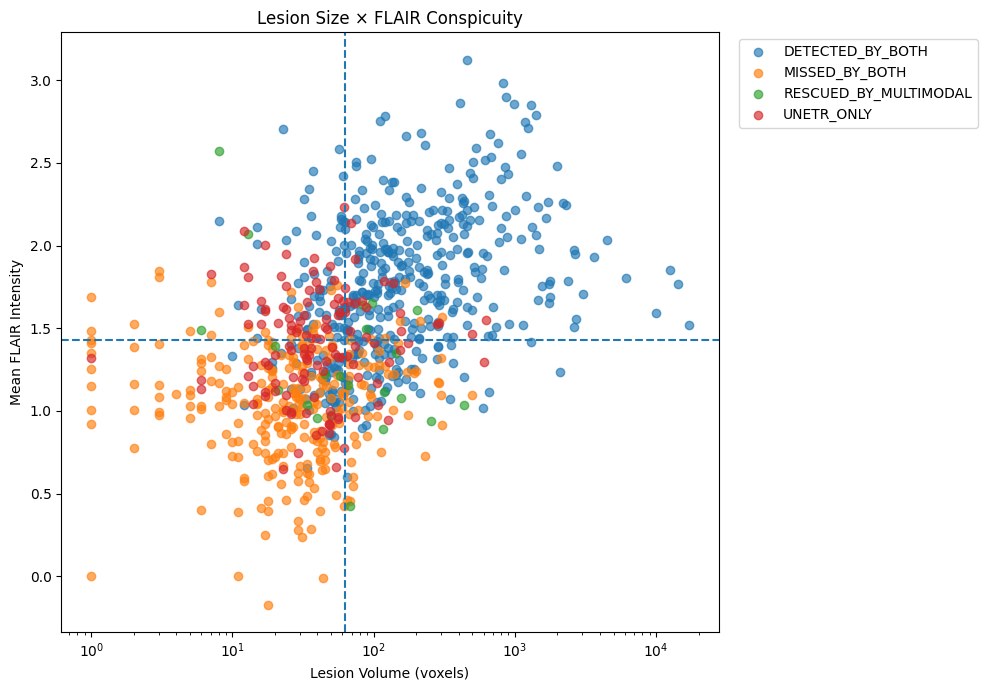

In [20]:
# ============================================================
# SCATTER:
# LESION SIZE × FLAIR CONSPICUITY
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)


for status, group in difficulty_df.groupby(
    "Status"
):

    ax.scatter(
        group["Lesion_Voxels"],
        group["FLAIR_Mean"],
        label=status,
        alpha=0.65
    )


ax.axvline(
    volume_median,
    linestyle="--"
)

ax.axhline(
    flair_median,
    linestyle="--"
)


ax.set_xscale(
    "log"
)


ax.set_xlabel(
    "Lesion Volume (voxels)"
)

ax.set_ylabel(
    "Mean FLAIR Intensity"
)

ax.set_title(
    "Lesion Size × FLAIR Conspicuity"
)

ax.legend(
    bbox_to_anchor=(
        1.02,
        1
    ),
    loc="upper left"
)

plt.tight_layout()

plt.show()

SMALL + LOW LESION ANALYSIS
Volume threshold: 63.0
FLAIR threshold: 1.4307479858398438

Total SMALL + LOW lesions: 312

STATUS COUNTS


,Number_of_Lesions
Status,
MISSED_BY_BOTH,200
UNETR_ONLY,53
DETECTED_BY_BOTH,52
RESCUED_BY_MULTIMODAL,7



SMALL + LOW — GROUP SUMMARY


,Group,N,Lesion_Voxels_Median,Lesion_Voxels_Mean,FLAIR_Mean_Median,FLAIR_Mean_Mean,FLAIR_P10_Median,T1_Mean_Median,T2_Mean_Median,UNETR_Recall_Mean,MM_Recall_Mean
0,RESCUED_BY_MULTIMODAL,7,40.0,38.285714,1.127484,1.131541,0.835398,0.547634,-0.285583,0.000000,0.287836
1,UNETR_ONLY,53,32.0,32.962264,1.168640,1.128720,0.809949,0.641614,-0.409695,0.303575,0.013415
2,MISSED_BY_BOTH,200,23.0,24.525000,1.010206,0.953304,0.712342,0.602387,-0.369885,0.004039,0.000683
3,DETECTED_BY_BOTH,52,47.5,43.788462,1.199946,1.168420,0.758855,0.645072,-0.358634,0.549199,0.461544



ALL SMALL + LOW LESIONS RESCUED BY MULTIMODAL


...

,Feature,Rescued_Median,Missed_Both_Median,Rescued_Mean,Missed_Both_Mean,U,p_value,Rank_Biserial
0,Lesion_Voxels,40.000000,23.000000,38.285714,24.525000,1051.0,0.024405,0.501429
2,FLAIR_Median,1.155874,1.006061,1.140282,0.942600,973.0,0.080241,0.390000
1,FLAIR_Mean,1.127484,1.010206,1.131541,0.953304,927.0,0.145947,0.324286
4,FLAIR_P90,1.454110,1.266785,1.403399,1.241766,924.0,0.151362,0.320000
3,FLAIR_P10,0.835398,0.712342,0.842426,0.672945,880.0,0.249204,0.257143
8,T2_Median,-0.284827,-0.376311,-0.143008,-0.227090,867.0,0.285146,0.238571
7,T2_Mean,-0.285583,-0.369885,-0.121639,-0.208593,860.0,0.305884,0.228571
5,T1_Mean,0.547634,0.602387,0.534824,0.441147,705.0,0.976954,0.007143
6,T1_Median,0.566484,0.603067,0.545732,0.451945,696.0,0.982075,-0.005714



RESCUED vs UNETR-ONLY


,Feature,Rescued_Median,UNETR_Only_Median,U,p_value,Rank_Biserial
4,FLAIR_P90,1.454110,1.565556,92.0,0.030024,-0.504043
8,T2_Median,-0.284827,-0.459051,267.0,0.061176,0.439353
7,T2_Mean,-0.285583,-0.409695,262.0,0.079987,0.412399
0,Lesion_Voxels,40.000000,32.000000,226.0,0.356693,0.218329
3,FLAIR_P10,0.835398,0.809949,214.0,0.527126,0.153639
5,T1_Mean,0.547634,0.641614,166.0,0.668319,-0.105121
6,T1_Median,0.566484,0.636577,172.0,0.769564,-0.072776
1,FLAIR_Mean,1.127484,1.168640,182.0,0.946134,-0.018868
2,FLAIR_Median,1.155874,1.169194,188.0,0.964075,0.013477



WITHIN SMALL + LOW — SIZE / FLAIR RELATIONSHIP
Lesion volume vs FLAIR mean:
Spearman rho = 0.0216
p-value = 0.704436


C:\Users\USER\AppData\Local\Temp\ipykernel_14980\1312044145.py:686: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


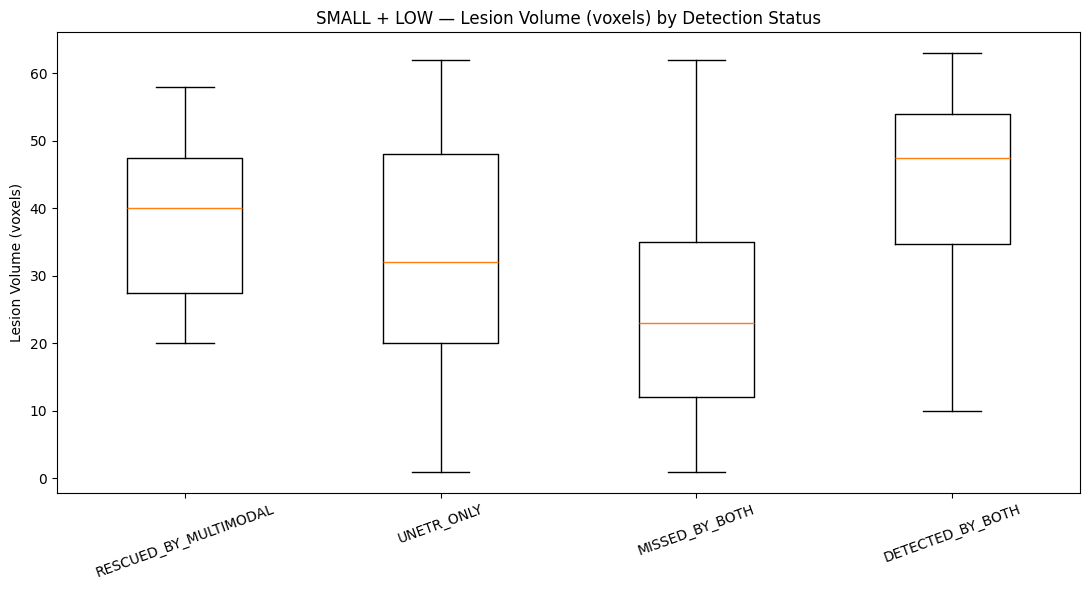

C:\Users\USER\AppData\Local\Temp\ipykernel_14980\1312044145.py:686: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


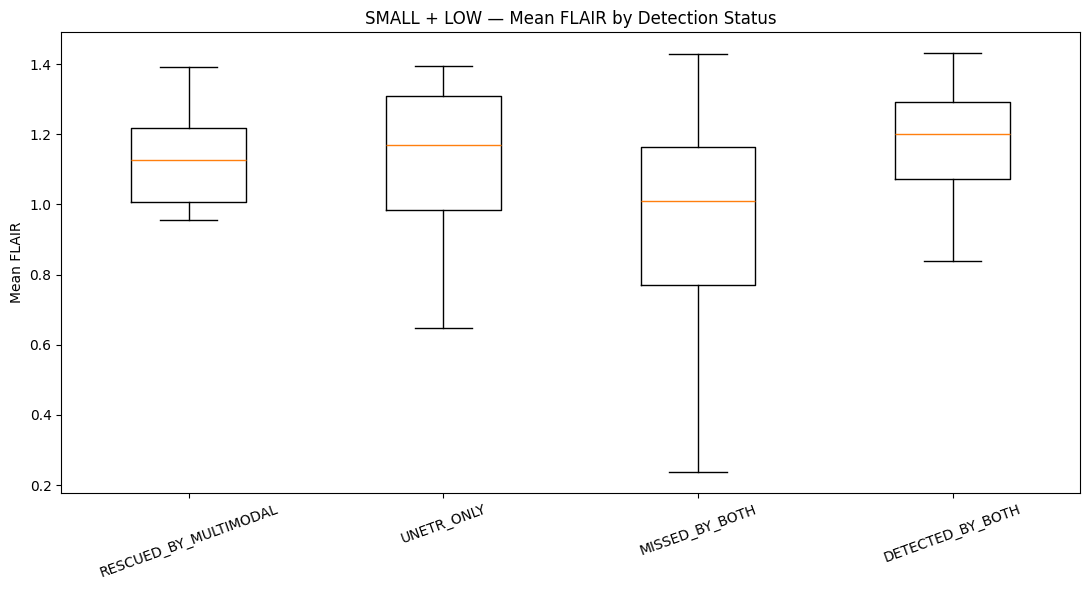

C:\Users\USER\AppData\Local\Temp\ipykernel_14980\1312044145.py:686: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


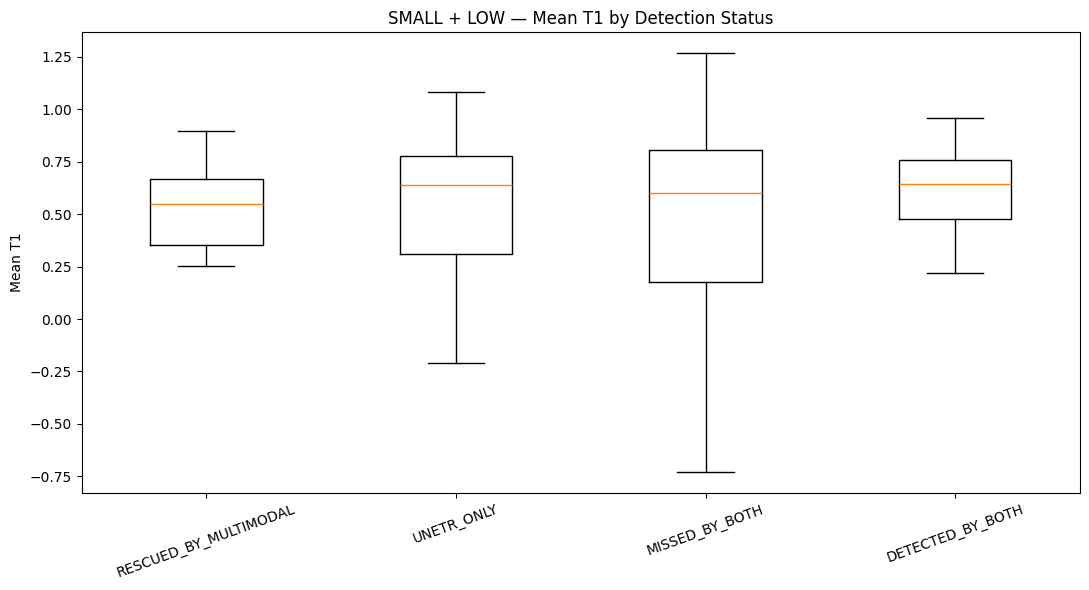

C:\Users\USER\AppData\Local\Temp\ipykernel_14980\1312044145.py:686: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


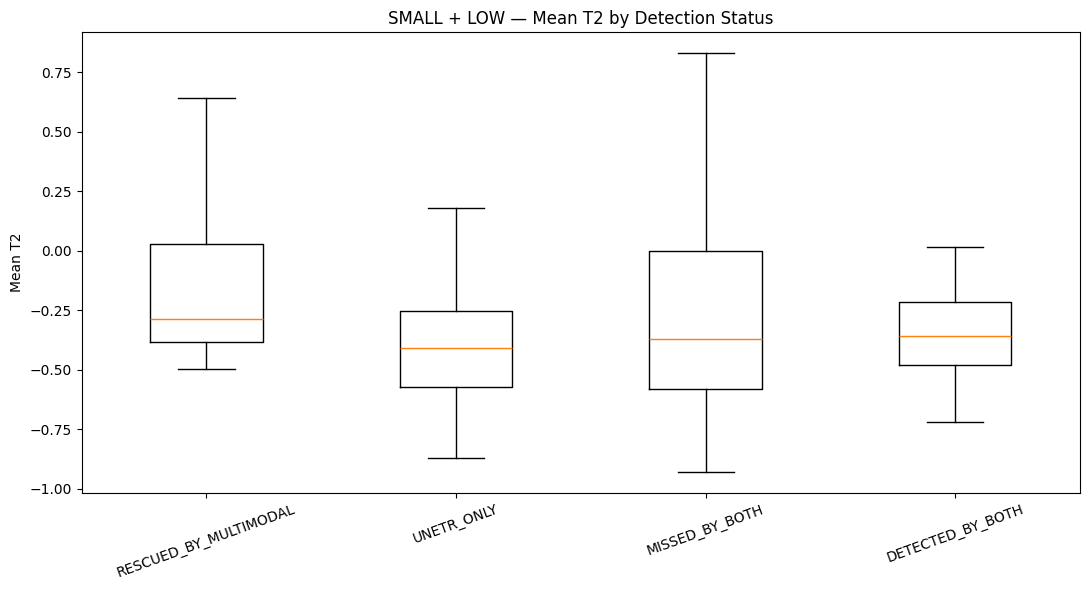

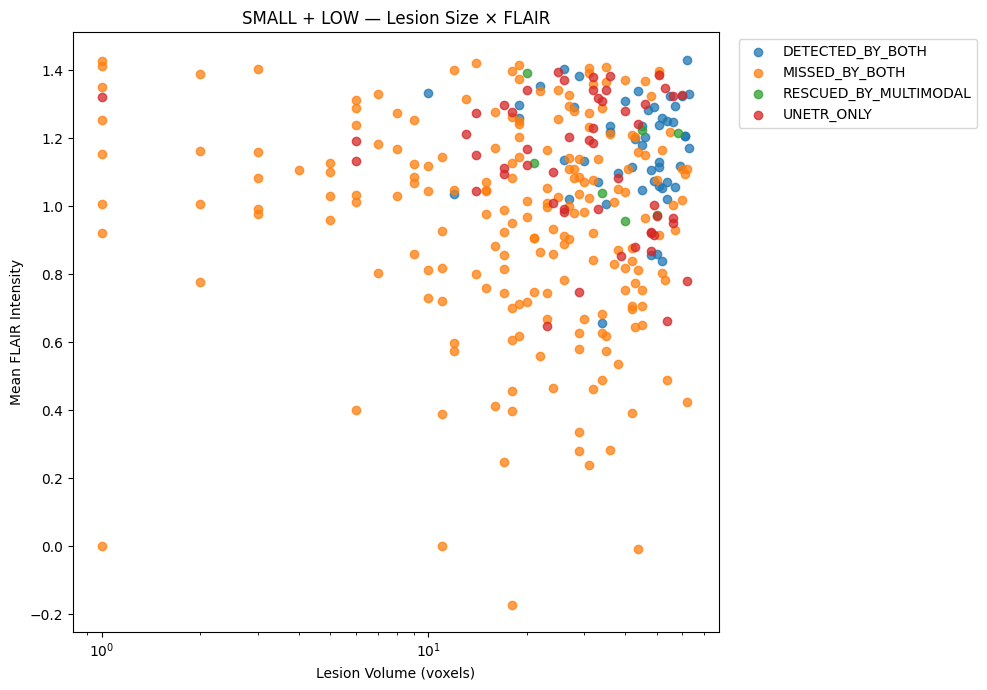


SMALL + LOW ANALYSIS COMPLETE
Total: 312
Rescued: 7
UNETR only: 53
Missed by both: 200
Detected by both: 52

Saved: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\small_low_lesion_analysis.csv


In [21]:
# ============================================================
# SMALL + LOW LESION DEEP ANALYSIS
#
# Population:
#   Lesion volume <= median volume
#   FLAIR mean <= median FLAIR
#
# Expected:
#   Total          = 312
#   Rescued       = 7
#   UNETR only    = 53
#   Missed both   = 200
#   Both detected = 52
#
# Main question:
#   What makes the 7 multimodal-rescued lesions different?
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    mannwhitneyu,
    spearmanr
)


# ============================================================
# 1. CHECK
# ============================================================

if "lesion_df" not in globals():
    raise NameError(
        "lesion_df is not available. "
        "Run the lesion-level analysis first."
    )


required_columns = [
    "Patient",
    "Lesion_ID",
    "Lesion_Voxels",
    "FLAIR_Mean",
    "FLAIR_Median",
    "FLAIR_P10",
    "FLAIR_P90",
    "T1_Mean",
    "T1_Median",
    "T2_Mean",
    "T2_Median",
    "UNETR_Recall",
    "MM_Recall",
    "Status"
]


missing_columns = [
    c for c in required_columns
    if c not in lesion_df.columns
]


if missing_columns:
    raise RuntimeError(
        "Missing columns:\n" +
        "\n".join(missing_columns)
    )


# ============================================================
# 2. DEFINE SMALL + LOW
# ============================================================

volume_median = lesion_df[
    "Lesion_Voxels"
].median()

flair_median = lesion_df[
    "FLAIR_Mean"
].median()


small_low_df = lesion_df[
    (
        lesion_df["Lesion_Voxels"]
        <= volume_median
    )
    &
    (
        lesion_df["FLAIR_Mean"]
        <= flair_median
    )
].copy()


# ============================================================
# 3. CHECK GROUP COUNTS
# ============================================================

print("=" * 100)
print("SMALL + LOW LESION ANALYSIS")
print("=" * 100)

print(
    "Volume threshold:",
    volume_median
)

print(
    "FLAIR threshold:",
    flair_median
)

print(
    "\nTotal SMALL + LOW lesions:",
    len(small_low_df)
)


print("\nSTATUS COUNTS")

display(
    small_low_df[
        "Status"
    ]
    .value_counts()
    .to_frame(
        "Number_of_Lesions"
    )
)


# ============================================================
# 4. CREATE FOUR SUBGROUPS
# ============================================================

groups = {

    "RESCUED_BY_MULTIMODAL":
        small_low_df[
            small_low_df["Status"]
            ==
            "RESCUED_BY_MULTIMODAL"
        ].copy(),

    "UNETR_ONLY":
        small_low_df[
            small_low_df["Status"]
            ==
            "UNETR_ONLY"
        ].copy(),

    "MISSED_BY_BOTH":
        small_low_df[
            small_low_df["Status"]
            ==
            "MISSED_BY_BOTH"
        ].copy(),

    "DETECTED_BY_BOTH":
        small_low_df[
            small_low_df["Status"]
            ==
            "DETECTED_BY_BOTH"
        ].copy()
}


# ============================================================
# 5. GROUP STATISTICS
# ============================================================

features = [

    "Lesion_Voxels",

    "FLAIR_Mean",
    "FLAIR_Median",
    "FLAIR_P10",
    "FLAIR_P90",

    "T1_Mean",
    "T1_Median",

    "T2_Mean",
    "T2_Median",

    "UNETR_Recall",
    "MM_Recall"
]


summary_rows = []


for group_name, group_df in groups.items():

    row = {
        "Group":
            group_name,

        "N":
            len(group_df)
    }


    for feature in features:

        if len(group_df) == 0:

            row[
                feature + "_Median"
            ] = np.nan

            row[
                feature + "_Mean"
            ] = np.nan

        else:

            row[
                feature + "_Median"
            ] = group_df[
                feature
            ].median()

            row[
                feature + "_Mean"
            ] = group_df[
                feature
            ].mean()


    summary_rows.append(row)


summary_df = pd.DataFrame(
    summary_rows
)


print("\n" + "=" * 100)
print("SMALL + LOW — GROUP SUMMARY")
print("=" * 100)

display(
    summary_df[
        [
            "Group",
            "N",

            "Lesion_Voxels_Median",
            "Lesion_Voxels_Mean",

            "FLAIR_Mean_Median",
            "FLAIR_Mean_Mean",

            "FLAIR_P10_Median",

            "T1_Mean_Median",
            "T2_Mean_Median",

            "UNETR_Recall_Mean",
            "MM_Recall_Mean"
        ]
    ]
)


# ============================================================
# 6. ALL 7 RESCUED LESIONS
# ============================================================

rescued_small_low = groups[
    "RESCUED_BY_MULTIMODAL"
]


print("\n" + "=" * 100)
print("ALL SMALL + LOW LESIONS RESCUED BY MULTIMODAL")
print("=" * 100)

if len(rescued_small_low) == 0:

    print(
        "No rescued lesions found."
    )

else:

    display(
        rescued_small_low[
            [
                "Patient",
                "Lesion_ID",

                "Lesion_Voxels",

                "FLAIR_Mean",
                "FLAIR_Median",
                "FLAIR_P10",
                "FLAIR_P90",

                "T1_Mean",
                "T1_Median",

                "T2_Mean",
                "T2_Median",

                "UNETR_Recall",
                "MM_Recall",

                "Recall_Improvement_MM_minus_UNETR"
            ]
        ]
        .sort_values(
            [
                "Lesion_Voxels",
                "FLAIR_Mean"
            ]
        )
        .reset_index(drop=True)
    )


# ============================================================
# 7. MISSED-BY-BOTH — SMALLEST / LOWEST FLAIR
# ============================================================

missed_small_low = groups[
    "MISSED_BY_BOTH"
]


print("\n" + "=" * 100)
print("SMALL + LOW — SMALLEST LESIONS MISSED BY BOTH")
print("=" * 100)

display(
    missed_small_low[
        [
            "Patient",
            "Lesion_ID",

            "Lesion_Voxels",

            "FLAIR_Mean",
            "FLAIR_Median",
            "FLAIR_P10",
            "FLAIR_P90",

            "T1_Mean",
            "T2_Mean"
        ]
    ]
    .sort_values(
        [
            "Lesion_Voxels",
            "FLAIR_Mean"
        ]
    )
    .head(50)
)


# ============================================================
# 8. RESCUED vs MISSED-BY-BOTH
# ============================================================

print("\n" + "=" * 100)
print("RESCUED vs MISSED-BY-BOTH")
print("=" * 100)


comparison_features = [

    "Lesion_Voxels",
    "FLAIR_Mean",
    "FLAIR_Median",
    "FLAIR_P10",
    "FLAIR_P90",
    "T1_Mean",
    "T1_Median",
    "T2_Mean",
    "T2_Median"
]


comparison_rows = []


for feature in comparison_features:

    x = rescued_small_low[
        feature
    ].dropna().to_numpy()

    y = missed_small_low[
        feature
    ].dropna().to_numpy()


    if (
        len(x) >= 2
        and
        len(y) >= 2
    ):

        u, p = mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )

        n1 = len(x)
        n2 = len(y)

        # Rank-biserial effect size
        effect = (
            2.0 * u
            /
            (n1 * n2)
            - 1.0
        )

    else:

        u = np.nan
        p = np.nan
        effect = np.nan


    comparison_rows.append({

        "Feature":
            feature,

        "Rescued_Median":
            np.median(x)
            if len(x)
            else np.nan,

        "Missed_Both_Median":
            np.median(y)
            if len(y)
            else np.nan,

        "Rescued_Mean":
            np.mean(x)
            if len(x)
            else np.nan,

        "Missed_Both_Mean":
            np.mean(y)
            if len(y)
            else np.nan,

        "U":
            u,

        "p_value":
            p,

        "Rank_Biserial":
            effect
    })


rescued_vs_missed_df = pd.DataFrame(
    comparison_rows
)


display(
    rescued_vs_missed_df
    .sort_values(
        "p_value",
        na_position="last"
    )
)


# ============================================================
# 9. RESCUED vs UNETR-ONLY
# ============================================================

print("\n" + "=" * 100)
print("RESCUED vs UNETR-ONLY")
print("=" * 100)


unetr_only_small_low = groups[
    "UNETR_ONLY"
]


rows = []


for feature in comparison_features:

    x = rescued_small_low[
        feature
    ].dropna().to_numpy()

    y = unetr_only_small_low[
        feature
    ].dropna().to_numpy()


    if (
        len(x) >= 2
        and
        len(y) >= 2
    ):

        u, p = mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )

        effect = (
            2.0 * u
            /
            (
                len(x)
                *
                len(y)
            )
            - 1.0
        )

    else:

        u = np.nan
        p = np.nan
        effect = np.nan


    rows.append({

        "Feature":
            feature,

        "Rescued_Median":
            np.median(x)
            if len(x)
            else np.nan,

        "UNETR_Only_Median":
            np.median(y)
            if len(y)
            else np.nan,

        "U":
            u,

        "p_value":
            p,

        "Rank_Biserial":
            effect
    })


rescued_vs_unetr_df = pd.DataFrame(
    rows
)


display(
    rescued_vs_unetr_df
    .sort_values(
        "p_value",
        na_position="last"
    )
)


# ============================================================
# 10. FLAIR vs VOLUME WITHIN SMALL + LOW
# ============================================================

print("\n" + "=" * 100)
print("WITHIN SMALL + LOW — SIZE / FLAIR RELATIONSHIP")
print("=" * 100)


rho_flair_volume, p_flair_volume = (
    spearmanr(
        small_low_df[
            "Lesion_Voxels"
        ],
        small_low_df[
            "FLAIR_Mean"
        ]
    )
)


print(
    "Lesion volume vs FLAIR mean:"
)

print(
    f"Spearman rho = "
    f"{rho_flair_volume:.4f}"
)

print(
    f"p-value = "
    f"{p_flair_volume:.6g}"
)


# ============================================================
# 11. VISUALIZATION — GROUPED BOXPLOTS
# ============================================================

plot_features = [

    (
        "Lesion_Voxels",
        "Lesion Volume (voxels)"
    ),

    (
        "FLAIR_Mean",
        "Mean FLAIR"
    ),

    (
        "T1_Mean",
        "Mean T1"
    ),

    (
        "T2_Mean",
        "Mean T2"
    )
]


plot_groups = [
    "RESCUED_BY_MULTIMODAL",
    "UNETR_ONLY",
    "MISSED_BY_BOTH",
    "DETECTED_BY_BOTH"
]


for feature, ylabel in plot_features:

    data_to_plot = []

    labels = []


    for group_name in plot_groups:

        values = groups[
            group_name
        ][
            feature
        ].dropna().to_numpy()


        if len(values) > 0:

            data_to_plot.append(
                values
            )

            labels.append(
                group_name
            )


    fig, ax = plt.subplots(
        figsize=(11, 6)
    )


    ax.boxplot(
        data_to_plot,
        labels=labels,
        showfliers=False
    )


    ax.set_ylabel(
        ylabel
    )

    ax.set_title(
        "SMALL + LOW — "
        + ylabel
        + " by Detection Status"
    )


    ax.tick_params(
        axis="x",
        rotation=20
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 12. FLAIR vs LESION SIZE — SMALL + LOW ONLY
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)


for status, group_df in (
    small_low_df.groupby("Status")
):

    ax.scatter(
        group_df[
            "Lesion_Voxels"
        ],
        group_df[
            "FLAIR_Mean"
        ],
        label=status,
        alpha=0.75
    )


ax.set_xscale(
    "log"
)


ax.set_xlabel(
    "Lesion Volume (voxels)"
)

ax.set_ylabel(
    "Mean FLAIR Intensity"
)

ax.set_title(
    "SMALL + LOW — Lesion Size × FLAIR"
)

ax.legend(
    bbox_to_anchor=(
        1.02,
        1
    ),
    loc="upper left"
)

plt.tight_layout()

plt.show()


# ============================================================
# 13. SAVE SUBGROUP
# ============================================================

OUTPUT_PATH = os.path.join(
    DATASET_ROOT,
    "small_low_lesion_analysis.csv"
)

small_low_df.to_csv(
    OUTPUT_PATH,
    index=False
)


# ============================================================
# 14. FINAL
# ============================================================

print("\n" + "=" * 100)
print("SMALL + LOW ANALYSIS COMPLETE")
print("=" * 100)

print(
    "Total:",
    len(small_low_df)
)

print(
    "Rescued:",
    len(rescued_small_low)
)

print(
    "UNETR only:",
    len(unetr_only_small_low)
)

print(
    "Missed by both:",
    len(missed_small_low)
)

print(
    "Detected by both:",
    len(groups["DETECTED_BY_BOTH"])
)

print(
    "\nSaved:",
    OUTPUT_PATH
)

print("=" * 100)

In [22]:
# ============================================================
# DEEP HARD-LESION ANALYSIS
#
# TARGET:
#   SMALL + LOW lesions
#
# MAIN QUESTIONS:
#
#   1. Does the model predict only the brightest part
#      of a lesion?
#
#   2. Are rescued lesions locally more conspicuous
#      than missed-by-both lesions?
#
#   3. Do T1/T2 provide complementary local contrast?
#
#   4. Does lesion shape / size contribute to failure?
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import matplotlib.pyplot as plt

from scipy import ndimage
from monai.networks.nets import UNETR, UNet
from monai.inferers import sliding_window_inference


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 100)
print("DEEP SMALL + LOW LESION ANALYSIS")
print("=" * 100)

print(
    "Device:",
    device
)


# ============================================================
# 3. PATHS
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)

TEST_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed",
    "test"
)

EXP5_MODEL = os.path.join(
    DATASET_ROOT,
    "Experiment_5_3D_UNet",
    "best_model_exp5.pth"
)

EXP6_MODEL = os.path.join(
    DATASET_ROOT,
    "Experiment_6_UNETR_FLAIR",
    "best_model_unetr_flair.pth"
)


# ============================================================
# 4. SMALL + LOW THRESHOLDS
#
# These are the median thresholds obtained earlier.
# ============================================================

VOLUME_THRESHOLD = 63.0

FLAIR_THRESHOLD = 1.4307479858


print(
    "\nSmall lesion threshold:",
    VOLUME_THRESHOLD,
    "voxels"
)

print(
    "Low FLAIR threshold:",
    FLAIR_THRESHOLD
)


# ============================================================
# 5. LOAD MODELS
# ============================================================

print("\n" + "=" * 100)
print("LOADING MODELS")
print("=" * 100)


# ------------------------------------------------------------
# Experiment 6 — FLAIR-only UNETR
# ------------------------------------------------------------

model_unetr = UNETR(

    in_channels=1,

    out_channels=1,

    img_size=(
        144,
        144,
        144
    ),

    feature_size=16,

    hidden_size=768,

    mlp_dim=3072,

    num_heads=12,

    proj_type="conv",

    norm_name="instance",

    res_block=True,

    dropout_rate=0.0
).to(device)


unetr_state = torch.load(
    EXP6_MODEL,
    map_location=device,
    weights_only=True
)

model_unetr.load_state_dict(
    unetr_state
)

model_unetr.eval()


# ------------------------------------------------------------
# Experiment 5 — FLAIR + T1 + T2 3D U-Net
# ------------------------------------------------------------

model_mm = UNet(

    spatial_dims=3,

    in_channels=3,

    out_channels=1,

    channels=(
        16,
        32,
        64,
        128,
        256
    ),

    strides=(
        2,
        2,
        2,
        2
    ),

    num_res_units=2,

    act="PRELU",

    norm="INSTANCE",

    dropout=0.0
).to(device)


mm_state = torch.load(
    EXP5_MODEL,
    map_location=device,
    weights_only=True
)

model_mm.load_state_dict(
    mm_state
)

model_mm.eval()


print("✓ UNETR loaded")
print("✓ Multimodal 3D U-Net loaded")


# ============================================================
# 6. SMALL + LOW LESION RESULTS
# ============================================================

if "lesion_df" not in globals():

    raise NameError(
        "lesion_df is not available."
    )


small_low_df = lesion_df[
    (
        lesion_df["Lesion_Voxels"]
        <= VOLUME_THRESHOLD
    )
    &
    (
        lesion_df["FLAIR_Mean"]
        <= FLAIR_THRESHOLD
    )
].copy()


print("\n")
print(
    "SMALL + LOW lesions:",
    len(small_low_df)
)

print(
    "\nStatus counts:"
)

display(
    small_low_df[
        "Status"
    ]
    .value_counts()
    .to_frame(
        "Number_of_Lesions"
    )
)


# ============================================================
# 7. GROUP LABELS
# ============================================================

target_statuses = [
    "RESCUED_BY_MULTIMODAL",
    "MISSED_BY_BOTH",
    "UNETR_ONLY",
    "DETECTED_BY_BOTH"
]


# ============================================================
# 8. 3D CONNECTIVITY
#
# Keep SAME connectivity used previously.
# ============================================================

structure = (
    ndimage.generate_binary_structure(
        3,
        3
    )
)


# ============================================================
# 9. STORAGE
# ============================================================

deep_results = []


# ============================================================
# 10. PROCESS EACH PATIENT
# ============================================================

patients = sorted(
    small_low_df[
        "Patient"
    ].unique(),

    key=lambda x:
        int(x[1:])
        if (
            x.startswith("P")
            and
            x[1:].isdigit()
        )
        else x
)


print("\n" + "=" * 100)
print("PATIENT-WISE DEEP ANALYSIS")
print("=" * 100)


for patient_index, patient in enumerate(
    patients,
    start=1
):

    print(
        f"\n{patient_index}/"
        f"{len(patients)} — {patient}"
    )


    patient_root = os.path.join(
        TEST_ROOT,
        patient
    )


    # ========================================================
    # PATHS
    # ========================================================

    flair_path = os.path.join(
        patient_root,
        f"{patient}_FLAIR_N4_Z.nii.gz"
    )

    t1_path = os.path.join(
        patient_root,
        f"{patient}_T1_N4_Z.nii.gz"
    )

    t2_path = os.path.join(
        patient_root,
        f"{patient}_T2_N4_Z.nii.gz"
    )

    mask_path = os.path.join(
        patient_root,
        f"{patient}_MASK.nii.gz"
    )


    # ========================================================
    # LOAD
    # ========================================================

    flair = nib.load(
        flair_path
    ).get_fdata(
        dtype=np.float32
    )

    t1 = nib.load(
        t1_path
    ).get_fdata(
        dtype=np.float32
    )

    t2 = nib.load(
        t2_path
    ).get_fdata(
        dtype=np.float32
    )

    gt = (
        nib.load(
            mask_path
        ).get_fdata(
            dtype=np.float32
        )
        > 0
    )


    # ========================================================
    # MODEL INPUTS
    # ========================================================

    flair_tensor = torch.from_numpy(
        flair
    ).float()


    mm_tensor = torch.from_numpy(
        np.stack(
            [
                flair,
                t1,
                t2
            ],
            axis=0
        )
    ).float()


    # ========================================================
    # UNETR INFERENCE
    # ========================================================

    flair_gpu = (
        flair_tensor
        .unsqueeze(0)
        .unsqueeze(0)
        .to(
            device,
            non_blocking=True
        )
    )


    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            output_unetr = (
                sliding_window_inference(

                    inputs=flair_gpu,

                    roi_size=(
                        144,
                        144,
                        144
                    ),

                    sw_batch_size=1,

                    predictor=model_unetr,

                    overlap=0.5
                )
            )


    pred_unetr = (
        torch.sigmoid(
            output_unetr
        )
        > 0.5
    ).squeeze().cpu().numpy()


    del flair_gpu
    del output_unetr


    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    # ========================================================
    # MULTIMODAL INFERENCE
    # ========================================================

    mm_gpu = (
        mm_tensor
        .unsqueeze(0)
        .to(
            device,
            non_blocking=True
        )
    )


    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            output_mm = (
                sliding_window_inference(

                    inputs=mm_gpu,

                    roi_size=(
                        144,
                        144,
                        144
                    ),

                    sw_batch_size=1,

                    predictor=model_mm,

                    overlap=0.5
                )
            )


    pred_mm = (
        torch.sigmoid(
            output_mm
        )
        > 0.5
    ).squeeze().cpu().numpy()


    del mm_gpu
    del output_mm


    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    # ========================================================
    # CONNECTED COMPONENTS
    # ========================================================

    labeled_gt, num_components = (
        ndimage.label(
            gt,
            structure=structure
        )
    )


    # ========================================================
    # LOOP THROUGH RELEVANT LESIONS
    # ========================================================

    target_lesions_patient = (
        small_low_df[
            small_low_df["Patient"]
            ==
            patient
        ]
    )


    for _, target_row in (
        target_lesions_patient.iterrows()
    ):

        lesion_id = int(
            target_row[
                "Lesion_ID"
            ]
        )


        lesion = (
            labeled_gt
            ==
            lesion_id
        )


        if lesion.sum() == 0:
            continue


        lesion_volume = int(
            lesion.sum()
        )


        # ====================================================
        # 11. BASIC LESION INTENSITIES
        # ====================================================

        flair_values = flair[
            lesion
        ]

        t1_values = t1[
            lesion
        ]

        t2_values = t2[
            lesion
        ]


        # ====================================================
        # 12. LOCAL BACKGROUND SHELL
        #
        # Dilate lesion by 2 voxels.
        #
        # Remove ALL GT lesion voxels from shell.
        # ====================================================

        dilated_2 = ndimage.binary_dilation(
            lesion,
            structure=structure,
            iterations=2
        )


        shell_2 = (
            dilated_2
            &
            ~gt
        )


        shell_2_values_flair = (
            flair[
                shell_2
            ]
        )

        shell_2_values_t1 = (
            t1[
                shell_2
            ]
        )

        shell_2_values_t2 = (
            t2[
                shell_2
            ]
        )


        # ====================================================
        # 13. LOCAL CONTRAST FUNCTION
        # ====================================================

        def local_contrast(
            lesion_values,
            shell_values
        ):

            if (
                len(shell_values) == 0
            ):

                return (
                    np.nan,
                    np.nan,
                    np.nan
                )


            lesion_mean = float(
                np.mean(
                    lesion_values
                )
            )

            shell_mean = float(
                np.mean(
                    shell_values
                )
            )

            shell_std = float(
                np.std(
                    shell_values
                )
            )


            difference = (
                lesion_mean
                -
                shell_mean
            )


            standardized = (

                difference
                /
                shell_std

                if shell_std > 0

                else 0.0
            )


            return (
                lesion_mean,
                shell_mean,
                standardized
            )


        (
            flair_lesion_mean,
            flair_shell_mean,
            flair_local_z
        ) = local_contrast(
            flair_values,
            shell_2_values_flair
        )


        (
            t1_lesion_mean,
            t1_shell_mean,
            t1_local_z
        ) = local_contrast(
            t1_values,
            shell_2_values_t1
        )


        (
            t2_lesion_mean,
            t2_shell_mean,
            t2_local_z
        ) = local_contrast(
            t2_values,
            shell_2_values_t2
        )


        # ====================================================
        # 14. LESION RECALL
        # ====================================================

        unetr_tp = int(
            np.logical_and(
                lesion,
                pred_unetr
            ).sum()
        )

        mm_tp = int(
            np.logical_and(
                lesion,
                pred_mm
            ).sum()
        )


        unetr_recall = (
            unetr_tp
            /
            lesion_volume
        )

        mm_recall = (
            mm_tp
            /
            lesion_volume
        )


        # ====================================================
        # 15. BRIGHTNESS DECILE ANALYSIS
        #
        # Sort lesion voxels by FLAIR intensity.
        #
        # For each 10% of the lesion:
        #   What fraction was predicted?
        #
        # This directly tests:
        #
        #   "Does model predict only the brightest part?"
        # ====================================================

        lesion_coordinates = np.argwhere(
            lesion
        )


        lesion_flair_values = flair[
            lesion
        ]


        # ----------------------------------------------------
        # Sort from darkest to brightest
        # ----------------------------------------------------

        sorted_indices = np.argsort(
            lesion_flair_values
        )


        decile_recalls_unetr = []
        decile_recalls_mm = []


        n_voxels = len(
            sorted_indices
        )


        for decile in range(10):

            start = int(
                decile
                *
                n_voxels
                /
                10
            )

            end = int(
                (
                    decile + 1
                )
                *
                n_voxels
                /
                10
            )


            if end <= start:
                continue


            selected = (
                sorted_indices[
                    start:end
                ]
            )


            coords = (
                lesion_coordinates[
                    selected
                ]
            )


            # ------------------------------------------------
            # Determine whether each voxel belongs to
            # prediction mask
            # ------------------------------------------------

            pred_values_unetr = (
                pred_unetr[
                    coords[:, 0],
                    coords[:, 1],
                    coords[:, 2]
                ]
            )


            pred_values_mm = (
                pred_mm[
                    coords[:, 0],
                    coords[:, 1],
                    coords[:, 2]
                ]
            )


            decile_recalls_unetr.append(
                float(
                    pred_values_unetr.mean()
                )
            )

            decile_recalls_mm.append(
                float(
                    pred_values_mm.mean()
                )
            )


        # ====================================================
        # 16. BRIGHTNESS GRADIENT
        #
        # Difference between:
        #   brightest 10%
        #   darkest 10%
        #
        # Large positive value =
        # model preferentially predicts bright portion.
        # ====================================================

        if (
            len(decile_recalls_unetr)
            == 10
        ):

            unetr_darkest10 = (
                decile_recalls_unetr[0]
            )

            unetr_brightest10 = (
                decile_recalls_unetr[-1]
            )

            mm_darkest10 = (
                decile_recalls_mm[0]
            )

            mm_brightest10 = (
                decile_recalls_mm[-1]
            )


            unetr_brightness_bias = (
                unetr_brightest10
                -
                unetr_darkest10
            )

            mm_brightness_bias = (
                mm_brightest10
                -
                mm_darkest10
            )

        else:

            unetr_darkest10 = np.nan
            unetr_brightest10 = np.nan

            mm_darkest10 = np.nan
            mm_brightest10 = np.nan

            unetr_brightness_bias = np.nan
            mm_brightness_bias = np.nan


        # ====================================================
        # 17. SHAPE FEATURES
        # ====================================================

        # Bounding box
        coords = np.argwhere(
            lesion
        )


        if len(coords) > 0:

            min_coords = (
                coords.min(
                    axis=0
                )
            )

            max_coords = (
                coords.max(
                    axis=0
                )
            )

            bbox_size = (
                max_coords
                -
                min_coords
                +
                1
            )

            bbox_volume = int(
                np.prod(
                    bbox_size
                )
            )

        else:

            bbox_size = [
                np.nan,
                np.nan,
                np.nan
            ]

            bbox_volume = np.nan


        # ----------------------------------------------------
        # Approximate surface using erosion
        # ----------------------------------------------------

        eroded = ndimage.binary_erosion(
            lesion,
            structure=structure,
            iterations=1,
            border_value=0
        )


        surface_voxels = int(
            (
                lesion
                &
                ~eroded
            ).sum()
        )


        surface_to_volume = (

            surface_voxels
            /
            lesion_volume

            if lesion_volume > 0

            else np.nan
        )


        # ====================================================
        # 18. SAVE
        # ====================================================

        deep_results.append({

            "Patient":
                patient,

            "Lesion_ID":
                lesion_id,

            "Status":
                target_row[
                    "Status"
                ],


            # ------------------------------------------------
            # SIZE
            # ------------------------------------------------

            "Lesion_Volume":
                lesion_volume,

            "BBox_X":
                bbox_size[0],

            "BBox_Y":
                bbox_size[1],

            "BBox_Z":
                bbox_size[2],

            "BBox_Volume":
                bbox_volume,

            "Surface_Voxels":
                surface_voxels,

            "Surface_to_Volume":
                surface_to_volume,


            # ------------------------------------------------
            # FLAIR LOCAL CONTRAST
            # ------------------------------------------------

            "FLAIR_Lesion_Mean":
                flair_lesion_mean,

            "FLAIR_Local_Background_Mean":
                flair_shell_mean,

            "FLAIR_Local_Z":
                flair_local_z,


            # ------------------------------------------------
            # T1 LOCAL CONTRAST
            # ------------------------------------------------

            "T1_Lesion_Mean":
                t1_lesion_mean,

            "T1_Local_Background_Mean":
                t1_shell_mean,

            "T1_Local_Z":
                t1_local_z,


            # ------------------------------------------------
            # T2 LOCAL CONTRAST
            # ------------------------------------------------

            "T2_Lesion_Mean":
                t2_lesion_mean,

            "T2_Local_Background_Mean":
                t2_shell_mean,

            "T2_Local_Z":
                t2_local_z,


            # ------------------------------------------------
            # MODEL RECALL
            # ------------------------------------------------

            "UNETR_Recall":
                unetr_recall,

            "MM_Recall":
                mm_recall,

            "Recall_Improvement":
                mm_recall
                -
                unetr_recall,


            # ------------------------------------------------
            # BRIGHTNESS BIAS
            # ------------------------------------------------

            "UNETR_Darkest10_Recall":
                unetr_darkest10,

            "UNETR_Brightest10_Recall":
                unetr_brightest10,

            "UNETR_Brightness_Bias":
                unetr_brightness_bias,


            "MM_Darkest10_Recall":
                mm_darkest10,

            "MM_Brightest10_Recall":
                mm_brightest10,

            "MM_Brightness_Bias":
                mm_brightness_bias
        })


    # ========================================================
    # CLEAN
    # ========================================================

    del flair
    del t1
    del t2
    del gt

    del flair_tensor
    del mm_tensor

    del pred_unetr
    del pred_mm

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()


# ============================================================
# 19. DATAFRAME
# ============================================================

deep_df = pd.DataFrame(
    deep_results
)


print("\n" + "=" * 110)
print("DEEP ANALYSIS COMPLETE")
print("=" * 110)

print(
    "Lesions analyzed:",
    len(deep_df)
)


# ============================================================
# 20. GROUP SUMMARY
# ============================================================

group_summary = (

    deep_df

    .groupby(
        "Status"
    )

    .agg(

        N=(
            "Lesion_ID",
            "count"
        ),

        Median_Volume=(
            "Lesion_Volume",
            "median"
        ),

        Median_FLAIR_Local_Z=(
            "FLAIR_Local_Z",
            "median"
        ),

        Median_T1_Local_Z=(
            "T1_Local_Z",
            "median"
        ),

        Median_T2_Local_Z=(
            "T2_Local_Z",
            "median"
        ),

        Mean_UNETR_Recall=(
            "UNETR_Recall",
            "mean"
        ),

        Mean_MM_Recall=(
            "MM_Recall",
            "mean"
        ),

        Mean_UNETR_Brightness_Bias=(
            "UNETR_Brightness_Bias",
            "mean"
        ),

        Mean_MM_Brightness_Bias=(
            "MM_Brightness_Bias",
            "mean"
        ),

        Median_Surface_to_Volume=(
            "Surface_to_Volume",
            "median"
        )
    )

    .reset_index()
)


print("\n" + "=" * 110)
print("SMALL + LOW — DEEP GROUP SUMMARY")
print("=" * 110)

display(
    group_summary
)


# ============================================================
# 21. MOST IMPORTANT:
# BRIGHTNESS-BASED PREDICTION BIAS
# ============================================================

print("\n" + "=" * 110)
print("BRIGHTNESS BIAS — DOES THE MODEL PREDICT ONLY BRIGHT PARTS?")
print("=" * 110)


display(
    deep_df[
        [
            "Patient",
            "Lesion_ID",
            "Status",
            "Lesion_Volume",

            "FLAIR_Lesion_Mean",
            "FLAIR_Local_Z",

            "UNETR_Darkest10_Recall",
            "UNETR_Brightest10_Recall",
            "UNETR_Brightness_Bias",

            "MM_Darkest10_Recall",
            "MM_Brightest10_Recall",
            "MM_Brightness_Bias"
        ]
    ]
    .sort_values(
        "UNETR_Brightness_Bias",
        ascending=False
    )
)


# ============================================================
# 22. RESCUED LESIONS
# ============================================================

rescued_deep = deep_df[
    deep_df["Status"]
    ==
    "RESCUED_BY_MULTIMODAL"
].copy()


print("\n" + "=" * 110)
print("SMALL + LOW — MULTIMODAL RESCUED")
print("=" * 110)

display(
    rescued_deep[
        [
            "Patient",
            "Lesion_ID",
            "Lesion_Volume",

            "FLAIR_Lesion_Mean",
            "FLAIR_Local_Z",

            "T1_Lesion_Mean",
            "T1_Local_Z",

            "T2_Lesion_Mean",
            "T2_Local_Z",

            "UNETR_Recall",
            "MM_Recall",
            "Recall_Improvement",

            "UNETR_Brightest10_Recall",
            "UNETR_Darkest10_Recall",
            "UNETR_Brightness_Bias",

            "MM_Brightest10_Recall",
            "MM_Darkest10_Recall",
            "MM_Brightness_Bias"
        ]
    ]
    .sort_values(
        "Recall_Improvement",
        ascending=False
    )
)


# ============================================================
# 23. MISSED BY BOTH
# ============================================================

missed_deep = deep_df[
    deep_df["Status"]
    ==
    "MISSED_BY_BOTH"
].copy()


print("\n" + "=" * 110)
print("SMALL + LOW — MISSED BY BOTH")
print("=" * 110)

display(
    missed_deep[
        [
            "Patient",
            "Lesion_ID",
            "Lesion_Volume",

            "FLAIR_Lesion_Mean",
            "FLAIR_Local_Z",

            "T1_Lesion_Mean",
            "T1_Local_Z",

            "T2_Lesion_Mean",
            "T2_Local_Z",

            "UNETR_Recall",
            "MM_Recall",

            "UNETR_Brightness_Bias",
            "MM_Brightness_Bias",

            "Surface_to_Volume"
        ]
    ]
    .sort_values(
        [
            "Lesion_Volume",
            "FLAIR_Local_Z"
        ]
    )
    .head(100)
)


# ============================================================
# 24. CORRELATIONS
# ============================================================

from scipy.stats import spearmanr


def correlation_print(
    x,
    y,
    name_x,
    name_y
):

    valid = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x = np.asarray(x)[valid]
    y = np.asarray(y)[valid]


    if len(x) < 3:
        return


    rho, p = spearmanr(
        x,
        y
    )


    print(
        f"{name_x} vs {name_y}: "
        f"rho={rho:.4f}, "
        f"p={p:.6g}"
    )


print("\n" + "=" * 110)
print("BRIGHTNESS BIAS CORRELATIONS")
print("=" * 110)


correlation_print(
    deep_df["FLAIR_Local_Z"],
    deep_df["UNETR_Recall"],
    "FLAIR local contrast",
    "UNETR recall"
)


correlation_print(
    deep_df["FLAIR_Local_Z"],
    deep_df["MM_Recall"],
    "FLAIR local contrast",
    "MM recall"
)


correlation_print(
    deep_df["FLAIR_Local_Z"],
    deep_df[
        "Recall_Improvement"
    ],
    "FLAIR local contrast",
    "MM recall improvement"
)


correlation_print(
    deep_df["T1_Local_Z"],
    deep_df[
        "Recall_Improvement"
    ],
    "T1 local contrast",
    "MM recall improvement"
)


correlation_print(
    deep_df["T2_Local_Z"],
    deep_df[
        "Recall_Improvement"
    ],
    "T2 local contrast",
    "MM recall improvement"
)


correlation_print(
    deep_df["Lesion_Volume"],
    deep_df["UNETR_Recall"],
    "Lesion volume",
    "UNETR recall"
)


correlation_print(
    deep_df["Surface_to_Volume"],
    deep_df["UNETR_Recall"],
    "Surface/volume",
    "UNETR recall"
)


# ============================================================
# 25. DOES UNETR PREFER BRIGHT VOXELS?
# ============================================================

print("\n" + "=" * 110)
print("UNETR BRIGHTNESS BIAS")
print("=" * 110)


print(
    "Mean darkest 10% recall:",
    deep_df[
        "UNETR_Darkest10_Recall"
    ].mean()
)

print(
    "Mean brightest 10% recall:",
    deep_df[
        "UNETR_Brightest10_Recall"
    ].mean()
)

print(
    "Mean brightness bias:",
    deep_df[
        "UNETR_Brightness_Bias"
    ].mean()
)


# ============================================================
# 26. DOES MULTIMODAL MODEL PREFER BRIGHT VOXELS?
# ============================================================

print("\n" + "=" * 110)
print("MULTIMODAL BRIGHTNESS BIAS")
print("=" * 110)


print(
    "Mean darkest 10% recall:",
    deep_df[
        "MM_Darkest10_Recall"
    ].mean()
)

print(
    "Mean brightest 10% recall:",
    deep_df[
        "MM_Brightest10_Recall"
    ].mean()
)

print(
    "Mean brightness bias:",
    deep_df[
        "MM_Brightness_Bias"
    ].mean()
)


# ============================================================
# 27. SAVE
# ============================================================

OUTPUT_PATH = os.path.join(
    DATASET_ROOT,
    "small_low_deep_analysis.csv"
)


deep_df.to_csv(
    OUTPUT_PATH,
    index=False
)


print("\n" + "=" * 110)
print("SAVED")
print("=" * 110)

print(
    OUTPUT_PATH
)

print("=" * 110)

DEEP SMALL + LOW LESION ANALYSIS
Device: cuda

Small lesion threshold: 63.0 voxels
Low FLAIR threshold: 1.4307479858

LOADING MODELS
✓ UNETR loaded
✓ Multimodal 3D U-Net loaded


SMALL + LOW lesions: 312

Status counts:


,Number_of_Lesions
Status,
MISSED_BY_BOTH,200
UNETR_ONLY,53
DETECTED_BY_BOTH,52
RESCUED_BY_MULTIMODAL,7



PATIENT-WISE DEEP ANALYSIS

1/21 — P54

2/21 — P55

3/21 — P56

4/21 — P57

5/21 — P58

6/21 — P59

7/21 — P60

8/21 — P62

9/21 — P63

10/21 — P64

11/21 — P65

12/21 — P66

13/21 — P67

14/21 — P68

15/21 — P69

16/21 — P70

17/21 — P71

18/21 — P72

19/21 — P73

20/21 — P74

21/21 — P75

DEEP ANALYSIS COMPLETE
Lesions analyzed: 312

SMALL + LOW — DEEP GROUP SUMMARY


,Status,N,Median_Volume,Median_FLAIR_Local_Z,Median_T1_Local_Z,Median_T2_Local_Z,Mean_UNETR_Recall,Mean_MM_Recall,Mean_UNETR_Brightness_Bias,Mean_MM_Brightness_Bias,Median_Surface_to_Volume
0,DETECTED_BY_BOTH,52,47.5,2.864882,-0.637533,0.444235,0.549199,0.461544,0.933013,0.822756,1.0
1,MISSED_BY_BOTH,200,23.0,1.608143,-0.035995,0.070538,0.004039,0.000683,0.035108,0.000000,1.0
2,RESCUED_BY_MULTIMODAL,7,40.0,2.322101,-0.317304,0.546751,0.000000,0.287836,0.000000,0.647619,1.0
3,UNETR_ONLY,53,32.0,2.398986,-0.155362,0.033425,0.303575,0.013415,0.870333,0.100333,1.0



BRIGHTNESS BIAS — DOES THE MODEL PREDICT ONLY BRIGHT PARTS?


...


SMALL + LOW — MULTIMODAL RESCUED


,Patient,Lesion_ID,Lesion_Volume,FLAIR_Lesion_Mean,FLAIR_Local_Z,T1_Lesion_Mean,T1_Local_Z,T2_Lesion_Mean,T2_Local_Z,UNETR_Recall,MM_Recall,Recall_Improvement,UNETR_Brightest10_Recall,UNETR_Darkest10_Recall,UNETR_Brightness_Bias,MM_Brightest10_Recall,MM_Darkest10_Recall,MM_Brightness_Bias
256,P70,19,20,1.390785,2.322101,0.684965,-0.486923,-0.011479,0.546751,0.0,0.600000,0.600000,0.0,0.0,0.0,1.000000,0.5,0.500000
223,P67,13,34,1.037664,1.286719,0.252627,-0.367497,0.070473,1.168468,0.0,0.323529,0.323529,0.0,0.0,0.0,1.000000,0.0,1.000000
234,P67,48,40,0.954636,1.589377,0.370184,-0.317304,-0.387319,1.159715,0.0,0.300000,0.300000,0.0,0.0,0.0,0.500000,0.0,0.500000
153,P65,96,58,1.214265,2.375720,0.547634,-0.072615,-0.285583,0.458957,0.0,0.258621,0.258621,0.0,0.0,0.0,0.666667,0.0,0.666667
143,P65,69,45,1.222536,2.872630,0.897008,-0.088661,-0.496711,0.709238,0.0,0.222222,0.222222,0.0,0.0,0.0,0.600000,0.0,0.600000
201,P66,22,21,1.127484,2.445240,0.335988,-0.502909,-0.380879,0.103519,0.0,0.190476,0.190476,0.0,0.0,0.0,0.666667,0.0,0.666667
243,P69,11,50,0.973419,2.115429,0.655364,-0.129320,0.640028,0.189430,0.0,0.120000,0.120000,0.0,0.0,0.0,0.600000,0.0,0.600000



SMALL + LOW — MISSED BY BOTH


,Patient,Lesion_ID,Lesion_Volume,FLAIR_Lesion_Mean,FLAIR_Local_Z,T1_Lesion_Mean,T1_Local_Z,T2_Lesion_Mean,T2_Local_Z,UNETR_Recall,MM_Recall,UNETR_Brightness_Bias,MM_Brightness_Bias,Surface_to_Volume
259,P72,1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,NaN,NaN,1.0
241,P68,6,1,1.413174,0.884892,0.693242,0.537655,0.559145,-0.030488,0.0,0.0,NaN,NaN,1.0
97,P62,29,1,1.351222,0.889738,-0.381591,0.459522,0.615310,-0.323044,0.0,0.0,NaN,NaN,1.0
14,P56,4,1,1.151847,0.927001,0.405657,0.453887,-0.077071,-0.511624,0.0,0.0,NaN,NaN,1.0
145,P65,73,1,0.921174,1.171470,0.901143,0.018436,-0.506919,0.417915,0.0,0.0,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,P57,23,22,0.558499,1.305744,0.646299,-0.091450,-0.664437,0.276858,0.0,0.0,0.0,0.0,1.0
261,P72,12,22,0.865594,1.548118,0.639131,0.015430,-0.481031,0.396314,0.0,0.0,0.0,0.0,1.0
138,P65,59,22,1.337757,1.966194,0.471901,-0.002710,-0.303116,0.243789,0.0,0.0,0.0,0.0,1.0
31,P57,36,23,1.166023,1.112287,0.490572,-0.520713,-0.586094,0.118280,0.0,0.0,0.0,0.0,1.0



BRIGHTNESS BIAS CORRELATIONS
FLAIR local contrast vs UNETR recall: rho=0.6045, p=1.81515e-32
FLAIR local contrast vs MM recall: rho=0.4754, p=5.38594e-19
FLAIR local contrast vs MM recall improvement: rho=-0.3822, p=2.71834e-12
T1 local contrast vs MM recall improvement: rho=0.1298, p=0.0218296
T2 local contrast vs MM recall improvement: rho=-0.0476, p=0.40175
Lesion volume vs UNETR recall: rho=0.4102, p=4.30699e-14
Surface/volume vs UNETR recall: rho=-0.0988, p=0.0815745

UNETR BRIGHTNESS BIAS
Mean darkest 10% recall: 0.014012345679012345
Mean brightest 10% recall: 0.3758112874779541
Mean brightness bias: 0.3617989417989418

MULTIMODAL BRIGHTNESS BIAS
Mean darkest 10% recall: 0.018456790123456787
Mean brightest 10% recall: 0.21228395061728397
Mean brightness bias: 0.19382716049382714

SAVED
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\small_low_deep_analysis.csv


FULL BRIGHTNESS-DECILE ANALYSIS
Small + low lesions: 312

Status counts:


,Number_of_Lesions
Status,
MISSED_BY_BOTH,200
UNETR_ONLY,53
DETECTED_BY_BOTH,52
RESCUED_BY_MULTIMODAL,7



Patients: 21
01/21 | P54
02/21 | P55
03/21 | P56
04/21 | P57
05/21 | P58
06/21 | P59
07/21 | P60
08/21 | P62
09/21 | P63
10/21 | P64
11/21 | P65
12/21 | P66
13/21 | P67
14/21 | P68
15/21 | P69
16/21 | P70
17/21 | P71
18/21 | P72
19/21 | P73
20/21 | P74
21/21 | P75

DECILE DATASET
Rows: 2894
Expected approximately: 3120

SMALL + LOW — FULL BRIGHTNESS DECILE SUMMARY


,Decile,Brightness_Percent,Mean_FLAIR,UNETR_Recall,MM_Recall,Recall_Improvement
0,1,0-10%,0.550723,0.014012,0.018457,0.004444
1,2,10-20%,0.698340,0.029465,0.026735,-0.002730
2,3,20-30%,0.788604,0.039480,0.040957,0.001478
3,4,30-40%,0.870809,0.069790,0.047869,-0.021921
4,5,40-50%,0.952279,0.103661,0.070538,-0.033123
5,6,50-60%,1.027528,0.151064,0.100355,-0.050709
6,7,60-70%,1.112138,0.184250,0.112797,-0.071453
7,8,70-80%,1.204384,0.234732,0.139161,-0.095571
8,9,80-90%,1.314877,0.310900,0.160035,-0.150865
9,10,90-100%,1.469014,0.334837,0.183707,-0.151129


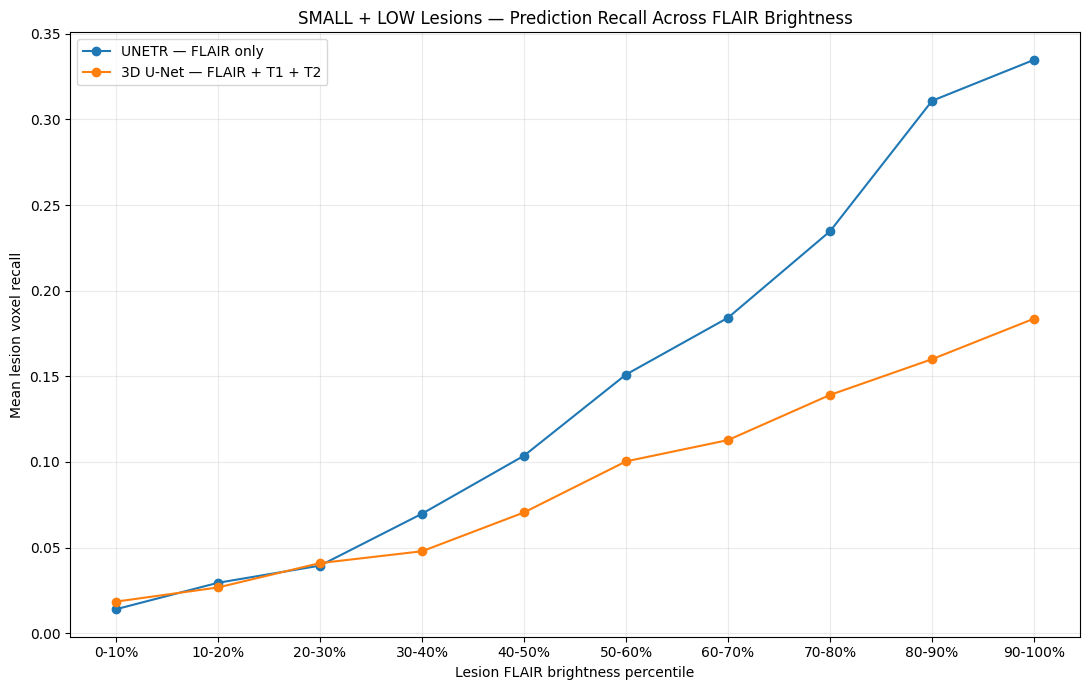

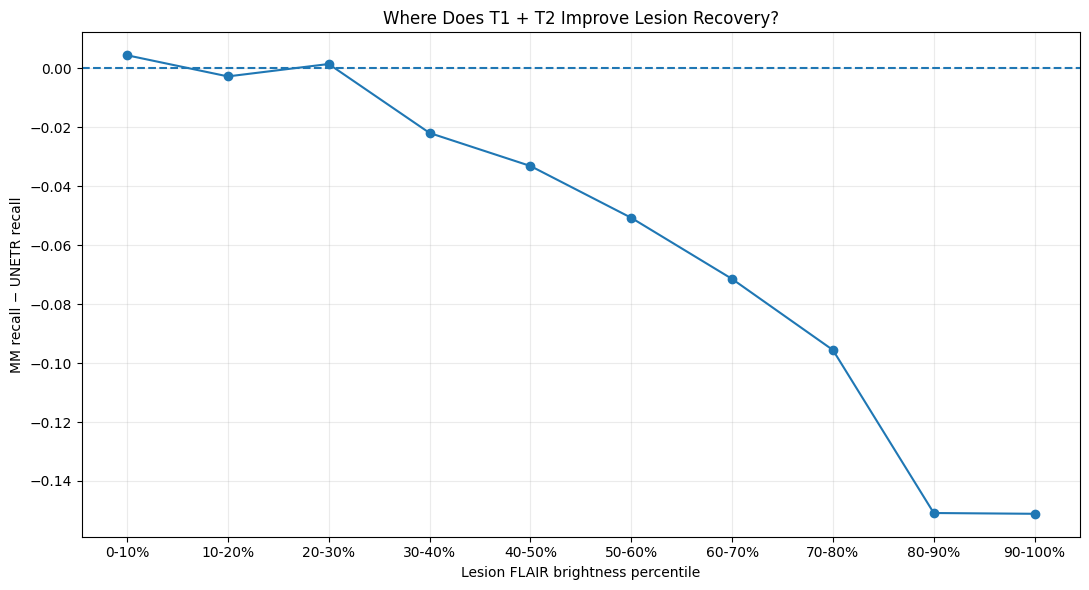


BRIGHTNESS BIAS
UNETR darkest decile recall: 0.0140
UNETR brightest decile recall: 0.3348
UNETR brightness bias: 0.3208

MM darkest decile recall: 0.0185
MM brightest decile recall: 0.1837
MM brightness bias: 0.1653

Bias reduction: 0.1556

BRIGHTNESS DECILE vs RECALL
UNETR:
Spearman rho = 1.0000, p = 6.6469e-64

Multimodal:
Spearman rho = 1.0000, p = 6.6469e-64

SAVED
Detailed: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\small_low_brightness_decile_analysis.csv
Summary: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\small_low_brightness_decile_summary.csv


In [23]:
# ============================================================
# EXPERIMENT 6 / EXPERIMENT 5
#
# SMALL + LOW LESIONS
# FULL BRIGHTNESS-DECILE ANALYSIS
#
# 312 lesions
#
# For each lesion:
#   Sort GT lesion voxels by FLAIR intensity
#
#   0-10%   = darkest
#   10-20%
#   ...
#   90-100% = brightest
#
# For each decile:
#   UNETR recall
#   Multimodal recall
#
# Main question:
#
#   Does the model preferentially predict the brightest
#   part of a lesion?
#
#   Does T1+T2 reduce that brightness bias?
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import matplotlib.pyplot as plt

from scipy import ndimage


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# 3. CHECK MODELS
# ============================================================

if "model_unetr" not in globals():

    raise NameError(
        "model_unetr is not available. "
        "Load the Experiment 6 UNETR first."
    )


if "model_mm" not in globals():

    raise NameError(
        "model_mm is not available. "
        "Load the Experiment 5 multimodal 3D U-Net first."
    )


model_unetr.eval()
model_mm.eval()


# ============================================================
# 4. PATH
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)

TEST_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed",
    "test"
)


# ============================================================
# 5. SMALL + LOW THRESHOLDS
#
# Same thresholds used in previous analysis.
# ============================================================

VOLUME_THRESHOLD = 63.0

FLAIR_THRESHOLD = 1.4307479858


# ============================================================
# 6. EXISTING LESION DATAFRAME
# ============================================================

if "lesion_df" not in globals():

    raise NameError(
        "lesion_df is not available. "
        "Run the previous lesion-level analysis first."
    )


required_columns = [
    "Patient",
    "Lesion_ID",
    "Lesion_Voxels",
    "FLAIR_Mean",
    "Status"
]


missing = [
    c
    for c in required_columns
    if c not in lesion_df.columns
]


if missing:

    raise RuntimeError(
        "Missing columns:\n"
        +
        "\n".join(missing)
    )


# ============================================================
# 7. SELECT 312 SMALL + LOW LESIONS
# ============================================================

small_low_df = lesion_df[
    (
        lesion_df["Lesion_Voxels"]
        <= VOLUME_THRESHOLD
    )
    &
    (
        lesion_df["FLAIR_Mean"]
        <= FLAIR_THRESHOLD
    )
].copy()


print("=" * 100)
print("FULL BRIGHTNESS-DECILE ANALYSIS")
print("=" * 100)

print(
    "Small + low lesions:",
    len(small_low_df)
)


# ============================================================
# 8. CHECK EXPECTED COUNTS
# ============================================================

status_counts = (
    small_low_df[
        "Status"
    ]
    .value_counts()
)


print("\nStatus counts:")

display(
    status_counts.to_frame(
        "Number_of_Lesions"
    )
)


# ============================================================
# 9. EXPECTED:
#
#   312 total
#   7 rescued
#   53 UNETR only
#   200 missed both
#   52 both
# ============================================================

if len(small_low_df) != 312:

    raise RuntimeError(
        f"Expected 312 SMALL + LOW lesions, "
        f"found {len(small_low_df)}."
    )


# ============================================================
# 10. CONNECTIVITY
# ============================================================

structure = (
    ndimage.generate_binary_structure(
        3,
        3
    )
)


# ============================================================
# 11. DECILE STORAGE
#
# Each row:
#   one lesion
#   one brightness decile
# ============================================================

decile_results = []


# ============================================================
# 12. PATIENTS
# ============================================================

patients = sorted(
    small_low_df[
        "Patient"
    ].unique(),

    key=lambda x:
        int(x[1:])
        if (
            x.startswith("P")
            and
            x[1:].isdigit()
        )
        else x
)


print(
    "\nPatients:",
    len(patients)
)


# ============================================================
# 13. PROCESS PATIENTS
# ============================================================

for patient_index, patient in enumerate(
    patients,
    start=1
):

    print(
        f"{patient_index:02d}/"
        f"{len(patients):02d} | "
        f"{patient}"
    )


    patient_root = os.path.join(
        TEST_ROOT,
        patient
    )


    # ========================================================
    # PATHS
    # ========================================================

    flair_path = os.path.join(
        patient_root,
        f"{patient}_FLAIR_N4_Z.nii.gz"
    )

    t1_path = os.path.join(
        patient_root,
        f"{patient}_T1_N4_Z.nii.gz"
    )

    t2_path = os.path.join(
        patient_root,
        f"{patient}_T2_N4_Z.nii.gz"
    )

    mask_path = os.path.join(
        patient_root,
        f"{patient}_MASK.nii.gz"
    )


    # ========================================================
    # LOAD
    # ========================================================

    flair = nib.load(
        flair_path
    ).get_fdata(
        dtype=np.float32
    )

    t1 = nib.load(
        t1_path
    ).get_fdata(
        dtype=np.float32
    )

    t2 = nib.load(
        t2_path
    ).get_fdata(
        dtype=np.float32
    )

    gt = (
        nib.load(
            mask_path
        ).get_fdata(
            dtype=np.float32
        )
        > 0
    )


    # ========================================================
    # MODEL INPUT — UNETR
    # ========================================================

    flair_tensor = torch.from_numpy(
        flair
    ).float()


    flair_gpu = (
        flair_tensor
        .unsqueeze(0)
        .unsqueeze(0)
        .to(
            device,
            non_blocking=True
        )
    )


    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            output_unetr = (
                __import__(
                    "monai.inferers",
                    fromlist=[
                        "sliding_window_inference"
                    ]
                )
                .sliding_window_inference(

                    inputs=flair_gpu,

                    roi_size=(
                        144,
                        144,
                        144
                    ),

                    sw_batch_size=1,

                    predictor=model_unetr,

                    overlap=0.5
                )
            )


    pred_unetr = (
        torch.sigmoid(
            output_unetr
        )
        > 0.5
    ).squeeze().cpu().numpy()


    del flair_gpu
    del output_unetr


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    # ========================================================
    # MODEL INPUT — MULTIMODAL
    # ========================================================

    mm_tensor = torch.from_numpy(
        np.stack(
            [
                flair,
                t1,
                t2
            ],
            axis=0
        )
    ).float()


    mm_gpu = (
        mm_tensor
        .unsqueeze(0)
        .to(
            device,
            non_blocking=True
        )
    )


    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            output_mm = (
                __import__(
                    "monai.inferers",
                    fromlist=[
                        "sliding_window_inference"
                    ]
                )
                .sliding_window_inference(

                    inputs=mm_gpu,

                    roi_size=(
                        144,
                        144,
                        144
                    ),

                    sw_batch_size=1,

                    predictor=model_mm,

                    overlap=0.5
                )
            )


    pred_mm = (
        torch.sigmoid(
            output_mm
        )
        > 0.5
    ).squeeze().cpu().numpy()


    del mm_gpu
    del output_mm


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    # ========================================================
    # 14. CONNECTED COMPONENTS
    # ========================================================

    labeled_gt, num_components = (
        ndimage.label(
            gt,
            structure=structure
        )
    )


    # ========================================================
    # 15. RELEVANT LESIONS ONLY
    # ========================================================

    patient_lesions = small_low_df[
        small_low_df["Patient"]
        ==
        patient
    ]


    # ========================================================
    # 16. PROCESS EACH LESION
    # ========================================================

    for _, row in (
        patient_lesions.iterrows()
    ):

        lesion_id = int(
            row["Lesion_ID"]
        )


        lesion = (
            labeled_gt
            ==
            lesion_id
        )


        lesion_coordinates = np.argwhere(
            lesion
        )


        lesion_voxels = len(
            lesion_coordinates
        )


        if lesion_voxels == 0:
            continue


        # ====================================================
        # FLAIR intensity of each GT lesion voxel
        # ====================================================

        lesion_flair = flair[
            lesion
        ]


        # ====================================================
        # Sort darkest -> brightest
        # ====================================================

        sorted_indices = np.argsort(
            lesion_flair
        )


        # ====================================================
        # 10 brightness bins
        # ====================================================

        for decile in range(10):

            start = int(
                decile
                *
                lesion_voxels
                /
                10
            )

            end = int(
                (decile + 1)
                *
                lesion_voxels
                /
                10
            )


            if end <= start:

                continue


            selected_indices = (
                sorted_indices[
                    start:end
                ]
            )


            coords = (
                lesion_coordinates[
                    selected_indices
                ]
            )


            # =================================================
            # FLAIR values in this decile
            # =================================================

            decile_flair = (
                lesion_flair[
                    selected_indices
                ]
            )


            # =================================================
            # UNETR predictions
            # =================================================

            unetr_values = (
                pred_unetr[
                    coords[:, 0],
                    coords[:, 1],
                    coords[:, 2]
                ]
            )


            # =================================================
            # MULTIMODAL predictions
            # =================================================

            mm_values = (
                pred_mm[
                    coords[:, 0],
                    coords[:, 1],
                    coords[:, 2]
                ]
            )


            # =================================================
            # Recall within this brightness decile
            #
            # Since every selected voxel belongs to GT:
            #
            # recall = predicted-positive fraction
            # =================================================

            unetr_recall = float(
                np.mean(
                    unetr_values
                )
            )


            mm_recall = float(
                np.mean(
                    mm_values
                )
            )


            # =================================================
            # Store
            # =================================================

            decile_results.append({

                "Patient":
                    patient,

                "Lesion_ID":
                    lesion_id,

                "Lesion_Volume":
                    lesion_voxels,

                "Status":
                    row["Status"],

                "Decile":
                    decile + 1,

                "Brightness_Range":
                    (
                        f"{decile * 10}"
                        f"-"
                        f"{(decile + 1) * 10}%"
                    ),

                "Mean_FLAIR":
                    float(
                        np.mean(
                            decile_flair
                        )
                    ),

                "Median_FLAIR":
                    float(
                        np.median(
                            decile_flair
                        )
                    ),

                "UNETR_Recall":
                    unetr_recall,

                "MM_Recall":
                    mm_recall,

                "Recall_Improvement":
                    (
                        mm_recall
                        -
                        unetr_recall
                    )
            })


    # ========================================================
    # CLEAN PATIENT MEMORY
    # ========================================================

    del flair
    del t1
    del t2
    del gt

    del flair_tensor
    del mm_tensor

    del pred_unetr
    del pred_mm

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    gc.collect()


# ============================================================
# 17. DATAFRAME
# ============================================================

decile_df = pd.DataFrame(
    decile_results
)


print("\n" + "=" * 110)
print("DECILE DATASET")
print("=" * 110)

print(
    "Rows:",
    len(decile_df)
)

print(
    "Expected approximately:",
    len(small_low_df) * 10
)


# ============================================================
# 18. AGGREGATE BY BRIGHTNESS DECILE
#
# LESION-WEIGHTED:
# Each lesion contributes equally.
# ============================================================

decile_summary = (

    decile_df

    .groupby(
        "Decile"
    )

    .agg(

        Lesions=(
            "Lesion_ID",
            "count"
        ),

        Mean_FLAIR=(
            "Mean_FLAIR",
            "mean"
        ),

        UNETR_Recall=(
            "UNETR_Recall",
            "mean"
        ),

        MM_Recall=(
            "MM_Recall",
            "mean"
        ),

        Recall_Improvement=(
            "Recall_Improvement",
            "mean"
        )
    )

    .reset_index()
)


decile_summary[
    "Brightness_Percent"
] = (
    decile_summary[
        "Decile"
    ]
    .apply(
        lambda x:
            f"{(x - 1) * 10}"
            f"-"
            f"{x * 10}%"
    )
)


# ============================================================
# 19. DISPLAY
# ============================================================

print("\n" + "=" * 110)
print(
    "SMALL + LOW — FULL BRIGHTNESS DECILE SUMMARY"
)
print("=" * 110)

display(
    decile_summary[
        [
            "Decile",
            "Brightness_Percent",
            "Mean_FLAIR",
            "UNETR_Recall",
            "MM_Recall",
            "Recall_Improvement"
        ]
    ]
)


# ============================================================
# 20. PLOT — UNETR vs MULTIMODAL
# ============================================================

x = np.arange(
    1,
    len(decile_summary) + 1
)


fig, ax = plt.subplots(
    figsize=(11, 7)
)


ax.plot(
    x,
    decile_summary[
        "UNETR_Recall"
    ],
    marker="o",
    label="UNETR — FLAIR only"
)


ax.plot(
    x,
    decile_summary[
        "MM_Recall"
    ],
    marker="o",
    label="3D U-Net — FLAIR + T1 + T2"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    decile_summary[
        "Brightness_Percent"
    ]
)


ax.set_xlabel(
    "Lesion FLAIR brightness percentile"
)

ax.set_ylabel(
    "Mean lesion voxel recall"
)

ax.set_title(
    "SMALL + LOW Lesions — "
    "Prediction Recall Across FLAIR Brightness"
)


ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. PLOT — MULTIMODAL IMPROVEMENT
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6)
)


ax.plot(
    x,
    decile_summary[
        "Recall_Improvement"
    ],
    marker="o"
)


ax.axhline(
    0,
    linestyle="--"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    decile_summary[
        "Brightness_Percent"
    ]
)


ax.set_xlabel(
    "Lesion FLAIR brightness percentile"
)

ax.set_ylabel(
    "MM recall − UNETR recall"
)

ax.set_title(
    "Where Does T1 + T2 Improve Lesion Recovery?"
)


ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. BRIGHTNESS BIAS
# ============================================================

if len(decile_summary) >= 10:

    unetr_bias = (
        decile_summary.iloc[-1][
            "UNETR_Recall"
        ]
        -
        decile_summary.iloc[0][
            "UNETR_Recall"
        ]
    )


    mm_bias = (
        decile_summary.iloc[-1][
            "MM_Recall"
        ]
        -
        decile_summary.iloc[0][
            "MM_Recall"
        ]
    )


    print("\n" + "=" * 110)
    print("BRIGHTNESS BIAS")
    print("=" * 110)

    print(
        "UNETR darkest decile recall:",
        f"{decile_summary.iloc[0]['UNETR_Recall']:.4f}"
    )

    print(
        "UNETR brightest decile recall:",
        f"{decile_summary.iloc[-1]['UNETR_Recall']:.4f}"
    )

    print(
        "UNETR brightness bias:",
        f"{unetr_bias:.4f}"
    )


    print()

    print(
        "MM darkest decile recall:",
        f"{decile_summary.iloc[0]['MM_Recall']:.4f}"
    )

    print(
        "MM brightest decile recall:",
        f"{decile_summary.iloc[-1]['MM_Recall']:.4f}"
    )

    print(
        "MM brightness bias:",
        f"{mm_bias:.4f}"
    )


    print(
        "\nBias reduction:",
        f"{unetr_bias - mm_bias:.4f}"
    )


# ============================================================
# 23. CORRELATION:
# DECILE vs RECALL
# ============================================================

from scipy.stats import spearmanr


rho_unetr, p_unetr = spearmanr(
    decile_summary[
        "Decile"
    ],
    decile_summary[
        "UNETR_Recall"
    ]
)


rho_mm, p_mm = spearmanr(
    decile_summary[
        "Decile"
    ],
    decile_summary[
        "MM_Recall"
    ]
)


print("\n" + "=" * 110)
print("BRIGHTNESS DECILE vs RECALL")
print("=" * 110)

print(
    "UNETR:"
)

print(
    f"Spearman rho = {rho_unetr:.4f}, "
    f"p = {p_unetr:.6g}"
)


print(
    "\nMultimodal:"
)

print(
    f"Spearman rho = {rho_mm:.4f}, "
    f"p = {p_mm:.6g}"
)


# ============================================================
# 24. SAVE
# ============================================================

DECILE_CSV = os.path.join(
    DATASET_ROOT,
    "small_low_brightness_decile_analysis.csv"
)

SUMMARY_CSV = os.path.join(
    DATASET_ROOT,
    "small_low_brightness_decile_summary.csv"
)


decile_df.to_csv(
    DECILE_CSV,
    index=False
)


decile_summary.to_csv(
    SUMMARY_CSV,
    index=False
)


print("\n" + "=" * 110)
print("SAVED")
print("=" * 110)

print(
    "Detailed:",
    DECILE_CSV
)

print(
    "Summary:",
    SUMMARY_CSV
)

print("=" * 110)

## analysis ends here 

# UNETR ends here

# Swim Unetr starts here

In [39]:
# ============================================================
# EXPERIMENT 6 — SWIN UNETR
# FLAIR ONLY
# MODEL-SPECIFIC CONFIGURATION
# ============================================================

import torch

from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss


# ============================================================
# SWIN UNETR SPECIFIC VARIABLES
# ============================================================

ROI_SIZE_SWINUNETR = (
    160,
    160,
    160
)

IN_CHANNELS_SWINUNETR = 1
OUT_CHANNELS_SWINUNETR = 1

FEATURE_SIZE_SWINUNETR = 24

USE_CHECKPOINT_SWINUNETR = False


# ============================================================
# FRESH SWIN UNETR
# ============================================================

model_swinunetr = SwinUNETR(
    img_size=ROI_SIZE_SWINUNETR,

    in_channels=IN_CHANNELS_SWINUNETR,

    out_channels=OUT_CHANNELS_SWINUNETR,

    feature_size=FEATURE_SIZE_SWINUNETR,

    use_checkpoint=USE_CHECKPOINT_SWINUNETR
).to(device)


# ============================================================
# LOSS
# ============================================================

loss_function_swinunetr = DiceCELoss(
    sigmoid=True,
    squared_pred=True
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer_swinunetr = torch.optim.Adam(
    model_swinunetr.parameters(),
    lr=1e-4
)


# ============================================================
# AMP
# ============================================================

scaler_swinunetr = torch.amp.GradScaler(
    "cuda"
)


# ============================================================
# PARAMETER COUNT
# ============================================================

params_swinunetr = sum(
    p.numel()
    for p in model_swinunetr.parameters()
)


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — SWIN UNETR")
print("=" * 70)

print("Input           : FLAIR only")
print("Input channels  :", IN_CHANNELS_SWINUNETR)
print("Output channels :", OUT_CHANNELS_SWINUNETR)

print(
    "Swin ROI        :",
    ROI_SIZE_SWINUNETR
)

print(
    "Feature size    :",
    FEATURE_SIZE_SWINUNETR
)

print(
    "Checkpointing   :",
    USE_CHECKPOINT_SWINUNETR
)

print(
    "Parameters      :",
    f"{params_swinunetr:,}"
)

print("Loss            : DiceCELoss")
print("Learning rate   : 0.0001")
print("N4              : YES")
print("Z-score         : YES")
print("AMP             : YES")

print("\n✓ Fresh Swin UNETR created.")

EXPERIMENT 6 — SWIN UNETR
Input           : FLAIR only
Input channels  : 1
Output channels : 1
Swin ROI        : (160, 160, 160)
Feature size    : 24
Checkpointing   : False
Parameters      : 15,702,979
Loss            : DiceCELoss
Learning rate   : 0.0001
N4              : YES
Z-score         : YES
AMP             : YES

✓ Fresh Swin UNETR created.


In [44]:
# ============================================================
# EXPERIMENT 6 — SWIN UNETR TRAINING TRANSFORM
# USE EXISTING EXPERIMENT 6 FILE LIST
# ============================================================

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    RandFlipd,
    RandRotated,
    RandAffined,
    RandGaussianNoised,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandCropByPosNegLabeld,
    ToTensord
)

ROI_SIZE_swinunetr = (
    160,
    160,
    160
)

train_transforms_swinunetr = Compose([

    LoadImaged(
        keys=["image", "label"]
    ),

    EnsureChannelFirstd(
        keys=["image", "label"]
    ),

    RandFlipd(
        keys=["image", "label"],
        spatial_axis=0,
        prob=0.5
    ),

    RandFlipd(
        keys=["image", "label"],
        spatial_axis=1,
        prob=0.5
    ),

    RandFlipd(
        keys=["image", "label"],
        spatial_axis=2,
        prob=0.5
    ),

    RandRotated(
        keys=["image", "label"],
        range_x=0.15,
        range_y=0.15,
        range_z=0.15,
        prob=0.3,
        mode=("bilinear", "nearest"),
        padding_mode="border"
    ),

    RandAffined(
        keys=["image", "label"],
        prob=0.3,
        rotate_range=(0.10, 0.10, 0.10),
        scale_range=(0.10, 0.10, 0.10),
        mode=("bilinear", "nearest"),
        padding_mode="border"
    ),

    RandScaleIntensityd(
        keys=["image"],
        factors=0.1,
        prob=0.2
    ),

    RandShiftIntensityd(
        keys=["image"],
        offsets=0.1,
        prob=0.2
    ),

    RandGaussianNoised(
        keys=["image"],
        prob=0.2,
        mean=0.0,
        std=0.01
    ),

    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=ROI_SIZE_swinunetr,
        pos=4,
        neg=1,
        num_samples=1
    ),

    ToTensord(
        keys=["image", "label"]
    )
])


print("=" * 70)
print("SWIN UNETR TRAINING TRANSFORM")
print("=" * 70)

print("Input          : FLAIR only")
print("Base files     : train_files_exp6")
print("ROI            :", ROI_SIZE_swinunetr)
print("N4             : Already applied")
print("Z-score        : Already applied")
print("Random aug.    : YES")

print("\n✓ Swin-specific training transform created.")

SWIN UNETR TRAINING TRANSFORM
Input          : FLAIR only
Base files     : train_files_exp6
ROI            : (160, 160, 160)
N4             : Already applied
Z-score        : Already applied
Random aug.    : YES

✓ Swin-specific training transform created.


In [45]:
# ============================================================
# EXPERIMENT 6 — SWIN UNETR TRAIN LOADER
# USE EXISTING train_files_exp6
# ============================================================

from monai.data import Dataset, DataLoader

train_ds_swinunetr = Dataset(
    data=train_files_exp6,
    transform=train_transforms_swinunetr
)

train_loader_swinunetr = DataLoader(
    train_ds_swinunetr,
    batch_size=1,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("=" * 70)
print("SWIN UNETR TRAIN LOADER")
print("=" * 70)

print(
    "Training samples:",
    len(train_ds_swinunetr)
)

print(
    "Training batches:",
    len(train_loader_swinunetr)
)

print(
    "ROI:",
    ROI_SIZE_swinunetr
)

print("\n✓ Swin UNETR training loader ready.")

SWIN UNETR TRAIN LOADER
Training samples: 70
Training batches: 70
ROI: (160, 160, 160)

✓ Swin UNETR training loader ready.


In [46]:
# ============================================================
# EXPERIMENT 6 — SWIN UNETR
# FORWARD / MEMORY SANITY CHECK
# ============================================================

import torch

print("=" * 70)
print("EXPERIMENT 6 — SWIN UNETR FORWARD / MEMORY SANITY CHECK")
print("=" * 70)


# ------------------------------------------------------------
# GET ONE SWIN TRAINING BATCH
# ------------------------------------------------------------

swin_batch = next(
    iter(train_loader_swinunetr)
)

swin_image = swin_batch["image"].to(
    device,
    non_blocking=True
)

swin_label = swin_batch["label"].to(
    device,
    non_blocking=True
)


# ------------------------------------------------------------
# INPUT CHECK
# ------------------------------------------------------------

print("Image shape :", swin_image.shape)
print("Label shape :", swin_label.shape)
print("Image dtype :", swin_image.dtype)
print("Label dtype :", swin_label.dtype)

print(
    "Image min   :",
    swin_image.min().item()
)

print(
    "Image max   :",
    swin_image.max().item()
)

print(
    "Image mean  :",
    swin_image.mean().item()
)

print(
    "Label values:",
    torch.unique(swin_label)
)


# ------------------------------------------------------------
# GPU MEMORY BEFORE
# ------------------------------------------------------------

torch.cuda.empty_cache()
torch.cuda.synchronize()

memory_before_swin = (
    torch.cuda.memory_allocated(device)
    / (1024 ** 3)
)

print(
    f"\nGPU memory before : "
    f"{memory_before_swin:.2f} GB"
)


# ------------------------------------------------------------
# FORWARD PASS
# ------------------------------------------------------------

try:

    model_swinunetr.eval()

    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            output_swin = model_swinunetr(
                swin_image
            )


    torch.cuda.synchronize()


    # --------------------------------------------------------
    # OUTPUT
    # --------------------------------------------------------

    print(
        "\nOutput shape :",
        output_swin.shape
    )

    print(
        "Output dtype :",
        output_swin.dtype
    )


    # --------------------------------------------------------
    # GPU MEMORY AFTER
    # --------------------------------------------------------

    memory_after_swin = (
        torch.cuda.memory_allocated(device)
        / (1024 ** 3)
    )

    memory_reserved_swin = (
        torch.cuda.memory_reserved(device)
        / (1024 ** 3)
    )

    print(
        f"GPU memory after    : "
        f"{memory_after_swin:.2f} GB"
    )

    print(
        f"GPU memory reserved : "
        f"{memory_reserved_swin:.2f} GB"
    )


    print(
        "\n✓ Swin UNETR forward pass successful."
    )


except RuntimeError as e:

    print(
        "\n❌ Swin UNETR forward pass failed."
    )

    print("\nError:")
    print(e)

    raise

EXPERIMENT 6 — SWIN UNETR FORWARD / MEMORY SANITY CHECK
Image shape : torch.Size([1, 1, 160, 160, 160])
Label shape : torch.Size([1, 1, 160, 160, 160])
Image dtype : torch.float32
Label dtype : torch.float32
Image min   : -3.4458796977996826
Image max   : 3.715524196624756
Image mean  : 0.0007309865322895348
Label values: metatensor([0., 1.], device='cuda:0')

GPU memory before : 0.71 GB

Output shape : torch.Size([1, 1, 160, 160, 160])
Output dtype : torch.float16
GPU memory after    : 0.71 GB
GPU memory reserved : 9.14 GB

✓ Swin UNETR forward pass successful.


In [47]:
# ============================================================
# EXPERIMENT 6 — SWIN UNETR TRAINING DATALOADER
# USE EXISTING EXPERIMENT 6 BASE VARIABLES
# ============================================================

from monai.data import Dataset, DataLoader


# ============================================================
# SWIN-SPECIFIC TRAINING DATASET
# ============================================================

train_ds_swinunetr = Dataset(
    data=train_files_exp6,
    transform=train_transforms_swinunetr
)


# ============================================================
# SWIN-SPECIFIC TRAINING DATALOADER
# ============================================================

train_loader_swinunetr = DataLoader(
    train_ds_swinunetr,
    batch_size=1,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


# ============================================================
# CHECK
# ============================================================

print("=" * 70)
print("EXPERIMENT 6 — SWIN UNETR TRAINING DATALOADER")
print("=" * 70)

print(
    "Training samples:",
    len(train_ds_swinunetr)
)

print(
    "Training batches:",
    len(train_loader_swinunetr)
)

print(
    "Training ROI    :",
    ROI_SIZE_swinunetr
)

print(
    "Validation loader:",
    "val_loader_exp6"
)

print(
    "Test loader      :",
    "test_loader_exp6"
)

print("\n✓ Swin UNETR training DataLoader ready.")

EXPERIMENT 6 — SWIN UNETR TRAINING DATALOADER
Training samples: 70
Training batches: 70
Training ROI    : (160, 160, 160)
Validation loader: val_loader_exp6
Test loader      : test_loader_exp6

✓ Swin UNETR training DataLoader ready.


In [48]:
# ============================================================
# EXPERIMENT 6 — SWIN UNETR
# FORWARD / MEMORY SANITY CHECK
# ============================================================

import torch

print("=" * 70)
print("EXPERIMENT 6 — SWIN UNETR FORWARD / MEMORY SANITY CHECK")
print("=" * 70)


# ============================================================
# GET ONE TRAINING BATCH
# ============================================================

swin_batch = next(
    iter(train_loader_swinunetr)
)

swin_image = swin_batch["image"].to(
    device,
    non_blocking=True
)

swin_label = swin_batch["label"].to(
    device,
    non_blocking=True
)


# ============================================================
# INPUT CHECK
# ============================================================

print(
    "Image shape :",
    swin_image.shape
)

print(
    "Label shape :",
    swin_label.shape
)

print(
    "Image dtype :",
    swin_image.dtype
)

print(
    "Label dtype :",
    swin_label.dtype
)

print(
    "Image min   :",
    swin_image.min().item()
)

print(
    "Image max   :",
    swin_image.max().item()
)

print(
    "Image mean  :",
    swin_image.mean().item()
)

print(
    "Label values:",
    torch.unique(swin_label)
)


# ============================================================
# GPU MEMORY BEFORE
# ============================================================

torch.cuda.empty_cache()
torch.cuda.synchronize()

memory_before_swin = (
    torch.cuda.memory_allocated(device)
    / (1024 ** 3)
)

print(
    f"\nGPU memory before : "
    f"{memory_before_swin:.2f} GB"
)


# ============================================================
# FORWARD PASS
# ============================================================

try:

    model_swinunetr.eval()

    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            output_swin = model_swinunetr(
                swin_image
            )


    torch.cuda.synchronize()


    # ========================================================
    # OUTPUT CHECK
    # ========================================================

    print(
        "\nOutput shape :",
        output_swin.shape
    )

    print(
        "Output dtype :",
        output_swin.dtype
    )


    # ========================================================
    # GPU MEMORY AFTER
    # ========================================================

    memory_after_swin = (
        torch.cuda.memory_allocated(device)
        / (1024 ** 3)
    )

    memory_reserved_swin = (
        torch.cuda.memory_reserved(device)
        / (1024 ** 3)
    )

    print(
        f"GPU memory after    : "
        f"{memory_after_swin:.2f} GB"
    )

    print(
        f"GPU memory reserved : "
        f"{memory_reserved_swin:.2f} GB"
    )


    print(
        "\n✓ Swin UNETR forward pass successful."
    )


except RuntimeError as e:

    print(
        "\n❌ Swin UNETR forward pass failed."
    )

    print("\nError:")
    print(e)

    raise

EXPERIMENT 6 — SWIN UNETR FORWARD / MEMORY SANITY CHECK
Image shape : torch.Size([1, 1, 160, 160, 160])
Label shape : torch.Size([1, 1, 160, 160, 160])
Image dtype : torch.float32
Label dtype : torch.float32
Image min   : -3.9023444652557373
Image max   : 4.66002082824707
Image mean  : -0.00020002652308903635
Label values: metatensor([0., 1.], device='cuda:0')

GPU memory before : 0.71 GB

Output shape : torch.Size([1, 1, 160, 160, 160])
Output dtype : torch.float16
GPU memory after    : 0.71 GB
GPU memory reserved : 9.16 GB

✓ Swin UNETR forward pass successful.


In [ ]:
# ============================================================
# EXPERIMENT 6 — SWIN UNETR TRAINING
# FLAIR ONLY
# ============================================================

import os
import time
import torch

from tqdm import tqdm
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric


# ============================================================
# SAVE PATHS
# ============================================================

EXP6_SWINUNETR_DIR = os.path.join(
    DATASET_ROOT,
    "Experiment_6_SwinUNETR_FLAIR"
)

os.makedirs(
    EXP6_SWINUNETR_DIR,
    exist_ok=True
)

BEST_MODEL_SWINUNETR = os.path.join(
    EXP6_SWINUNETR_DIR,
    "best_model_swinunetr_flair.pth"
)

CHECKPOINT_SWINUNETR = os.path.join(
    EXP6_SWINUNETR_DIR,
    "checkpoint_swinunetr_flair.pth"
)


# ============================================================
# DICE METRIC
# ============================================================

dice_metric_swinunetr = DiceMetric(
    include_background=False,
    reduction="mean"
)

best_val_dice_swinunetr = 0.0


# ============================================================
# TRAINING SUMMARY
# ============================================================

print("=" * 70)
print("STARTING EXPERIMENT 6 — SWIN UNETR TRAINING")
print("=" * 70)

print("Model          : Swin UNETR")
print("Input          : FLAIR only")
print("Training       :", len(train_ds_swinunetr))
print("Validation     :", len(val_ds_exp6))
print("Epochs         :", 100)
print("Batch size     :", 1)
print("Training ROI   :", ROI_SIZE_SWINUNETR)
print("Learning rate  :", 1e-4)
print("Loss           :", "DiceCELoss")
print("N4             : YES")
print("Z-score        : YES")
print("AMP            : YES")
print("Checkpointing  :", USE_CHECKPOINT_SWINUNETR)

print("=" * 70)


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(100):

    epoch_start = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    model_swinunetr.train()

    epoch_loss_swinunetr = 0.0

    progress_bar = tqdm(
        train_loader_swinunetr,
        desc=f"Swin UNETR Epoch {epoch + 1}/100"
    )

    for batch in progress_bar:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        labels = batch["label"].to(
            device,
            non_blocking=True
        )

        optimizer_swinunetr.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model_swinunetr(
                images
            )

            loss = loss_function_swinunetr(
                outputs,
                labels
            )

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        scaler_swinunetr.scale(
            loss
        ).backward()

        scaler_swinunetr.step(
            optimizer_swinunetr
        )

        scaler_swinunetr.update()

        epoch_loss_swinunetr += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss_swinunetr /= len(
        train_loader_swinunetr
    )


    # ========================================================
    # VALIDATION
    # USE EXISTING EXPERIMENT 6 VALIDATION LOADER
    # ========================================================

    model_swinunetr.eval()

    dice_metric_swinunetr.reset()

    with torch.no_grad():

        for batch in val_loader_exp6:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            labels = batch["label"].to(
                device,
                non_blocking=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = sliding_window_inference(
                    inputs=images,
                    roi_size=ROI_SIZE_SWINUNETR,
                    sw_batch_size=1,
                    predictor=model_swinunetr,
                    overlap=0.5
                )

            predictions = (
                torch.sigmoid(outputs) > 0.5
            )

            dice_metric_swinunetr(
                y_pred=predictions,
                y=labels
            )

    val_dice_swinunetr = (
        dice_metric_swinunetr
        .aggregate()
        .item()
    )

    dice_metric_swinunetr.reset()


    # ========================================================
    # TIME
    # ========================================================

    epoch_time_swinunetr = (
        time.time()
        - epoch_start
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"\nEpoch {epoch + 1}/100"
        f" | Loss: {epoch_loss_swinunetr:.4f}"
        f" | Val Dice: {val_dice_swinunetr:.4f}"
        f" | Time: {epoch_time_swinunetr:.1f}s"
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_dice_swinunetr > best_val_dice_swinunetr:

        best_val_dice_swinunetr = (
            val_dice_swinunetr
        )

        torch.save(
            model_swinunetr.state_dict(),
            BEST_MODEL_SWINUNETR
        )

        print(
            "✓ BEST MODEL SAVED"
            f" | Dice = "
            f"{best_val_dice_swinunetr:.4f}"
        )


    # ========================================================
    # SAVE CHECKPOINT
    # ========================================================

    torch.save(
        {
            "epoch":
                epoch + 1,

            "model_state_dict":
                model_swinunetr.state_dict(),

            "optimizer_state_dict":
                optimizer_swinunetr.state_dict(),

            "scaler_state_dict":
                scaler_swinunetr.state_dict(),

            "best_val_dice":
                best_val_dice_swinunetr
        },
        CHECKPOINT_SWINUNETR
    )

    print(
        f"💾 Checkpoint saved | Epoch {epoch + 1}"
    )


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("SWIN UNETR TRAINING COMPLETE")
print("=" * 70)

print(
    "Best Validation Dice:",
    f"{best_val_dice_swinunetr:.4f}"
)

print(
    "Best Model:",
    BEST_MODEL_SWINUNETR
)

print(
    "Checkpoint:",
    CHECKPOINT_SWINUNETR
)

print("=" * 70)

# Swim unetr ends here